<a href="https://colab.research.google.com/github/EnasF/Applying-XAI-for-Demand-Forecasting-and-Pricing-Decision-in-Supply-Chain/blob/main/Capstone_Project__Data_Processing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Applying Explainable Artificial Intelligence for Demand Forecasting and Pricing Decision in Supply Chain**

This Source Code for the implementation of the capstone project data preprocessing , EDA and Feature Engneering this include the following:

*   Data Import and Exploration
*   Data Merging and Visulization
*   Statistical Hypothesis Testing   
*   Sampling
*   Feature Engneering

Full code will be devided on 4 files as following:
1. Capstone Project_Data_Processing
2. CapstoneProject_CatBoost_SHAP_PDP_LIME_Price_Optimization
3. Capstone Project _LSTM_Model
4. Capstone Project _TCN_Model









In [ ]:
!pip install scikit-posthocs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene, kruskal
import scikit_posthocs as sp
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import math
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
plt.style.use("ggplot")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#import data files
calendar = pd.read_csv("/content/drive/MyDrive/Graduation Project Data/calendar.csv")
sales_train_evaluation= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/sales_train_evaluation.csv")
prices = pd.read_csv("/content/drive/MyDrive/Graduation Project Data/sell_prices.csv")

# **Exploring Calender Data**

In [ ]:
print(calendar.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1969 entries, 0 to 1968
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1969 non-null   object
 1   wm_yr_wk      1969 non-null   int64 
 2   weekday       1969 non-null   object
 3   wday          1969 non-null   int64 
 4   month         1969 non-null   int64 
 5   year          1969 non-null   int64 
 6   d             1969 non-null   object
 7   event_name_1  162 non-null    object
 8   event_type_1  162 non-null    object
 9   event_name_2  5 non-null      object
 10  event_type_2  5 non-null      object
 11  snap_CA       1969 non-null   int64 
 12  snap_TX       1969 non-null   int64 
 13  snap_WI       1969 non-null   int64 
dtypes: int64(7), object(7)
memory usage: 215.5+ KB
None


In [ ]:
calendar.shape

(1969, 14)

In [ ]:

calendar.head()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [ ]:
#Print unique values and the count of it
print('Unique values and their counts for event_name_1:')
display(calendar['event_name_1'].value_counts(dropna=False))

Unique values and their counts for event_name_1:


,count
event_name_1,
NaN,1807
SuperBowl,6
ValentinesDay,6
PresidentsDay,6
LentStart,6
LentWeek2,6
StPatricksDay,6
Purim End,6
Pesach End,6


In [ ]:
print('\nUnique values and their counts for event_type_1:')
display(calendar['event_type_1'].value_counts(dropna=False))


Unique values and their counts for event_type_1:


,count
event_type_1,
NaN,1807
Religious,55
National,52
Cultural,37
Sporting,18


In [ ]:
print('\nUnique values and their counts for event_name_2:')
display(calendar['event_name_2'].value_counts(dropna=False))


Unique values and their counts for event_name_2:


,count
event_name_2,
NaN,1964
Father's day,2
Easter,1
Cinco De Mayo,1
OrthodoxEaster,1


In [ ]:
print('\nUnique values and their counts for event_type_2:')
display(calendar['event_type_2'].value_counts(dropna=False))


Unique values and their counts for event_type_2:


,count
event_type_2,
NaN,1964
Cultural,4
Religious,1


In [ ]:
calendar.isnull().sum()

,0
date,0
wm_yr_wk,0
weekday,0
wday,0
month,0
year,0
d,0
event_name_1,1807
event_type_1,1807
event_name_2,1964


In [ ]:
#get data period
start_date = calendar['date'].min()
end_date = calendar['date'].max()
print(f"Start Date: {start_date}")
print(f"End Date: {end_date}")

Start Date: 2011-01-29
End Date: 2016-06-19


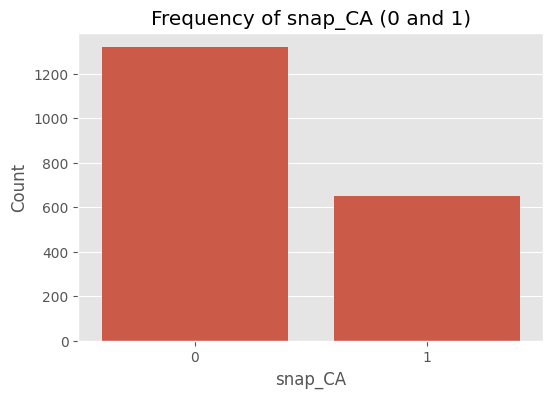

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='snap_CA', data=calendar)
plt.title('Frequency of snap_CA (0 and 1)')
plt.xlabel('snap_CA')
plt.ylabel('Count')
plt.show()

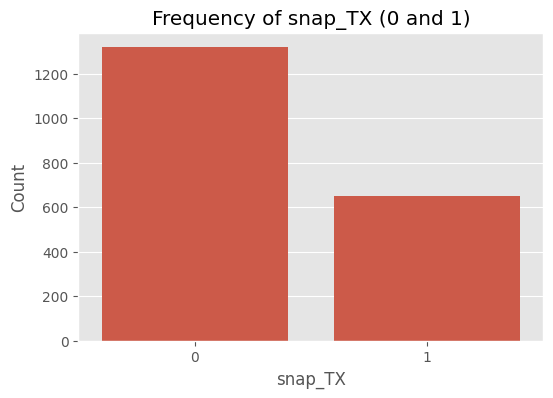

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='snap_TX', data=calendar)
plt.title('Frequency of snap_TX (0 and 1)')
plt.xlabel('snap_TX')
plt.ylabel('Count')
plt.show()

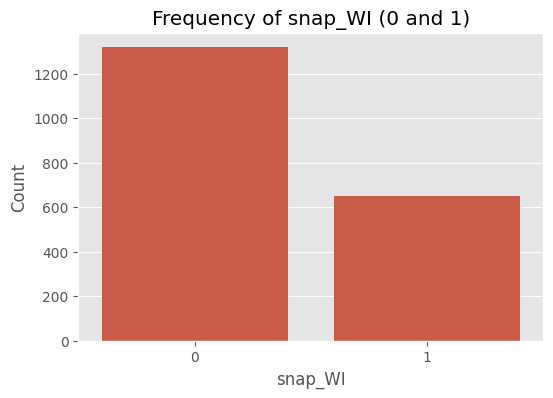

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='snap_WI', data=calendar)
plt.title('Frequency of snap_WI (0 and 1)')
plt.xlabel('snap_WI')
plt.ylabel('Count')
plt.show()

From the exploration of *Calender* we can know the following about the data:

- only event name coulmns and and event types have null value
- Reduction i s neede to reve redundanat coulmns for events
-merge will be done using day and week columns to integrate
 other data tables with calendar
 - Time period is from (2011-01-29) To (2016-06-19)
 -Snap_tx, Snap_CA, Snap_WI :Columns related to Supplemental Nutrition Assistance Program in US you can now more from this [Link](https://www.fns.usda.gov/snap/supplemental-nutrition-assistance-program#:~:text=Breadcrumb,Popular%20Topics)


#**Exploring Sales Data**

In [ ]:
sales_train_evaluation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30490 entries, 0 to 30489
Columns: 1947 entries, id to d_1941
dtypes: int64(1941), object(6)
memory usage: 452.9+ MB


In [ ]:
sales_train_evaluation.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [ ]:
#cheack missing values
sales_train_evaluation.isnull().sum()


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
...,...
d_1937,0
d_1938,0
d_1939,0
d_1940,0


In [ ]:
sales_train_evaluation.shape

(30490, 1947)

In [ ]:
# check dates Mapping
date_d1941 = calendar[calendar['d'] == 'd_1941']['date'].iloc[0]
print(f"The date for d_1941 is: {date_d1941}")

The date for d_1941 is: 2016-05-22


In [ ]:
#show unique categories
print('Unique values in cat_id column:')
display(sales_train_evaluation['cat_id'].unique())

Unique values in cat_id column:


array(['HOBBIES', 'HOUSEHOLD', 'FOODS'], dtype=object)

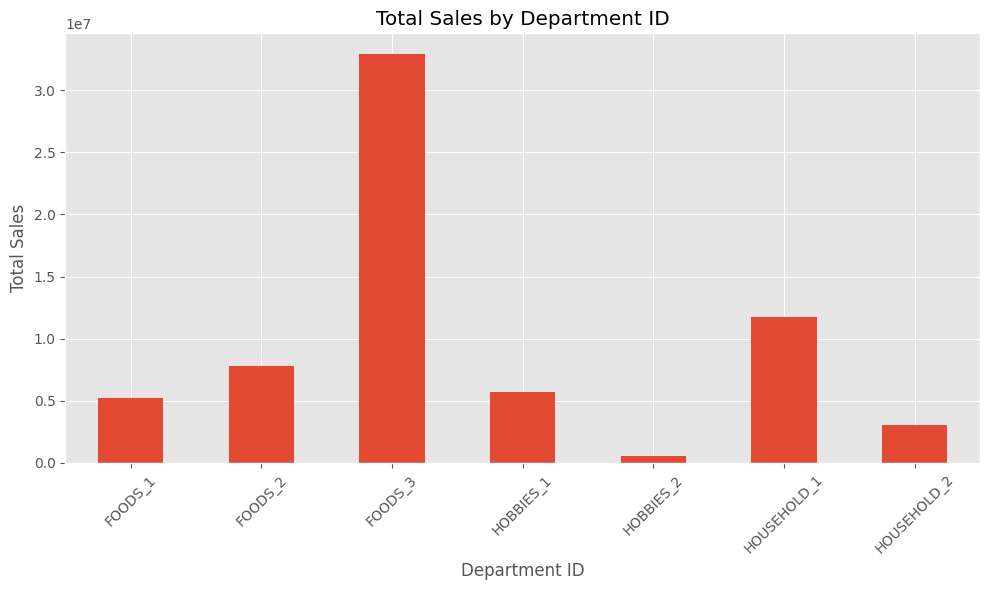

In [ ]:
d_cols = [c for c in sales_train_evaluation.columns if 'd_' in c]
dept_sales = sales_train_evaluation.groupby('dept_id')[d_cols].sum().sum(axis=1)

plt.figure(figsize=(10, 6))
dept_sales.plot(kind='bar')
plt.title('Total Sales by Department ID')
plt.xlabel('Department ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
#Exploring unique values of `item_id` to show number of products
print(f"Number of unique items: {sales_train_evaluation['item_id'].nunique()}")
print('\nUnique values in item_id column:')
display(sales_train_evaluation['item_id'].unique())

Number of unique items: 3049

Unique values in item_id column:


array(['HOBBIES_1_001', 'HOBBIES_1_002', 'HOBBIES_1_003', ...,
       'FOODS_3_825', 'FOODS_3_826', 'FOODS_3_827'], dtype=object)

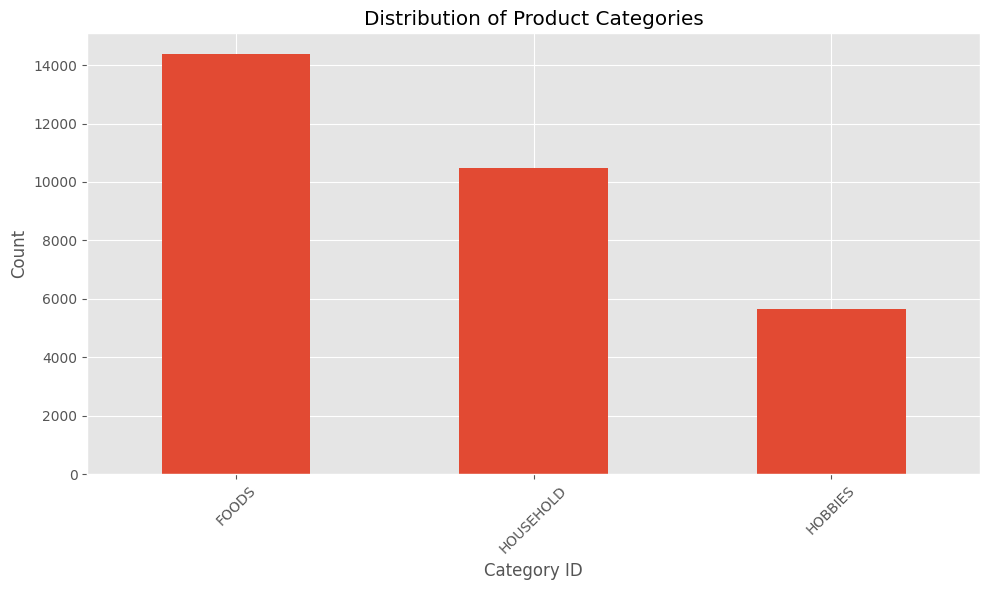

In [ ]:
plt.figure(figsize=(10, 6))
sales_train_evaluation['cat_id'].value_counts().plot(kind='bar')
plt.title('Distribution of Product Categories')
plt.xlabel('Category ID')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

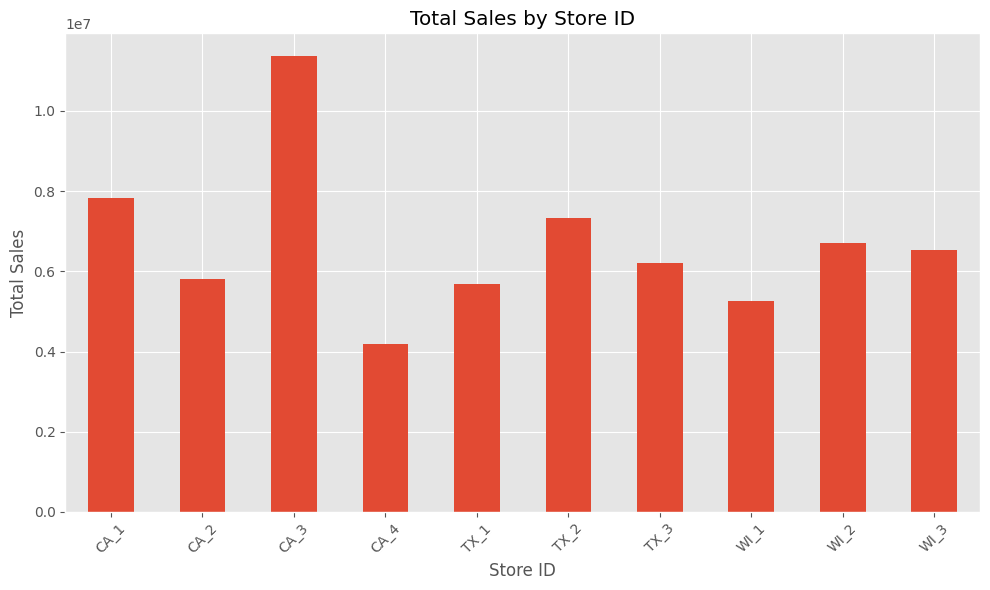

In [ ]:
store_sales = sales_train_evaluation.groupby('store_id')[d_cols].sum().sum(axis=1)

plt.figure(figsize=(10, 6))
store_sales.plot(kind='bar')
plt.title('Total Sales by Store ID')
plt.xlabel('Store ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

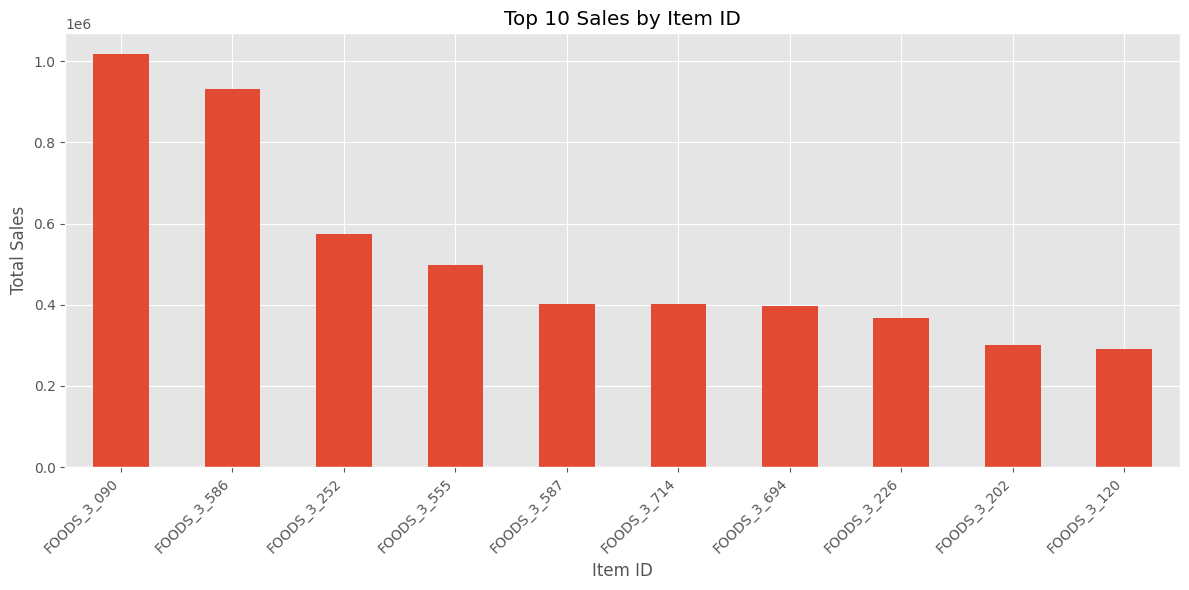


Top 10 selling items:


,0
item_id,
FOODS_3_090,1017916
FOODS_3_586,932236
FOODS_3_252,573723
FOODS_3_555,497881
FOODS_3_587,402159
FOODS_3_714,402111
FOODS_3_694,395937
FOODS_3_226,368369
FOODS_3_202,300529


In [ ]:
item_sales = sales_train_evaluation.groupby('item_id')[d_cols].sum().sum(axis=1)
top_10_items = item_sales.nlargest(10)

plt.figure(figsize=(12, 6))
top_10_items.plot(kind='bar')
plt.title('Top 10 Sales by Item ID')
plt.xlabel('Item ID')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 10 selling items:')
display(top_10_items)

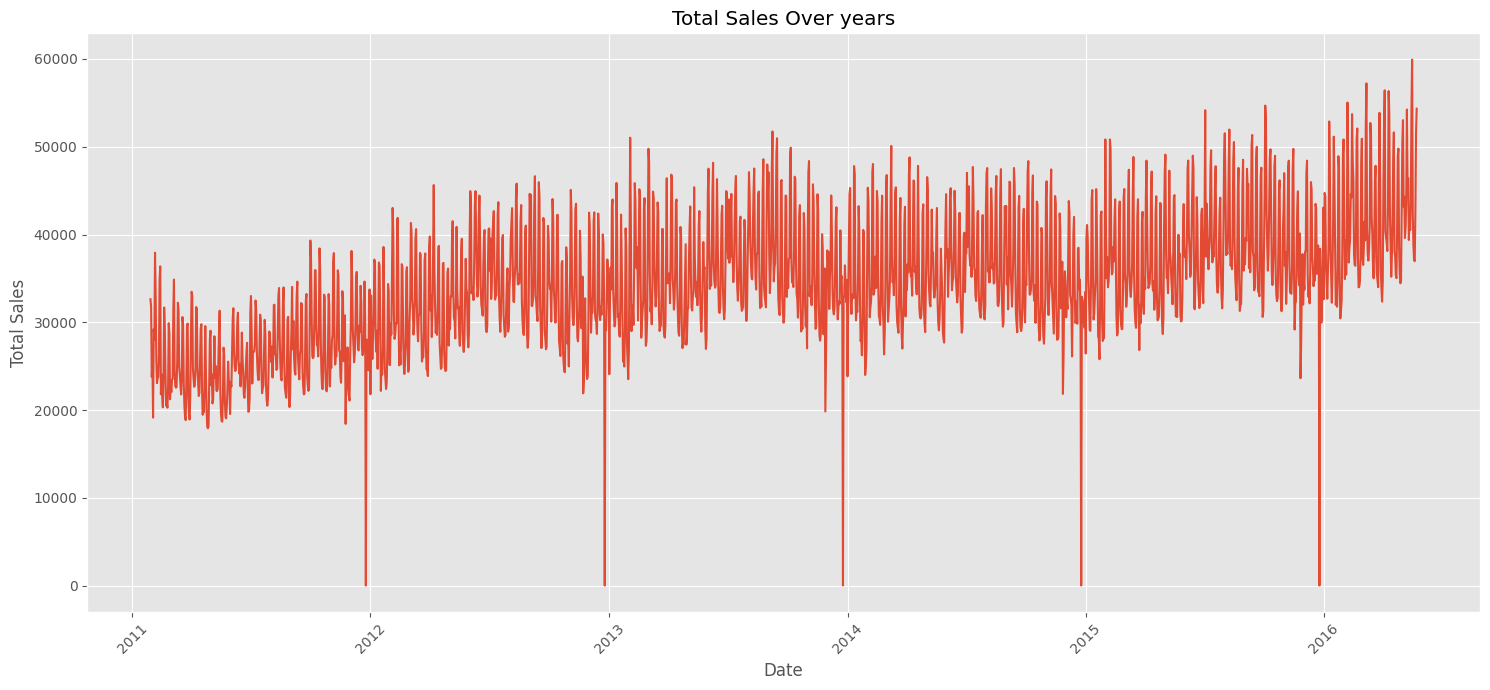

In [ ]:
daily_sales = sales_train_evaluation[d_cols].sum(axis=0)
daily_sales_df = pd.DataFrame({'d': daily_sales.index, 'total_sales': daily_sales.values})

daily_sales_with_date = pd.merge(daily_sales_df, calendar[['d', 'date']], on='d', how='left')
daily_sales_with_date['date'] = pd.to_datetime(daily_sales_with_date['date'])

plt.figure(figsize=(15, 7))
sns.lineplot(x='date', y='total_sales', data=daily_sales_with_date)
plt.title('Total Sales Over years')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

From Exploring the Sales table we know the following:
- highest demanded products are food products.
- numper of saled items (demand) count day by day.
- Transformation and merging are essential to understan.d more about this table.
- products are not defined but labeled by a distinct ID.
- number of unquie products are 3049 product.
- Sales are Increasing over time .

## **Sell Prices Exploration**


In [ ]:
prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6841121 entries, 0 to 6841120
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   store_id    object 
 1   item_id     object 
 2   wm_yr_wk    int64  
 3   sell_price  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 208.8+ MB


In [ ]:
prices.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [ ]:
prices.isnull().sum()

,0
store_id,0
item_id,0
wm_yr_wk,0
sell_price,0


In [ ]:
prices['sell_price'].describe()

,sell_price
count,6.841121e+06
mean,4.410952e+00
std,3.408814e+00
min,1.000000e-02
25%,2.180000e+00
50%,3.470000e+00
75%,5.840000e+00
max,1.073200e+02


In [ ]:
top_10_highest_prices = prices.groupby(['item_id', 'store_id'])['sell_price'].max().nlargest(10)

print('Top 10 highest prices by item_id and store_id:')
display(top_10_highest_prices)

Top 10 highest prices by item_id and store_id:


item_id          store_id
HOUSEHOLD_2_406  WI_3        107.32
                 WI_2         61.46
HOUSEHOLD_2_466  TX_1         52.62
HOUSEHOLD_2_178  TX_1         44.36
HOUSEHOLD_2_406  WI_1         35.88
HOUSEHOLD_2_250  WI_2         34.18
HOBBIES_1_060    CA_1         30.98
                 CA_2         30.98
                 CA_3         30.98
                 CA_4         30.98
Name: sell_price, dtype: float64

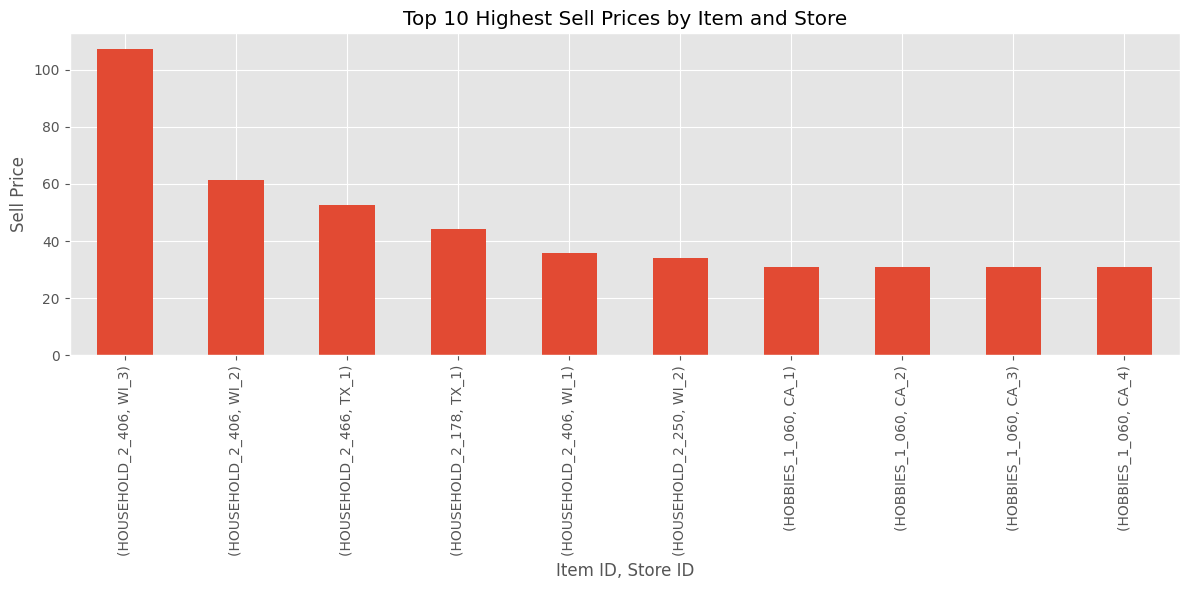

In [ ]:
plt.figure(figsize=(12, 6))
top_10_highest_prices.plot(kind='bar')
plt.title('Top 10 Highest Sell Prices by Item and Store')
plt.xlabel('Item ID, Store ID')
plt.ylabel('Sell Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
top_10_lowest_prices = prices.groupby(['item_id', 'store_id'])['sell_price'].min().nsmallest(10)

print('Top 10 lowest prices by item_id and store_id:')
display(top_10_lowest_prices)

Top 10 lowest prices by item_id and store_id:


,,sell_price
item_id,store_id,
FOODS_3_122,WI_1,0.01
FOODS_3_413,CA_4,0.01
HOBBIES_1_261,CA_3,0.01
HOBBIES_1_338,WI_1,0.01
HOUSEHOLD_1_036,WI_3,0.01
HOUSEHOLD_1_443,CA_1,0.01
HOUSEHOLD_1_533,WI_1,0.01
FOODS_3_410,TX_3,0.02
FOODS_3_498,TX_3,0.02


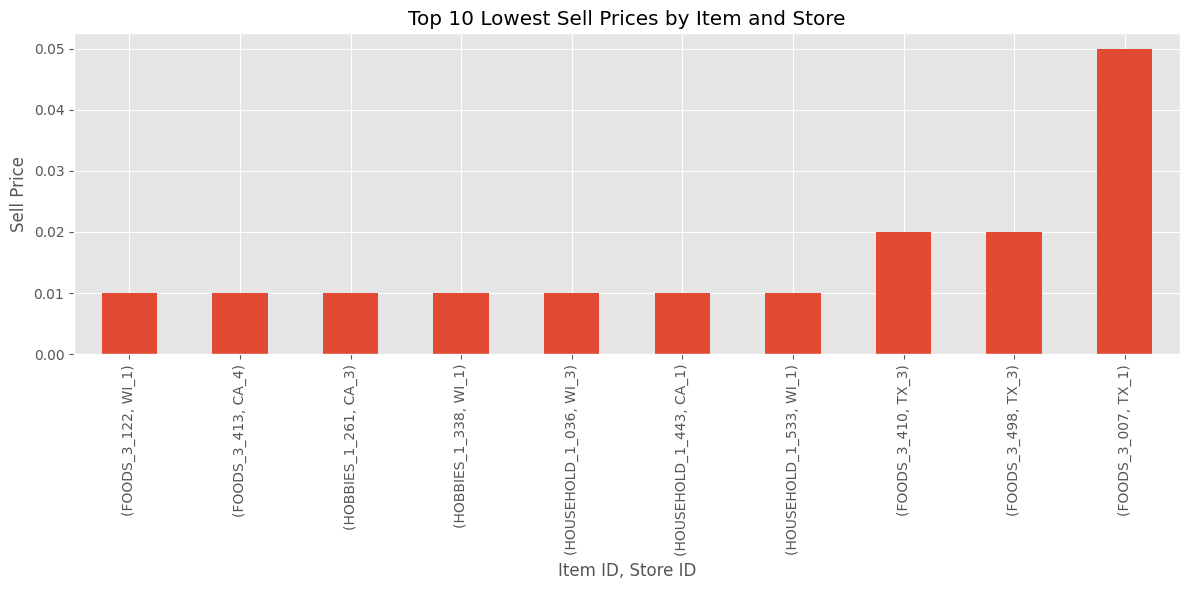

In [ ]:
plt.figure(figsize=(12, 6))
top_10_lowest_prices.plot(kind='bar')
plt.title('Top 10 Lowest Sell Prices by Item and Store')
plt.xlabel('Item ID, Store ID')
plt.ylabel('Sell Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

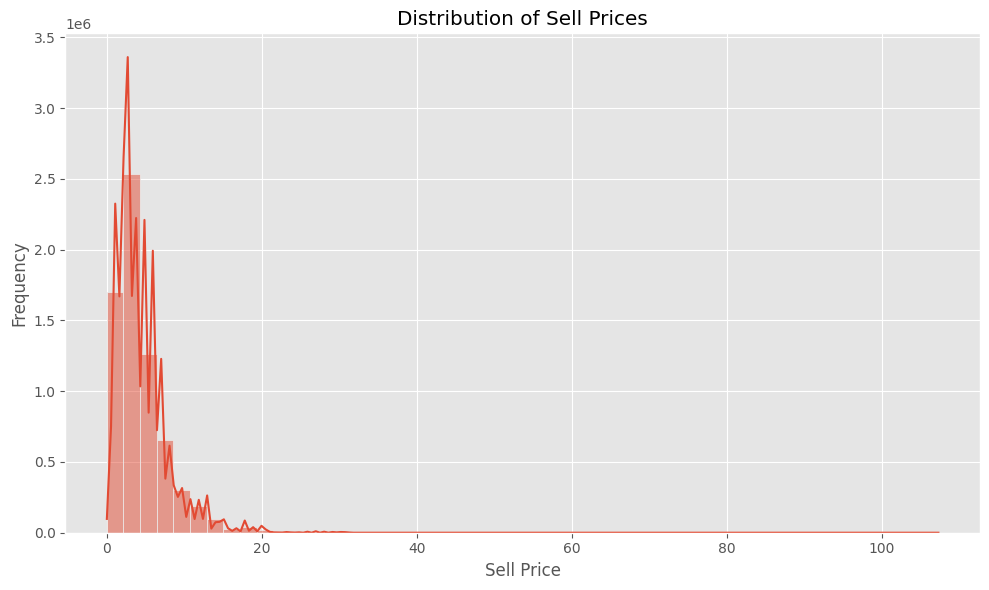

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(prices['sell_price'], bins=50, kde=True)
plt.title('Distribution of Sell Prices')
plt.xlabel('Sell Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

#**Macroeconomic Indicators Data Exploartion**

Abbreviations that commonly refer to macroeconomic indicators include the following:
- CAUR: California unemployment rate
- TXUR: Texas unemployment rate
- WIUR: Wisconsin unemployment rate
- UNRATE: US unemployment rate
- CPIAUCSL: Consumer Price Index for All Urban Consumers: All Items in U.S City Average
- CPIUFDSL: Consumer Price Index for All Urban Consumers: Food in the U.S. City Average
- FEDFUNDS: Federal Funds Effective Rate
- UMCSENT: University of Michigan Consumer Sentiment


In [ ]:
#import data files
CAUR= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/CAUR.csv")
CPIAUCSL= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/CPIAUCSL.csv")
CPIUFDSL= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/CPIUFDSL.csv")
FEDFUNDS= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/FEDFUNDS.csv")
TXUR= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/TXUR.csv")
UNRATE= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/UNRATE.csv")
UMCSENT= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/UMCSENT.csv")
WIUR= pd.read_csv("/content/drive/MyDrive/Graduation Project Data/Macroeconomic Data/WIUR.csv")

In [ ]:
CAUR.info()
CAUR.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   CAUR              67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,CAUR
0,2011-01-01,12.1
1,2011-02-01,12.0
2,2011-03-01,11.9
3,2011-04-01,11.9
4,2011-05-01,11.9


In [ ]:
CPIAUCSL.info()
CPIAUCSL.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   CPIAUCSL          67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,CPIAUCSL
0,2011-01-01,221.187
1,2011-02-01,221.898
2,2011-03-01,223.046
3,2011-04-01,224.093
4,2011-05-01,224.806


In [ ]:
CPIUFDSL.info()
CPIUFDSL.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   CPIUFDSL          67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,CPIUFDSL
0,2011-01-01,222.469
1,2011-02-01,223.504
2,2011-03-01,225.213
3,2011-04-01,226.072
4,2011-05-01,226.940


In [ ]:
FEDFUNDS.info()
FEDFUNDS.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  74 non-null     object 
 1   FEDFUNDS          74 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


,observation_date,FEDFUNDS
0,2010-11-01,0.19
1,2010-12-01,0.18
2,2011-01-01,0.17
3,2011-02-01,0.16
4,2011-03-01,0.14


In [ ]:
TXUR.info()
TXUR.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   TXUR              67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,TXUR
0,2011-01-01,8.2
1,2011-02-01,8.2
2,2011-03-01,8.1
3,2011-04-01,8.1
4,2011-05-01,8.2


In [ ]:
UNRATE.info()
UNRATE.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   UNRATE            67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,UNRATE
0,2011-01-01,9.1
1,2011-02-01,9.0
2,2011-03-01,9.0
3,2011-04-01,9.1
4,2011-05-01,9.0


In [ ]:
UMCSENT.info()
UMCSENT.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  73 non-null     object 
 1   UMCSENT           73 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


,observation_date,UMCSENT
0,2010-12-01,74.5
1,2011-01-01,74.2
2,2011-02-01,77.5
3,2011-03-01,67.5
4,2011-04-01,69.8


In [ ]:
WIUR.info()
WIUR.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  67 non-null     object 
 1   WIUR              67 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.2+ KB


,observation_date,WIUR
0,2011-01-01,7.8
1,2011-02-01,7.7
2,2011-03-01,7.6
3,2011-04-01,7.6
4,2011-05-01,7.6


###**Stationary Test**

In [ ]:

def run_adfuller_test(series, name, column_name, alpha=0.05):
    print(f"\n--- ADF Test for {column_name} of {name} ---")
    if len(series.dropna()) == 0:
        print("No data available for testing.")
        return

    try:
        result = adfuller(series.dropna())
        print(f'ADF Statistic: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print('Critical Values:')
        for key, value in result[4].items():
            print(f'   {key}: {value:.4f}')

        if result[1] <= alpha:
            print(f"Conclusion: {column_name} for {name} is likely Stationary (reject H0)")
        else:
            print(f"Conclusion: {column_name} for {name} is likely Non-Stationary (fail to reject H0)")
    except Exception as e:
        print(f"Error performing ADF test: {e}")

In [ ]:
# Run ADF test for UMCSENT
run_adfuller_test(UMCSENT['UMCSENT'], 'Macroeconomic Data', 'UMCSENT')

# Run ADF test for FEDFUNDS
run_adfuller_test(FEDFUNDS['FEDFUNDS'], 'Macroeconomic Data', 'FEDFUNDS')


--- ADF Test for UMCSENT of Macroeconomic Data ---
ADF Statistic: -1.3516
p-value: 0.6052
Critical Values:
   1%: -3.5246
   5%: -2.9026
   10%: -2.5887
Conclusion: UMCSENT for Macroeconomic Data is likely Non-Stationary (fail to reject H0)

--- ADF Test for FEDFUNDS of Macroeconomic Data ---
ADF Statistic: 0.8265
p-value: 0.9921
Critical Values:
   1%: -3.5444
   5%: -2.9111
   10%: -2.5932
Conclusion: FEDFUNDS for Macroeconomic Data is likely Non-Stationary (fail to reject H0)


### Differencing Non-Stationary Series

To make the `UMCSENT` and `FEDFUNDS` series stationary, we will apply a first-order differencing. This involves calculating the difference between consecutive observations.


In [ ]:
# Apply first-order differencing to UMCSENT and FEDFUNDS
UMCSENT['UMCSENT_diff'] = UMCSENT['UMCSENT'].diff()
FEDFUNDS['FEDFUNDS_diff'] = FEDFUNDS['FEDFUNDS'].diff()

print("First-order differencing applied to UMCSENT and FEDFUNDS.")
display(FEDFUNDS[['FEDFUNDS', 'FEDFUNDS_diff']].head())
display(UMCSENT[['UMCSENT', 'UMCSENT_diff']].head())

First-order differencing applied to UMCSENT and FEDFUNDS.


,FEDFUNDS,FEDFUNDS_diff
0,0.19,NaN
1,0.18,-0.01
2,0.17,-0.01
3,0.16,-0.01
4,0.14,-0.02


,UMCSENT,UMCSENT_diff
0,74.5,NaN
1,74.2,-0.3
2,77.5,3.3
3,67.5,-10.0
4,69.8,2.3


### Re-running Stationary Test on Differenced Macroeconomic Indicators

In [ ]:
# Run ADF test for differenced UMCSENT
run_adfuller_test(UMCSENT['UMCSENT_diff'], 'Macroeconomic Data', 'UMCSENT_diff')

# Run ADF test for differenced FEDFUNDS
run_adfuller_test(FEDFUNDS['FEDFUNDS_diff'], 'Macroeconomic Data', 'FEDFUNDS_diff')


--- ADF Test for UMCSENT_diff of Macroeconomic Data ---
ADF Statistic: -8.2602
p-value: 0.0000
Critical Values:
   1%: -3.5260
   5%: -2.9032
   10%: -2.5890
Conclusion: UMCSENT_diff for Macroeconomic Data is likely Stationary (reject H0)

--- ADF Test for FEDFUNDS_diff of Macroeconomic Data ---
ADF Statistic: -0.0479
p-value: 0.9544
Critical Values:
   1%: -3.5424
   5%: -2.9102
   10%: -2.5927
Conclusion: FEDFUNDS_diff for Macroeconomic Data is likely Non-Stationary (fail to reject H0)


### KPSS (Kwiatkowski-Phillips-Schmidt-Shin) Test

The KPSS test is another method to test for stationarity. Unlike ADF, the null hypothesis of the KPSS test is that the series is trend-stationary. A low p-value (typically < 0.05) suggests that the series is non-stationary, while a high p-value suggests stationarity.

In [ ]:


def run_kpss_test(series, name, column_name, alpha=0.05):
    print(f"\n--- KPSS Test for {column_name} of {name} ---")
    if len(series.dropna()) == 0:
        print("No data available for testing.")
        return

    try:
        # The 'c' option is for trend-stationary (default in adfuller is usually 'c' or 'ct')
        # For difference-stationary, we typically use 'c' (constant) or 'ct' (constant and trend)
        # Since we are checking for trend-stationarity (null hypothesis), 'ct' is appropriate if a trend is suspected
        # If we expect the series to be level-stationary after differencing, 'c' is better
        # Given that ADF already checked for difference stationarity, and we're just differencing, 'c' (level stationary) is more suitable here.
        kpss_result = kpss(series.dropna(), regression='c', nlags='auto') # Using 'c' for level stationarity
        kpss_statistic = kpss_result[0]
        p_value = kpss_result[1]
        critical_values = kpss_result[3]

        print(f'KPSS Statistic: {kpss_statistic:.4f}')
        print(f'p-value: {p_value:.4f}')
        print('Critical Values:')
        for key, value in critical_values.items():
            print(f'   {key}: {value:.4f}')

        if p_value < alpha:
            print(f"Conclusion: {column_name} for {name} is likely Non-Stationary (reject H0 that it's level stationary)")
        else:
            print(f"Conclusion: {column_name} for {name} is likely Level Stationary (fail to reject H0)")
    except Exception as e:
        print(f"Error performing KPSS test: {e}")

### Running KPSS Test on Differenced Series

In [ ]:
# Run KPSS test for differenced UMCSENT
run_kpss_test(UMCSENT['UMCSENT'], 'Macroeconomic Data', 'UMCSENT')

# Run KPSS test for differenced FEDFUNDS
run_kpss_test(FEDFUNDS['FEDFUNDS'], 'Macroeconomic Data', 'FEDFUNDS')


--- KPSS Test for UMCSENT of Macroeconomic Data ---
KPSS Statistic: 1.1386
p-value: 0.0100
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: UMCSENT for Macroeconomic Data is likely Non-Stationary (reject H0 that it's level stationary)

--- KPSS Test for FEDFUNDS of Macroeconomic Data ---
KPSS Statistic: 0.6400
p-value: 0.0190
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: FEDFUNDS for Macroeconomic Data is likely Non-Stationary (reject H0 that it's level stationary)


/tmp/ipykernel_18013/513624464.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto') # Using 'c' for level stationarity


In [ ]:
# Run KPSS test for differenced UMCSENT
run_kpss_test(UMCSENT['UMCSENT_diff'], 'Macroeconomic Data', 'UMCSENT_diff')

# Run KPSS test for differenced FEDFUNDS
run_kpss_test(FEDFUNDS['FEDFUNDS_diff'], 'Macroeconomic Data', 'FEDFUNDS_diff')


--- KPSS Test for UMCSENT_diff of Macroeconomic Data ---
KPSS Statistic: 0.0614
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: UMCSENT_diff for Macroeconomic Data is likely Level Stationary (fail to reject H0)

--- KPSS Test for FEDFUNDS_diff of Macroeconomic Data ---
KPSS Statistic: 0.6536
p-value: 0.0178
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: FEDFUNDS_diff for Macroeconomic Data is likely Non-Stationary (reject H0 that it's level stationary)


/tmp/ipykernel_2028/513624464.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto') # Using 'c' for level stationarity


In [ ]:
FEDFUNDS['FEDFUNDS_diff2'] = FEDFUNDS['FEDFUNDS_diff'].diff()
print("Second-order differencing applied to FEDFUNDS_diff.")


Second-order differencing applied to FEDFUNDS_diff.


In [ ]:
# Run KPSS test for differenced FEDFUNDS
run_kpss_test(FEDFUNDS['FEDFUNDS_diff2'], 'Macroeconomic Data', 'FEDFUNDS_diff2')
run_adfuller_test(FEDFUNDS['FEDFUNDS_diff2'], 'Macroeconomic Data', 'FEDFUNDS_diff2')


--- KPSS Test for FEDFUNDS_diff2 of Macroeconomic Data ---
KPSS Statistic: 0.1875
p-value: 0.1000
Critical Values:
   10%: 0.3470
   5%: 0.4630
   2.5%: 0.5740
   1%: 0.7390
Conclusion: FEDFUNDS_diff2 for Macroeconomic Data is likely Level Stationary (fail to reject H0)

--- ADF Test for FEDFUNDS_diff2 of Macroeconomic Data ---
ADF Statistic: -5.8355
p-value: 0.0000
Critical Values:
   1%: -3.5424
   5%: -2.9102
   10%: -2.5927
Conclusion: FEDFUNDS_diff2 for Macroeconomic Data is likely Stationary (reject H0)


/tmp/ipykernel_2028/513624464.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto') # Using 'c' for level stationarity


In [ ]:
#drop NAN Values
FEDFUNDS = FEDFUNDS.dropna().reset_index(drop=True)
UMCSENT = UMCSENT.dropna().reset_index(drop=True)

,observation_date,UMCSENT,UMCSENT_diff
1,2011-01-01,74.2,-0.3
2,2011-02-01,77.5,3.3
3,2011-03-01,67.5,-10.0
4,2011-04-01,69.8,2.3
5,2011-05-01,74.3,4.5
...,...,...,...
68,2016-08-01,89.8,-0.2
69,2016-09-01,91.2,1.4
70,2016-10-01,87.2,-4.0
71,2016-11-01,93.8,6.6


In [ ]:
#drop nonstationary columns
FEDFUNDS = FEDFUNDS.drop(columns=['FEDFUNDS', 'FEDFUNDS_diff'])
UMCSENT = UMCSENT.drop(columns=['UMCSENT'])

In [ ]:

FEDFUNDS.info()
UMCSENT.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  72 non-null     object 
 1   FEDFUNDS_diff2    72 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  72 non-null     object 
 1   UMCSENT_diff      72 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.3+ KB


## Merge Sesonaly Adjusted Macroeconomic Data

What is Purchasing Power?

Purchasing power = how much goods/services consumers can buy with their income

👉 It is mainly affected by:

- Inflation (CPI)
- Income / Employment
- Interest Rates
- Consumer Confidence



Technical Interpretation of Purchasing Power (Simple)
1. Inflation (CPI) ↑
What happens technically:
Prices increase → real value of money decreases
Simple meaning:
Same salary buys less stuff
In your data:
CPI is rising → purchasing power goes down
2. Unemployment ↓
What happens technically:
More people working → aggregate income increases
Simple meaning:
More jobs → more money → people can buy more
In your data:
Unemployment is falling → purchasing power goes up
3. Interest Rate (FEDFUNDS) ↑
What happens technically:
Cost of borrowing increases → credit demand decreases
Simple meaning:
Loans (car, house, credit card) become expensive → people spend less
In your data:
Rates increase after 2015 → purchasing power slightly goes down
4. Consumer Sentiment ↑
What happens technically:
Higher confidence → increase in consumption function (C)
Simple meaning:
People feel safe → they spend more
In your data:
Sentiment rises → purchasing power goes up

In [ ]:
macro_dfs = [
    CAUR,
    CPIAUCSL,
    CPIUFDSL,
    FEDFUNDS,
    TXUR,
    UNRATE,
    UMCSENT,
    WIUR
]
df_names = [
    'CAUR',
    'CPIAUCSL',
    'CPIUFDSL',
    'FEDFUNDS',
    'TXUR',
    'UNRATE',
    'UMCSENT',
    'WIUR'
]

# Merge all macroeconomic dataframes
macro_df = CAUR.copy()
for df, name in zip(macro_dfs[1:], df_names[1:]):
    macro_df = pd.merge(macro_df, df, on='observation_date', how='outer')

# Sort by date
macro_df = macro_df.sort_values(by='observation_date').reset_index(drop=True)

# Convert 'observation_date' to datetime objects
macro_df['observation_date'] = pd.to_datetime(macro_df['observation_date'])

display(macro_df.head())

,observation_date,CAUR,CPIAUCSL,CPIUFDSL,FEDFUNDS_diff2,TXUR,UNRATE,UMCSENT_diff,WIUR
0,2011-01-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
1,2011-02-01,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7
2,2011-03-01,11.9,223.046,225.213,-1.000000e-02,8.1,9.0,-10.0,7.6
3,2011-04-01,11.9,224.093,226.072,-2.000000e-02,8.1,9.1,2.3,7.6
4,2011-05-01,11.9,224.806,226.940,3.000000e-02,8.2,9.0,4.5,7.6


In [ ]:
macro_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72 entries, 0 to 71
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  72 non-null     datetime64[ns]
 1   CAUR              67 non-null     float64       
 2   CPIAUCSL          67 non-null     float64       
 3   CPIUFDSL          67 non-null     float64       
 4   FEDFUNDS_diff2    72 non-null     float64       
 5   TXUR              67 non-null     float64       
 6   UNRATE            67 non-null     float64       
 7   UMCSENT_diff      72 non-null     float64       
 8   WIUR              67 non-null     float64       
dtypes: datetime64[ns](1), float64(8)
memory usage: 5.2 KB


Now that all macroeconomic indicators are in a single DataFrame, I will plot their trends over time.

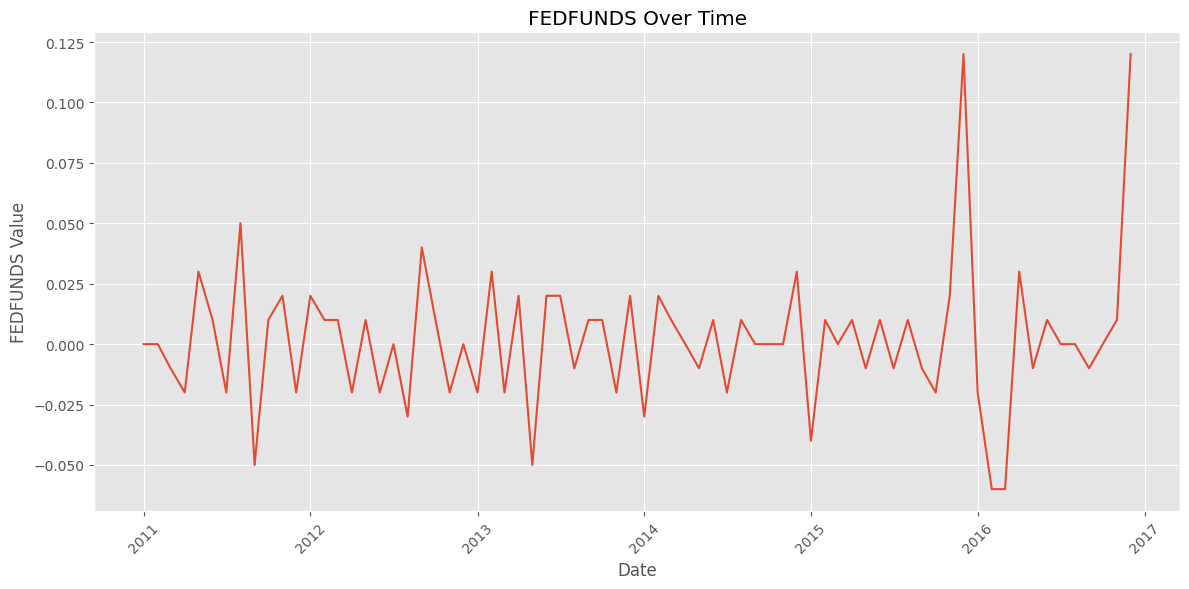

In [ ]:

plt.figure(figsize=(12, 6))
sns.lineplot(x='observation_date', y='FEDFUNDS_diff2', data=macro_df)
plt.title('FEDFUNDS Over Time')
plt.xlabel('Date')
plt.ylabel('FEDFUNDS Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

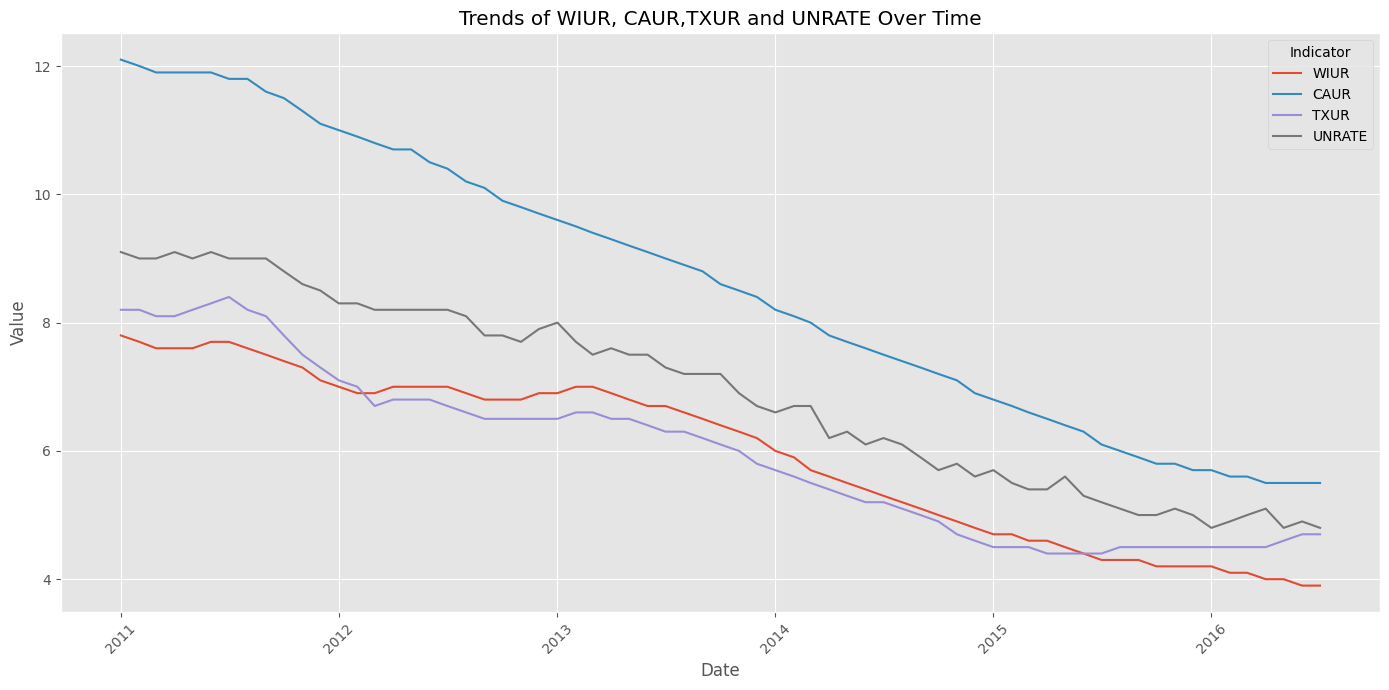

In [ ]:
plt.figure(figsize=(14, 7))

# List of columns to plot
columns_to_plot = ['WIUR', 'CAUR','TXUR', 'UNRATE']

for column in columns_to_plot:
    sns.lineplot(x='observation_date', y=column, data=macro_df, label=column)

plt.title('Trends of WIUR, CAUR,TXUR and UNRATE Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(title='Indicator')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

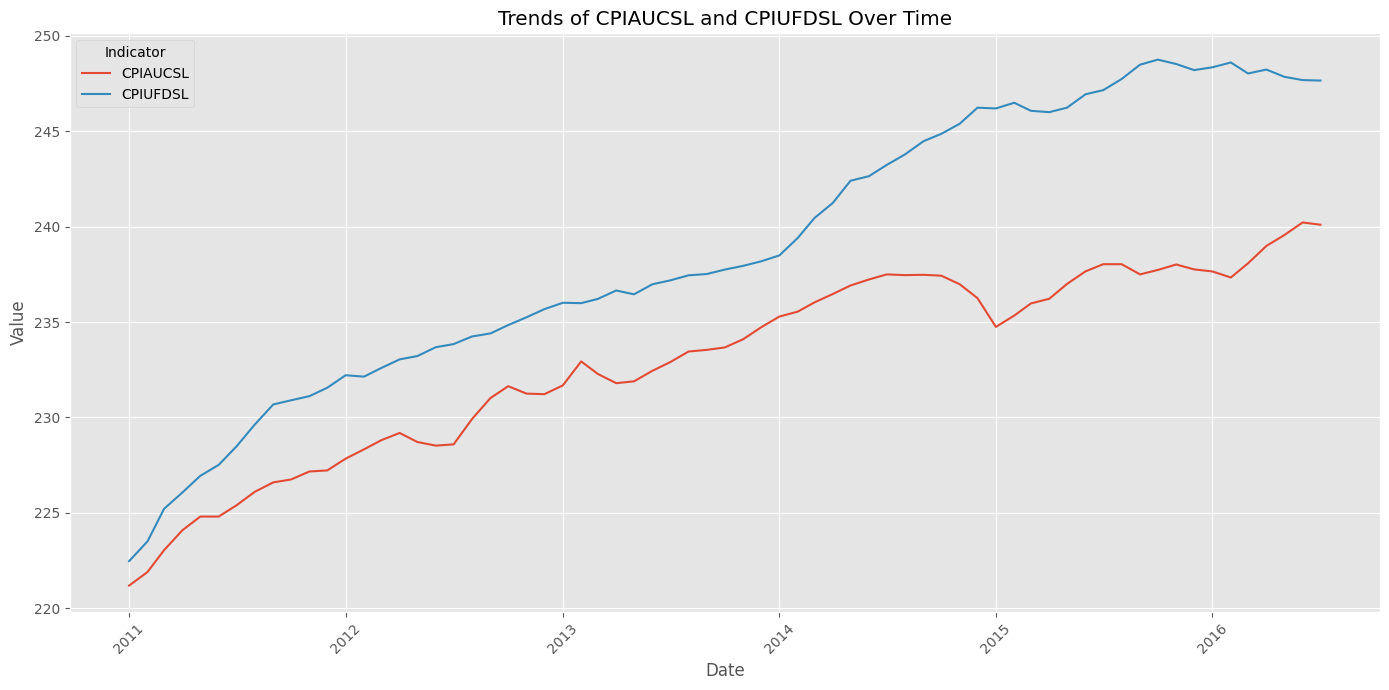

In [ ]:

plt.figure(figsize=(14, 7))

# List of columns to plot
columns_to_plot = ['CPIAUCSL', 'CPIUFDSL']

for column in columns_to_plot:
    sns.lineplot(x='observation_date', y=column, data=macro_df, label=column)

plt.title('Trends of CPIAUCSL and CPIUFDSL Over Time')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend(title='Indicator')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

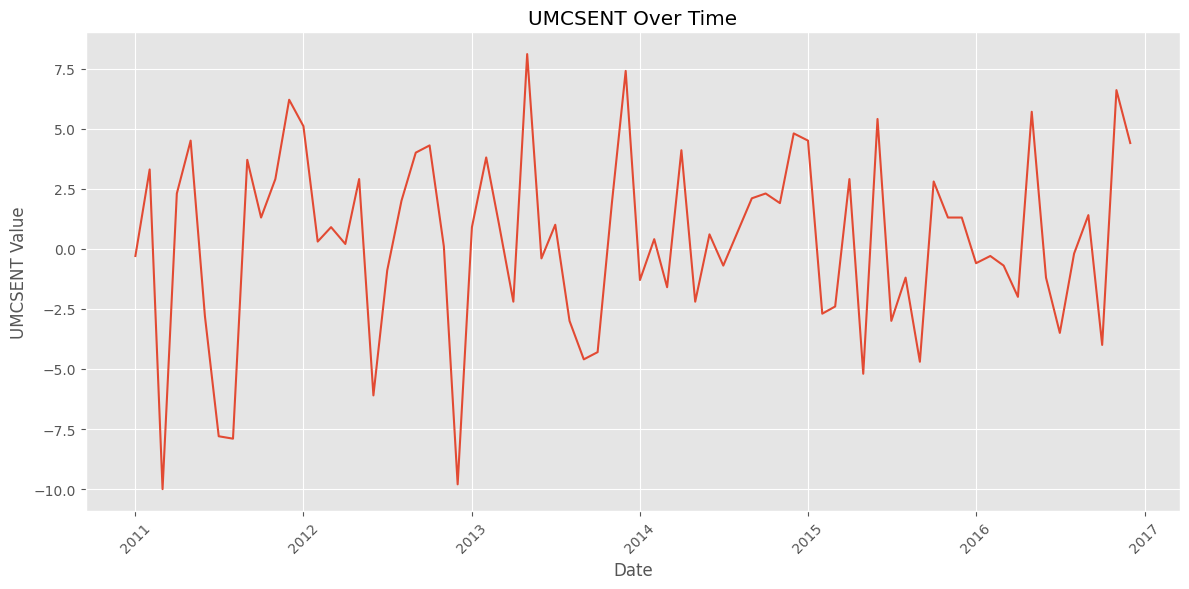

In [ ]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='observation_date', y='UMCSENT_diff', data=macro_df)
plt.title('UMCSENT Over Time')
plt.xlabel('Date')
plt.ylabel('UMCSENT Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **Data Integration and Feature Engineering**

In [ ]:
# Fill NaN values in event columns with 'no event'
for col in ['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
    if col in calendar.columns:
        calendar[col] = calendar[col].fillna('no event')

print('Null values in event columns after filling:')
display(calendar[['event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']].isnull().sum())

Null values in event columns after filling:


,0
event_name_1,0
event_type_1,0
event_name_2,0
event_type_2,0


In [ ]:
#merging the same data tables to get one data frame sales
sales_data = sales_train_evaluation.melt(id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'], var_name='d', value_name='demand')
sales_data = pd.merge(sales_data, calendar, on='d', how='left')

print("Shape of the merged sales_data:", sales_data.shape)
display(sales_data.head())

Shape of the merged sales_data: (59181090, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,no event,no event,no event,no event,0,0,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,no event,no event,no event,no event,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,no event,no event,no event,no event,0,0,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,no event,no event,no event,no event,0,0,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,1,2011,no event,no event,no event,no event,0,0,0


In [ ]:
first_sales_date = sales_data['date'].min()
last_sales_date = sales_data['date'].max()

print(f"First date in sales data: {first_sales_date}")
print(f"Last date in sales data: {last_sales_date}")

First date in sales data: 2011-01-29
Last date in sales data: 2016-05-22


In [ ]:
sales_data.shape

(59181090, 21)

In [ ]:
sales_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59181090 entries, 0 to 59181089
Data columns (total 21 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   id            object
 1   item_id       object
 2   dept_id       object
 3   cat_id        object
 4   store_id      object
 5   state_id      object
 6   d             object
 7   demand        int64 
 8   date          object
 9   wm_yr_wk      int64 
 10  weekday       object
 11  wday          int64 
 12  month         int64 
 13  year          int64 
 14  event_name_1  object
 15  event_type_1  object
 16  event_name_2  object
 17  event_type_2  object
 18  snap_CA       int64 
 19  snap_TX       int64 
 20  snap_WI       int64 
dtypes: int64(8), object(13)
memory usage: 9.3+ GB


In [ ]:
print('Checking for null values in sales_data:')
display(sales_data.isnull().sum())

Checking for null values in sales_data:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


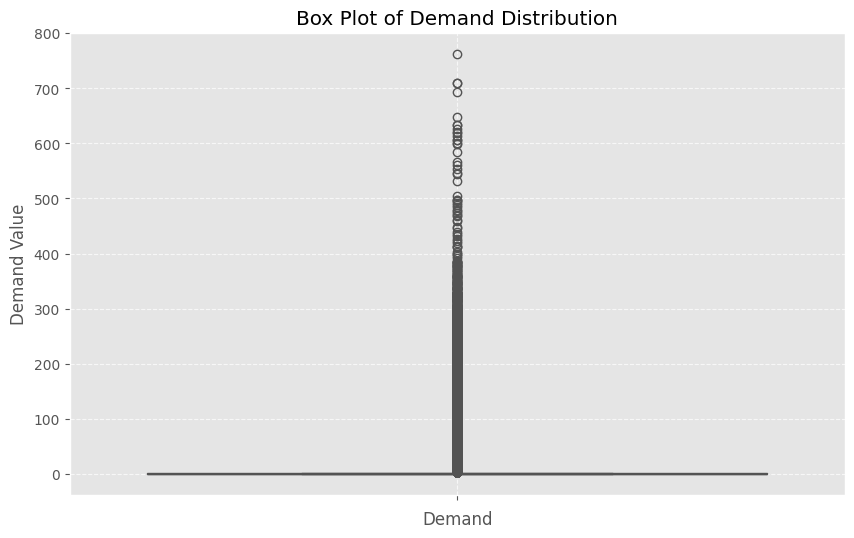

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=sales_data['demand'])
plt.title('Box Plot of Demand Distribution')
plt.xlabel('Demand')
plt.ylabel('Demand Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

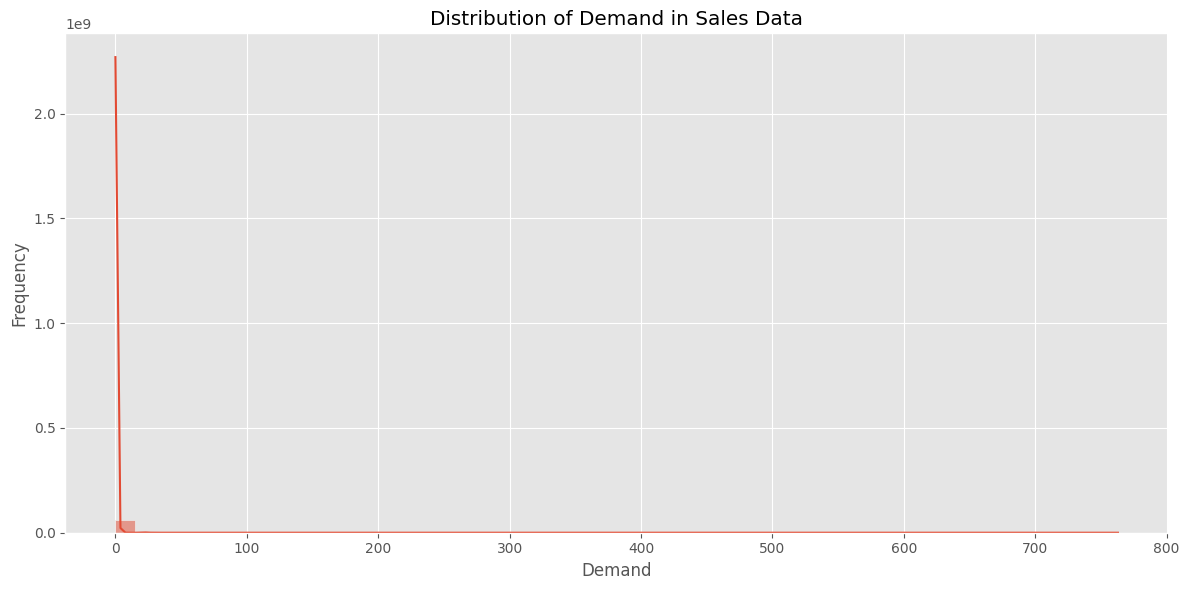

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(sales_data['demand'], bins=50, kde=True)
plt.title('Distribution of Demand in Sales Data')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
#make prices daily
prices = pd.merge(prices, calendar[['wm_yr_wk', 'date']], on='wm_yr_wk', how='left')

print("Shape of prices after merging with calendar:", prices.shape)
display(prices.head())

Shape of prices after merging with calendar: (47735397, 5)


,store_id,item_id,wm_yr_wk,sell_price,date
0,CA_1,HOBBIES_1_001,11325,9.58,2013-07-13
1,CA_1,HOBBIES_1_001,11325,9.58,2013-07-14
2,CA_1,HOBBIES_1_001,11325,9.58,2013-07-15
3,CA_1,HOBBIES_1_001,11325,9.58,2013-07-16
4,CA_1,HOBBIES_1_001,11325,9.58,2013-07-17


In [ ]:
prices.to_csv('/content/drive/MyDrive/Graduation Project Data/daily_prices.csv', index=False)
print('daily_prices.csv saved successfully to Google Drive.')

daily_prices.csv saved successfully to Google Drive.


In [ ]:
first_price_date = prices['date'].min()
last_price_date = prices['date'].max()

print(f"First date in price data: {first_price_date }")
print(f"Last date in prices data: {last_price_date}")

First date in price data: 2011-01-29
Last date in prices data: 2016-06-19


In [ ]:
print('Checking for null values in prices:')
display(prices.isnull().sum())

Checking for null values in prices:


,0
store_id,0
item_id,0
wm_yr_wk,0
sell_price,0
date,0


In [ ]:
print(f"Unique number of items in prices: {prices['item_id'].nunique()}")

Unique number of items in prices: 3049


In [ ]:
print(f"Unique number of items in sales_data: {sales_data['item_id'].nunique()}")

Unique number of items in sales_data: 3049


# **Sampling Without Replacement**

In [ ]:
# Step 1: build entity-level population
df_entities = sales_data[['state_id', 'store_id', 'item_id']].drop_duplicates().copy()
df_entities.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30490 entries, 0 to 30489
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   state_id  30490 non-null  object
 1   store_id  30490 non-null  object
 2   item_id   30490 non-null  object
dtypes: object(3)
memory usage: 952.8+ KB


In [ ]:
# Step 2: Compute entity-level average demand
# This is used only for stratification, not for model target replacement

entity_demand = (
    sales_data.groupby(['state_id', 'store_id', 'item_id'], as_index=False)['demand']
    .mean()
    .rename(columns={'demand': 'avg_demand'})
)

# Merge average demand into entity table
df_entities = df_entities.merge(
    entity_demand,
    on=['state_id', 'store_id', 'item_id'],
    how='left'
)

print("Entity population shape:", df_entities.shape)
display(df_entities.head())

Entity population shape: (30490, 4)


,state_id,store_id,item_id,avg_demand
0,CA,CA_1,HOBBIES_1_001,0.326121
1,CA,CA_1,HOBBIES_1_002,0.257599
2,CA,CA_1,HOBBIES_1_003,0.159196
3,CA,CA_1,HOBBIES_1_004,1.719217
4,CA,CA_1,HOBBIES_1_005,0.972694


In [ ]:
# Step 3: Create demand quantile groups
# q=3 gives: low / medium / high
# duplicates='drop' avoids failure if repeated values are heavy

df_entities['demand_group'] = pd.qcut(
    df_entities['avg_demand'],
    q=3,
    labels=['low', 'medium', 'high'],
    duplicates='drop'
)

print("\nDemand group distribution:")
display(df_entities['demand_group'].value_counts(dropna=False))

# Optional check by state
print("\nDemand group distribution by state:")
display(pd.crosstab(df_entities['state_id'], df_entities['demand_group']))



Demand group distribution:


,count
demand_group,
low,10167
high,10163
medium,10160



Demand group distribution by state:


demand_group,low,medium,high
state_id,,,
CA,3600,4128,4468
TX,3261,3078,2808
WI,3306,2954,2887


In [ ]:
# Step 4: Calculate sample size for ONE group
Z = 1.96
p = 0.5
E = 0.05

N = len(df_entities)

n0 = (Z**2 * p * (1 - p)) / (E**2)
n = n0 / (1 + ((n0 - 1) / N))
n = math.ceil(n)

print("\nEntity population size:", N)
print("Sample size per group:", n)



Entity population size: 30490
Sample size per group: 380


In [ ]:
# Step 5: Proportional allocation by state_id + demand_group
# This preserves the natural joint distribution
strata_counts = (
    df_entities.groupby(['state_id', 'demand_group'], observed=False) # Changed this line
    .size()
    .reset_index(name='N_h')
)

# Initial proportional allocation
strata_counts['n_h'] = (strata_counts['N_h'] / N * n).round().astype(int)

In [ ]:
# Adjust n_h so the total equals n exactly
difference = n - strata_counts['n_h'].sum()

if difference != 0:
    # Sort by largest strata first so adjustments happen sensibly
    strata_counts = strata_counts.sort_values('N_h', ascending=False).reset_index(drop=True)

    if difference > 0:
        for i in range(difference):
            strata_counts.loc[i % len(strata_counts), 'n_h'] += 1
    else:
        to_remove = abs(difference)
        i = 0
        removed = 0
        while removed < to_remove and i < 100000:
            idx = i % len(strata_counts)
            if strata_counts.loc[idx, 'n_h'] > 0:
                strata_counts.loc[idx, 'n_h'] -= 1
                removed += 1
            i += 1
print("\nStrata counts and allocations:")
display(strata_counts)
print("Total allocated per group:", strata_counts['n_h'].sum())


Strata counts and allocations:


,state_id,demand_group,N_h,n_h
0,CA,low,3600,45
1,CA,medium,4128,51
2,CA,high,4468,56
3,TX,low,3261,41
4,TX,medium,3078,38
5,TX,high,2808,35
6,WI,low,3306,41
7,WI,medium,2954,37
8,WI,high,2887,36


Total allocated per group: 380


In [ ]:
# Step 6:  check number of entites
# To create 3 distinct groups, each stratum should ideally have
# enough entities to support 3 * n_h
strata_counts['required_for_3_groups'] = strata_counts['n_h'] * 3
strata_counts['enough_for_3_groups'] = strata_counts['N_h'] >= strata_counts['required_for_3_groups']

print("\nSafety check for 3 distinct groups:")
display(strata_counts[['state_id', 'demand_group', 'N_h', 'n_h', 'required_for_3_groups', 'enough_for_3_groups']])

if not strata_counts['enough_for_3_groups'].all():
    print("\nWARNING: Some strata do not have enough entities to support 3 fully distinct groups with current n_h.")
    print("You may need to reduce sample size per group or use a fallback strategy.")



Safety check for 3 distinct groups:


,state_id,demand_group,N_h,n_h,required_for_3_groups,enough_for_3_groups
0,CA,low,3600,45,135,True
1,CA,medium,4128,51,153,True
2,CA,high,4468,56,168,True
3,TX,low,3261,41,123,True
4,TX,medium,3078,38,114,True
5,TX,high,2808,35,105,True
6,WI,low,3306,41,123,True
7,WI,medium,2954,37,111,True
8,WI,high,2887,36,108,True


In [ ]:
# Step 7: Function to create 3 mutually exclusive groups
# stratified by state_id + demand_group
def create_three_distinct_groups_with_demand_strata(df_entities, strata_counts, base_random_state=42):
    """
    Create 3 mutually exclusive sample groups:
    A, B, C

    Stratification variables:
    - state_id
    - demand_group

    Sampling is without replacement across groups.
    """
    remaining_entities = df_entities.copy()
    sampled_groups = {}

    for group_idx, group_name in enumerate(['A', 'B', 'C']):
        sampled_parts = []

        for _, row in strata_counts.iterrows():
            state = row['state_id']
            demand_group = row['demand_group']
            n_h = row['n_h']

            # Skip empty allocation
            if n_h == 0:
                continue

            # Remaining pool for this stratum
            stratum_subset = remaining_entities[
                (remaining_entities['state_id'] == state) &
                (remaining_entities['demand_group'] == demand_group)
            ]

            if len(stratum_subset) < n_h:
                raise ValueError(
                    f"Not enough remaining entities in stratum "
                    f"(state_id={state}, demand_group={demand_group}) "
                    f"for Group {group_name}. Required: {n_h}, Available: {len(stratum_subset)}"
                )

            sampled_stratum = stratum_subset.sample(
                n=n_h,
                random_state=base_random_state + group_idx,
                replace=False
            )

            sampled_parts.append(sampled_stratum)

        # Combine sampled strata for this group
        group_df = pd.concat(sampled_parts, ignore_index=True)

        sampled_groups[group_name] = group_df

        # Remove sampled rows from remaining pool
        remaining_entities = remaining_entities.merge(
            group_df[['state_id', 'store_id', 'item_id']],
            on=['state_id', 'store_id', 'item_id'],
            how='left',
            indicator=True
        )

        remaining_entities = remaining_entities[remaining_entities['_merge'] == 'left_only'] \
            .drop(columns=['_merge']) \
            .reset_index(drop=True)

    return sampled_groups, remaining_entities



In [ ]:
# Step 8: Create Sample A, B, C
sampled_groups, remaining_entities = create_three_distinct_groups_with_demand_strata(
    df_entities=df_entities,
    strata_counts=strata_counts,
    base_random_state=42
)

sampled_entities_A = sampled_groups['A']
sampled_entities_B = sampled_groups['B']
sampled_entities_C = sampled_groups['C']

print("\nSample shapes:")
print("Sample A:", sampled_entities_A.shape)
print("Sample B:", sampled_entities_B.shape)
print("Sample C:", sampled_entities_C.shape)
print("Remaining entities:", remaining_entities.shape)



Sample shapes:
Sample A: (380, 5)
Sample B: (380, 5)
Sample C: (380, 5)
Remaining entities: (29350, 5)


In [ ]:
# Step 9: Verify distinctness
set_A = set(map(tuple, sampled_entities_A[['state_id', 'store_id', 'item_id']].to_numpy()))
set_B = set(map(tuple, sampled_entities_B[['state_id', 'store_id', 'item_id']].to_numpy()))
set_C = set(map(tuple, sampled_entities_C[['state_id', 'store_id', 'item_id']].to_numpy()))

print("\nOverlap checks:")
print("Overlap A & B:", len(set_A.intersection(set_B)))
print("Overlap A & C:", len(set_A.intersection(set_C)))
print("Overlap B & C:", len(set_B.intersection(set_C)))

assert len(set_A.intersection(set_B)) == 0, "A and B overlap!"
assert len(set_A.intersection(set_C)) == 0, "A and C overlap!"
assert len(set_B.intersection(set_C)) == 0, "B and C overlap!"

print("All three groups are mutually exclusive.")


Overlap checks:
Overlap A & B: 0
Overlap A & C: 0
Overlap B & C: 0
All three groups are mutually exclusive.


In [ ]:
# Step 10: Verify demand-group balance across samples
print("\nDemand-group distribution by sample:")
print("Sample A")
display(sampled_entities_A['demand_group'].value_counts(normalize=True).sort_index())

print("Sample B")
display(sampled_entities_B['demand_group'].value_counts(normalize=True).sort_index())

print("Sample C")
display(sampled_entities_C['demand_group'].value_counts(normalize=True).sort_index())

print("\nState x demand_group distribution by sample:")
print("Sample A")
display(pd.crosstab(sampled_entities_A['state_id'], sampled_entities_A['demand_group'], normalize='index'))

print("Sample B")
display(pd.crosstab(sampled_entities_B['state_id'], sampled_entities_B['demand_group'], normalize='index'))

print("Sample C")
display(pd.crosstab(sampled_entities_C['state_id'], sampled_entities_C['demand_group'], normalize='index'))



Demand-group distribution by sample:
Sample A


,proportion
demand_group,
low,0.334211
medium,0.331579
high,0.334211


Sample B


,proportion
demand_group,
low,0.334211
medium,0.331579
high,0.334211


Sample C


...

demand_group,low,medium,high
state_id,,,
CA,0.296053,0.335526,0.368421
TX,0.359649,0.333333,0.307018
WI,0.359649,0.324561,0.315789


Sample B


demand_group,low,medium,high
state_id,,,
CA,0.296053,0.335526,0.368421
TX,0.359649,0.333333,0.307018
WI,0.359649,0.324561,0.315789


Sample C


demand_group,low,medium,high
state_id,,,
CA,0.296053,0.335526,0.368421
TX,0.359649,0.333333,0.307018
WI,0.359649,0.324561,0.315789


In [ ]:
# Step 11: Recover full time-series rows for each sample
df_sales_sampled_A = sales_data.merge(
    sampled_entities_A[['state_id', 'store_id', 'item_id']],
    on=['state_id', 'store_id', 'item_id'],
    how='inner'
)

df_sales_sampled_B = sales_data.merge(
    sampled_entities_B[['state_id', 'store_id', 'item_id']],
    on=['state_id', 'store_id', 'item_id'],
    how='inner'
)

df_sales_sampled_C = sales_data.merge(
    sampled_entities_C[['state_id', 'store_id', 'item_id']],
    on=['state_id', 'store_id', 'item_id'],
    how='inner'
)


print("\nRecovered full data shapes:")
print("df_sales_sampled_A:", df_sales_sampled_A.shape)
print("df_sales_sampled_B:", df_sales_sampled_B.shape)
print("df_sales_sampled_C:", df_sales_sampled_C.shape)


Recovered full data shapes:
df_sales_sampled_A: (737580, 21)
df_sales_sampled_B: (737580, 21)
df_sales_sampled_C: (737580, 21)


In [ ]:
df_price_sampled_A = prices.merge(
    sampled_entities_A[['store_id', 'item_id']].drop_duplicates(),
    on=['store_id', 'item_id'],
    how='inner'
)

df_price_sampled_B = prices.merge(
    sampled_entities_B[['store_id', 'item_id']].drop_duplicates(),
    on=['store_id', 'item_id'],
    how='inner'
)

df_price_sampled_C = prices.merge(
    sampled_entities_C[['store_id', 'item_id']].drop_duplicates(),
    on=['store_id', 'item_id'],
    how='inner'
)
print("df_price_sampled_A:", df_price_sampled_A.shape)
print("df_price_sampled_B:", df_price_sampled_B.shape)
print("df_price_sampled_C:", df_price_sampled_C.shape)

df_price_sampled_A: (603341, 5)
df_price_sampled_B: (599617, 5)
df_price_sampled_C: (602515, 5)


## Join Sales and Prices data After Sampling

In [ ]:
df_merged_sampled_A = pd.merge(
    df_sales_sampled_A,
    df_price_sampled_A,
    on=['item_id', 'store_id', 'date', 'wm_yr_wk'],
    how='left'
)

print("Shape of the merged sampled data (Group A):", df_merged_sampled_A.shape)
display(df_merged_sampled_A.head())

Shape of the merged sampled data (Group A): (737580, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_068_CA_1_evaluation,HOBBIES_1_068,HOBBIES_1,HOBBIES,CA_1,CA,d_1,1,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,6.84
1,HOBBIES_1_093_CA_1_evaluation,HOBBIES_1_093,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
2,HOBBIES_1_112_CA_1_evaluation,HOBBIES_1_112,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
3,HOBBIES_1_185_CA_1_evaluation,HOBBIES_1_185,HOBBIES_1,HOBBIES,CA_1,CA,d_1,4,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,3.32
4,HOBBIES_1_385_CA_1_evaluation,HOBBIES_1_385,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN


In [ ]:
df_merged_sampled_B = pd.merge(
    df_sales_sampled_B,
    df_price_sampled_B,
    on=['item_id', 'store_id', 'date', 'wm_yr_wk'],
    how='left'
)

print("Shape of the merged sampled data (Group B):", df_merged_sampled_B.shape)
display(df_merged_sampled_B.head())

Shape of the merged sampled data (Group B): (737580, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_064_CA_1_evaluation,HOBBIES_1_064,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
1,HOBBIES_1_230_CA_1_evaluation,HOBBIES_1_230,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
2,HOBBIES_1_271_CA_1_evaluation,HOBBIES_1_271,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
3,HOBBIES_2_023_CA_1_evaluation,HOBBIES_2_023,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
4,HOUSEHOLD_1_081_CA_1_evaluation,HOUSEHOLD_1_081,HOUSEHOLD_1,HOUSEHOLD,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN


In [ ]:
df_merged_sampled_C = pd.merge(
    df_sales_sampled_C,
    df_price_sampled_C,
    on=['item_id', 'store_id', 'date', 'wm_yr_wk'],
    how='left'
)

print("Shape of the merged sampled data (Group C):", df_merged_sampled_C.shape)
display(df_merged_sampled_C.head())

Shape of the merged sampled data (Group C): (737580, 22)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
0,HOBBIES_1_024_CA_1_evaluation,HOBBIES_1_024,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
1,HOBBIES_1_237_CA_1_evaluation,HOBBIES_1_237,HOBBIES_1,HOBBIES,CA_1,CA,d_1,3,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,7.97
2,HOBBIES_1_327_CA_1_evaluation,HOBBIES_1_327,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN
3,HOBBIES_1_338_CA_1_evaluation,HOBBIES_1_338,HOBBIES_1,HOBBIES,CA_1,CA,d_1,3,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,7.44
4,HOBBIES_2_107_CA_1_evaluation,HOBBIES_2_107,HOBBIES_2,HOBBIES,CA_1,CA,d_1,0,2011-01-29,11101,...,1,2011,no event,no event,no event,no event,0,0,0,NaN


In [ ]:
for df_name in ['df_merged_sampled_A', 'df_merged_sampled_B', 'df_merged_sampled_C']:
    print(f'Checking for null values in {df_name}:')
    display(eval(df_name).isnull().sum())

Checking for null values in df_merged_sampled_A:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


Checking for null values in df_merged_sampled_B:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


Checking for null values in df_merged_sampled_C:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


#**Fill NA Values**


    Fix missing sell_price values in a merged sampled dataframe.

    Steps:
    1. Identify rows with missing sell_price
    2. Search for nearest valid sell_price within +/- search_window weeks
    3. Fill missing sell_price using nearest matched week price
    4. Apply backward fill (bfill) as final fallback
    5. Return cleaned dataframe + fixed price report

In [ ]:
# Function to fix missing sell_price values for one sample

def clean_merged_sample(df_merged_sampled, prices, sample_name="Sample", search_window=4):
    print(f"\n==================== {sample_name} ====================")
    # Make a copy so original dataframe is not modified directly
    df_cleaned = df_merged_sampled.copy()
    # Step 1: Find rows with missing sell_price
    products_with_no_sell_price = df_cleaned[df_cleaned['sell_price'].isnull()].copy()
    if products_with_no_sell_price.empty:
        print(f"No missing sell_price values found in {sample_name}.")

        # Initialize fixed_prices_df with expected columns, all marked as not fixed
        fixed_prices_df = unique_missing_combinations.rename(
            columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}
        ).assign(price_fixed=False, fixed_price_value=np.nan, matched_wm_yr_wk=np.nan, week_distance=np.nan)
        return df_cleaned, fixed_prices_df

    # Step 2: Extract unique item/store/week combinations
    unique_missing_combinations = products_with_no_sell_price[
        ['item_id', 'store_id', 'wm_yr_wk']
    ].drop_duplicates().reset_index(drop=True)

    # Create search window: +/- search_window weeks
    unique_missing_combinations['search_wm_yr_wk_list'] = unique_missing_combinations['wm_yr_wk'].apply(
        lambda x: list(range(x - search_window, x + search_window + 1))
    )

    # Expand the week search window
    expanded_search_df = unique_missing_combinations.explode('search_wm_yr_wk_list').rename(
        columns=
            {
                'wm_yr_wk': 'original_missing_wm_yr_wk',
                'search_wm_yr_wk_list': 'wm_yr_wk'
            }
    )

    # Step 3: Merge with original prices to find candidates
    matched_prices = pd.merge(
        expanded_search_df,
        prices[['item_id', 'store_id', 'wm_yr_wk', 'sell_price']],
        on=['item_id', 'store_id', 'wm_yr_wk'],
        how='left'
    )

    # Keep only rows where a valid candidate price exists
    matched_prices = matched_prices.dropna(subset=['sell_price']).copy()

    # If no prices were found in the search window
    if matched_prices.empty:
        print(f"No candidate prices found within +/-{search_window} weeks for {sample_name}.")
        # Initialize fixed_prices_df with expected columns, all marked as not fixed
        fixed_prices_df = unique_missing_combinations.rename(
            columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}
        ).assign(price_fixed=False, fixed_price_value=np.nan, matched_wm_yr_wk=np.nan, week_distance=np.nan)
        return df_cleaned, fixed_prices_df

    # Step 4: Pick nearest valid price
    matched_prices['week_distance'] = (
        matched_prices['wm_yr_wk'] - matched_prices['original_missing_wm_yr_wk']
    ).abs()

    # Tie-breaker: prefer past week over future week
    matched_prices['is_future'] = (
        matched_prices['wm_yr_wk'] > matched_prices['original_missing_wm_yr_wk']
    ).astype(int)

    matched_prices = matched_prices.sort_values(
        by=['item_id', 'store_id', 'original_missing_wm_yr_wk', 'week_distance', 'is_future']
    )

    fixed_prices_found = matched_prices.drop_duplicates(
        subset=['item_id', 'store_id', 'original_missing_wm_yr_wk'],
        keep='first'
    )

    # Step 5 & 6: Build fixed prices report table and apply fixed prices
    fixed_prices_report_df = unique_missing_combinations[
        ['item_id', 'store_id', 'wm_yr_wk']
    ].rename(columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}).copy()

    fixed_prices_report_df = fixed_prices_report_df.merge(
        fixed_prices_found.rename(columns={'wm_yr_wk': 'matched_wm_yr_wk', 'sell_price': 'fixed_price_value'})[
            ['item_id', 'store_id', 'original_missing_wm_yr_wk', 'fixed_price_value', 'matched_wm_yr_wk', 'week_distance']
        ],
        on=['item_id', 'store_id', 'original_missing_wm_yr_wk'],
        how='left'
    ).assign(price_fixed=lambda x: x['fixed_price_value'].notna())

    print(f"Total unique missing price entries checked in {sample_name}: {len(unique_missing_combinations)}")
    print(f"Entries fixed using nearest price in +/-{search_window} weeks: {fixed_prices_report_df['price_fixed'].sum()}")

    df_cleaned = df_cleaned.merge(
        fixed_prices_report_df[fixed_prices_report_df['price_fixed']][
            ['item_id', 'store_id', 'original_missing_wm_yr_wk', 'fixed_price_value']
        ].rename(columns={'original_missing_wm_yr_wk': 'wm_yr_wk'}),
        on=['item_id', 'store_id', 'wm_yr_wk'],
        how='left',
        suffixes=('', '_fixed')
    )

    df_cleaned['sell_price'] = df_cleaned['sell_price'].fillna(df_cleaned['fixed_price_value'])
    df_cleaned = df_cleaned.drop(columns=['fixed_price_value'])

    print(f"Null sell_price after nearest-week fixing in {sample_name}: {df_cleaned['sell_price'].isnull().sum()}")

    # Step 7: Final fallback using bfill
    df_cleaned = df_cleaned.sort_values(by=['item_id', 'store_id', 'date']).reset_index(drop=True)

    # Better than global bfill:
    # apply bfill within each item-store group only
    df_cleaned['sell_price'] = df_cleaned.groupby(['item_id', 'store_id'])['sell_price'].bfill()

    print(f"Null sell_price after grouped bfill in {sample_name}: {df_cleaned['sell_price'].isnull().sum()}")

    fixed_prices_df = fixed_prices_report_df

    return df_cleaned, fixed_prices_df

In [ ]:
# Function to fix missing sell_price values for one sample
"""
Parameters
    ----------
    df_merged_sampled : pd.DataFrame
        Merged sampled dataframe (sales + prices)
    prices : pd.DataFrame
        Original prices dataframe
    sample_name : str
        Name of the sample group (A, B, C, etc.)
    search_window : int
        Number of weeks before and after missing wm_yr_wk to search

    Returns
    -------
    df_cleaned : pd.DataFrame
        Cleaned merged sampled dataframe
    fixed_prices_df : pd.DataFrame
        Table showing which missing prices were fixed
"""
def clean_merged_sample(df_merged_sampled, prices, sample_name="Sample", search_window=4):

    print(f"\n==================== {sample_name} ====================")

    # Make a copy so original dataframe is not modified directly
    df_cleaned = df_merged_sampled.copy()

    # -----------------------------------------------------
    # Step 1: Find rows with missing sell_price
    # -----------------------------------------------------
    products_with_no_sell_price = df_cleaned[df_cleaned['sell_price'].isnull()].copy()

    print(f"Rows with missing sell_price in {sample_name}: {len(products_with_no_sell_price)}")

    if products_with_no_sell_price.empty:
        print(f"No missing sell_price values found in {sample_name}.")
        # Initialize fixed_prices_df with expected columns, all marked as not fixed
        fixed_prices_df = unique_missing_combinations.rename(
            columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}
        ).assign(price_fixed=False, fixed_price_value=np.nan, matched_wm_yr_wk=np.nan, week_distance=np.nan)
        return df_cleaned, fixed_prices_df

    # -----------------------------------------------------
    # Step 2: Extract unique item/store/week combinations
    # -----------------------------------------------------
    unique_missing_combinations = products_with_no_sell_price[
        ['item_id', 'store_id', 'wm_yr_wk']
    ].drop_duplicates().reset_index(drop=True)

    # Create search window: +/- search_window weeks
    unique_missing_combinations['search_wm_yr_wk_list'] = unique_missing_combinations['wm_yr_wk'].apply(
        lambda x: list(range(x - search_window, x + search_window + 1))
    )

    # Expand the week search window
    expanded_search_df = unique_missing_combinations.explode('search_wm_yr_wk_list').rename(
        columns=
            {
                'wm_yr_wk': 'original_missing_wm_yr_wk',
                'search_wm_yr_wk_list': 'wm_yr_wk'
            }
    )

    # -----------------------------------------------------
    # Step 3: Merge with original prices to find candidates
    # -----------------------------------------------------
    matched_prices = pd.merge(
        expanded_search_df,
        prices[['item_id', 'store_id', 'wm_yr_wk', 'sell_price']],
        on=['item_id', 'store_id', 'wm_yr_wk'],
        how='left'
    )

    # Keep only rows where a valid candidate price exists
    matched_prices = matched_prices.dropna(subset=['sell_price']).copy()

    # If no prices were found in the search window
    if matched_prices.empty:
        print(f"No candidate prices found within +/-{search_window} weeks for {sample_name}.")
        # Initialize fixed_prices_df with expected columns, all marked as not fixed
        fixed_prices_df = unique_missing_combinations.rename(
            columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}
        ).assign(price_fixed=False, fixed_price_value=np.nan, matched_wm_yr_wk=np.nan, week_distance=np.nan)
        return df_cleaned, fixed_prices_df

    # -----------------------------------------------------
    # Step 4: Pick nearest valid price
    # -----------------------------------------------------
    matched_prices['week_distance'] = (
        matched_prices['wm_yr_wk'] - matched_prices['original_missing_wm_yr_wk']
    ).abs()

    # Tie-breaker: prefer past week over future week
    matched_prices['is_future'] = (
        matched_prices['wm_yr_wk'] > matched_prices['original_missing_wm_yr_wk']
    ).astype(int)

    matched_prices = matched_prices.sort_values(
        by=['item_id', 'store_id', 'original_missing_wm_yr_wk', 'week_distance', 'is_future']
    )

    fixed_prices_found = matched_prices.drop_duplicates(
        subset=['item_id', 'store_id', 'original_missing_wm_yr_wk'],
        keep='first'
    )

    # -----------------------------------------------------
    # Step 5 & 6: Build fixed prices report table and apply fixed prices
    # -----------------------------------------------------
    fixed_prices_report_df = unique_missing_combinations[
        ['item_id', 'store_id', 'wm_yr_wk']
    ].rename(columns={'wm_yr_wk': 'original_missing_wm_yr_wk'}).copy()

    fixed_prices_report_df = fixed_prices_report_df.merge(
        fixed_prices_found.rename(columns={'wm_yr_wk': 'matched_wm_yr_wk', 'sell_price': 'fixed_price_value'})[
            ['item_id', 'store_id', 'original_missing_wm_yr_wk', 'fixed_price_value', 'matched_wm_yr_wk', 'week_distance']
        ],
        on=['item_id', 'store_id', 'original_missing_wm_yr_wk'],
        how='left'
    ).assign(price_fixed=lambda x: x['fixed_price_value'].notna())

    print(f"Total unique missing price entries checked in {sample_name}: {len(unique_missing_combinations)}")
    print(f"Entries fixed using nearest price in +/-{search_window} weeks: {fixed_prices_report_df['price_fixed'].sum()}")

    df_cleaned = df_cleaned.merge(
        fixed_prices_report_df[fixed_prices_report_df['price_fixed']][
            ['item_id', 'store_id', 'original_missing_wm_yr_wk', 'fixed_price_value']
        ].rename(columns={'original_missing_wm_yr_wk': 'wm_yr_wk'}),
        on=['item_id', 'store_id', 'wm_yr_wk'],
        how='left',
        suffixes=('', '_fixed')
    )

    df_cleaned['sell_price'] = df_cleaned['sell_price'].fillna(df_cleaned['fixed_price_value'])
    df_cleaned = df_cleaned.drop(columns=['fixed_price_value'])

    print(f"Null sell_price after nearest-week fixing in {sample_name}: {df_cleaned['sell_price'].isnull().sum()}")

    # -----------------------------------------------------
    # Step 7: Final fallback using bfill
    # -----------------------------------------------------
    df_cleaned = df_cleaned.sort_values(by=['item_id', 'store_id', 'date']).reset_index(drop=True)

    # Better than global bfill:
    # apply bfill within each item-store group only
    df_cleaned['sell_price'] = df_cleaned.groupby(['item_id', 'store_id'])['sell_price'].bfill()

    print(f"Null sell_price after grouped bfill in {sample_name}: {df_cleaned['sell_price'].isnull().sum()}")

    fixed_prices_df = fixed_prices_report_df

    return df_cleaned, fixed_prices_df

In [ ]:
# Apply the function to Sample A, B, and C
df_merged_sampled_A_cleaned, fixed_prices_A = clean_merged_sample(
    df_merged_sampled=df_merged_sampled_A,
    prices=prices,
    sample_name="Sample A",
    search_window=4
)


==================== Sample A ====================
Rows with missing sell_price in Sample A: 144879
Total unique missing price entries checked in Sample A: 20697
Entries fixed using nearest price in +/-4 weeks: 880
Null sell_price after nearest-week fixing in Sample A: 138719
Null sell_price after grouped bfill in Sample A: 0


In [ ]:
df_merged_sampled_B_cleaned, fixed_prices_B = clean_merged_sample(
    df_merged_sampled=df_merged_sampled_B,
    prices=prices,
    sample_name="Sample B",
    search_window=4
)


==================== Sample B ====================
Rows with missing sell_price in Sample B: 148603
Total unique missing price entries checked in Sample B: 21229
Entries fixed using nearest price in +/-4 weeks: 838
Null sell_price after nearest-week fixing in Sample B: 142737
Null sell_price after grouped bfill in Sample B: 0


In [ ]:

df_merged_sampled_C_cleaned, fixed_prices_C = clean_merged_sample(
    df_merged_sampled=df_merged_sampled_C,
    prices=prices,
    sample_name="Sample C",
    search_window=4
)


==================== Sample C ====================
Rows with missing sell_price in Sample C: 145705
Total unique missing price entries checked in Sample C: 20815
Entries fixed using nearest price in +/-4 weeks: 864
Null sell_price after nearest-week fixing in Sample C: 139657
Null sell_price after grouped bfill in Sample C: 0


In [ ]:
# Check results
print("\nFinal null counts:")
print("Sample A:", df_merged_sampled_A_cleaned['sell_price'].isnull().sum())
print("Sample B:", df_merged_sampled_B_cleaned['sell_price'].isnull().sum())
print("Sample C:", df_merged_sampled_C_cleaned['sell_price'].isnull().sum())

print("\nFinal shapes:")
print("Sample A cleaned:", df_merged_sampled_A_cleaned.shape)
print("Sample B cleaned:", df_merged_sampled_B_cleaned.shape)
print("Sample C cleaned:", df_merged_sampled_C_cleaned.shape)


Final null counts:
Sample A: 0
Sample B: 0
Sample C: 0

Final shapes:
Sample A cleaned: (737580, 22)
Sample B cleaned: (737580, 22)
Sample C cleaned: (737580, 22)


In [ ]:
# Save cleaned outputs
df_merged_sampled_A_cleaned.to_csv('/content/drive/MyDrive/Graduation Project Data/df_merged_sampled_A_cleaned.csv', index=False)
df_merged_sampled_B_cleaned.to_csv('/content/drive/MyDrive/Graduation Project Data/df_merged_sampled_B_cleaned.csv', index=False)
df_merged_sampled_C_cleaned.to_csv('/content/drive/MyDrive/Graduation Project Data/df_merged_sampled_C_cleaned.csv', index=False)

print("\nCleaned sample files saved successfully.")


Cleaned sample files saved successfully.


# **Analysis of Sample Data**

In [ ]:


# =========================================================
# Function 1: Analyze one sample dataframe
# =========================================================
def analyze_sample(df_sample, sample_name="Sample", show_plots=True):
    """
    Analyze one merged sampled dataframe.

    Parameters
    ----------
    df_sample : pd.DataFrame
        Input sampled dataframe
    sample_name : str
        Name of the sample (e.g., Sample A)
    show_plots : bool
        Whether to display plots

    Returns
    -------
    None
    """

    print(f"\n==================== {sample_name} ====================")

    # Make copy to avoid changing original dataframe
    df = df_sample.copy()

    # -----------------------------------------------------
    # Basic info
    # -----------------------------------------------------
    print(f'--- {sample_name} Info ---')
    display(df.info())

    print(f'\n--- {sample_name} Description ---')
    display(df.describe(include='number'))

    print(f'\n--- {sample_name} Null Values ---')
    display(df.isnull().sum())

    # -----------------------------------------------------
    # IQR Calculation
    # -----------------------------------------------------
    numerical_cols = df.select_dtypes(include=np.number).columns

    print(f'\n--- Interquartile Range (IQR) for Numerical Columns in {sample_name} ---')
    for col in numerical_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        print(f'{col}: IQR = {IQR:.2f} (Q1={Q1:.2f}, Q3={Q3:.2f})')

    # -----------------------------------------------------
    # Boxplots for numerical columns
    # -----------------------------------------------------
    if show_plots:
        for col in numerical_cols:
            plt.figure(figsize=(8, 5))
            sns.boxplot(y=df[col])
            plt.title(f'Box Plot of {col} - {sample_name}')
            plt.ylabel(col)
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.show()

    # -----------------------------------------------------
    # Sell price distribution
    # -----------------------------------------------------
    if 'sell_price' in df.columns and show_plots:
        plt.figure(figsize=(10, 6))
        sns.histplot(df['sell_price'].dropna(), bins=50, kde=True)
        plt.title(f'Distribution of Sell Prices - {sample_name}')
        plt.xlabel('Sell Price')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()
    # -----------------------------------------------------
    # Demand distribution
    # -----------------------------------------------------
    if 'demand' in df.columns and show_plots:
        plt.figure(figsize=(10, 6))
        sns.histplot(df['sell_price'].dropna(), bins=50, kde=True)
        plt.title(f'Distribution of Demand - {sample_name}')
        plt.xlabel('Demand')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # Correlation between demand and sell_price
    # -----------------------------------------------------
    if 'demand' in df.columns and 'sell_price' in df.columns:
        correlation_demand_price = df['demand'].corr(df['sell_price'])
        print(f"\nCorrelation between Demand and Sell Price in {sample_name}: {correlation_demand_price:.2f}")

    # -----------------------------------------------------
    # Sell price by category
    # -----------------------------------------------------
    if 'cat_id' in df.columns and 'sell_price' in df.columns and show_plots:
        plt.figure(figsize=(12, 7))
        sns.boxplot(x='cat_id', y='sell_price', data=df)
        plt.title(f'Sell Price Distribution Across Product Categories - {sample_name}')
        plt.xlabel('Category ID')
        plt.ylabel('Sell Price')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # Sell price histogram per category
    # -----------------------------------------------------
    if 'cat_id' in df.columns and 'sell_price' in df.columns and show_plots:
        unique_categories = df['cat_id'].dropna().unique()

        for category in unique_categories:
            plt.figure(figsize=(10, 6))
            sns.histplot(
                df[df['cat_id'] == category]['sell_price'].dropna(),
                bins=50,
                kde=True
            )
            plt.title(f'Sell Price Distribution for Category: {category} - {sample_name}')
            plt.xlabel('Sell Price')
            plt.ylabel('Frequency')
            plt.tight_layout()
            plt.show()

    # -----------------------------------------------------
    # Demand by category
    # -----------------------------------------------------
    if 'cat_id' in df.columns and 'demand' in df.columns and show_plots:
        plt.figure(figsize=(10, 6))
        sns.barplot(x='cat_id', y='demand', data=df, estimator=sum)
        plt.title(f'Total Demand Across Product Categories - {sample_name}')
        plt.xlabel('Category ID')
        plt.ylabel('Total Demand')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

In [ ]:
# =========================================================
# Function 2: Merge macroeconomic data and save file
# =========================================================
def merge_macro_and_save(
    df_sample,
    macro_df,
    sample_name="Sample",
    save_path=None
):
    """
    Merge one sampled dataframe with macroeconomic data
    and optionally save to CSV.

    Parameters
    ----------
    df_sample : pd.DataFrame
        Input sampled dataframe
    macro_df : pd.DataFrame
        Macroeconomic dataframe
    sample_name : str
        Name of the sample
    save_path : str or None
        File path to save CSV

    Returns
    -------
    df_final_merged : pd.DataFrame
        Final merged dataframe
    """

    print(f"\n==================== Merging Macroeconomic Data for {sample_name} ====================")

    # Make copies to avoid modifying original data
    df = df_sample.copy()
    macro = macro_df.copy()

    # Convert dates
    df['date'] = pd.to_datetime(df['date'])
    df['month_year'] = df['date'].dt.to_period('M')

    macro['observation_date'] = pd.to_datetime(macro['observation_date'])
    macro['month_year'] = macro['observation_date'].dt.to_period('M')

    # Merge on month_year
    df_final_merged = pd.merge(
        df,
        macro.drop(columns=['observation_date']),
        on='month_year',
        how='left'
    )

    print(f"Shape of the final merged DataFrame for {sample_name}: {df_final_merged.shape}")
    display(df_final_merged.head())

    print(f'\nChecking null values in df_final_merged for {sample_name}:')
    display(df_final_merged.isnull().sum())

    print(f'\n--- Final merged info for {sample_name} ---')
    display(df_final_merged.info())

    # Save if path provided
    if save_path is not None:
        df_final_merged.to_csv(save_path, index=False)
        print(f'{sample_name} saved successfully to: {save_path}')

    return df_final_merged


==================== Sample A ====================
--- Sample A Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            737580 non-null  object 
 1   item_id       737580 non-null  object 
 2   dept_id       737580 non-null  object 
 3   cat_id        737580 non-null  object 
 4   store_id      737580 non-null  object 
 5   state_id      737580 non-null  object 
 6   d             737580 non-null  object 
 7   demand        737580 non-null  int64  
 8   date          737580 non-null  object 
 9   wm_yr_wk      737580 non-null  int64  
 10  weekday       737580 non-null  object 
 11  wday          737580 non-null  int64  
 12  month         737580 non-null  int64  
 13  year          737580 non-null  int64  
 14  event_name_1  737580 non-null  object 
 15  event_type_1  737580 non-null  object 
 16  event_name_2  7375

None


--- Sample A Description ---


,demand,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price
count,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000
mean,1.005780,11343.166924,3.997424,6.334879,2013.249356,0.329727,0.329727,0.329727,4.410714
std,3.414465,152.859735,2.000644,3.439202,1.556975,0.470114,0.470114,0.470114,3.485802
min,0.000000,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,0.050000
25%,0.000000,11218.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000,2.280000
50%,0.000000,11335.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000,3.280000
75%,1.000000,11451.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000,5.470000
max,436.000000,11617.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,23.980000



--- Sample A Null Values ---


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Interquartile Range (IQR) for Numerical Columns in Sample A ---
demand: IQR = 1.00 (Q1=0.00, Q3=1.00)
wm_yr_wk: IQR = 233.00 (Q1=11218.00, Q3=11451.00)
wday: IQR = 4.00 (Q1=2.00, Q3=6.00)
month: IQR = 6.00 (Q1=3.00, Q3=9.00)
year: IQR = 3.00 (Q1=2012.00, Q3=2015.00)
snap_CA: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_TX: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_WI: IQR = 1.00 (Q1=0.00, Q3=1.00)
sell_price: IQR = 3.19 (Q1=2.28, Q3=5.47)


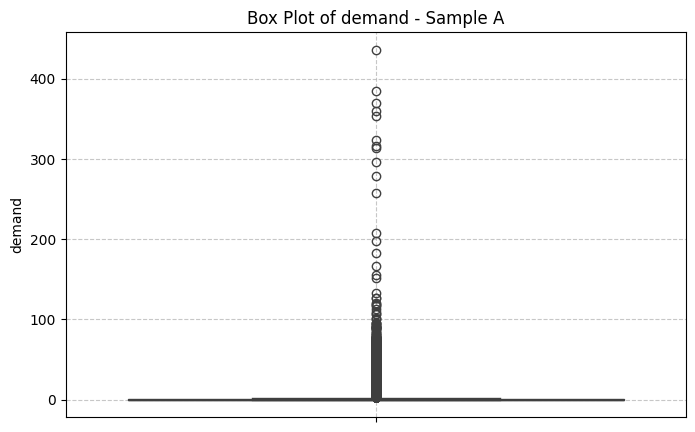

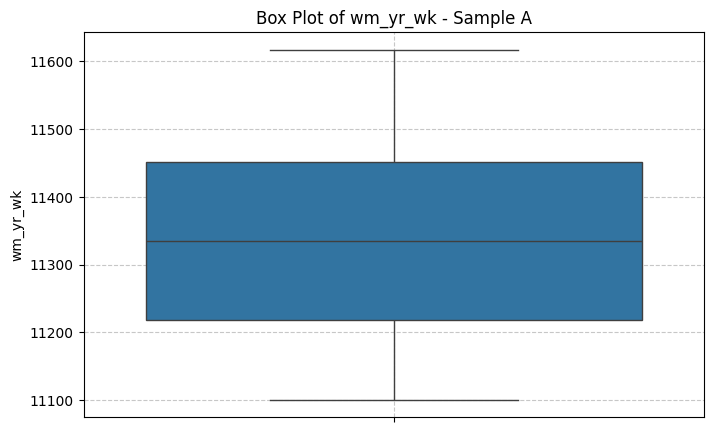

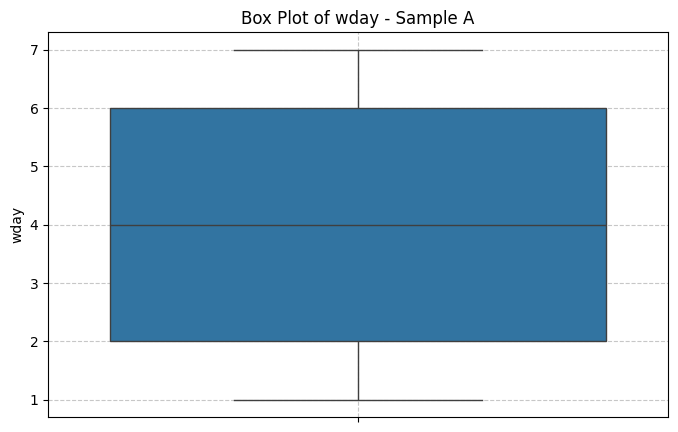

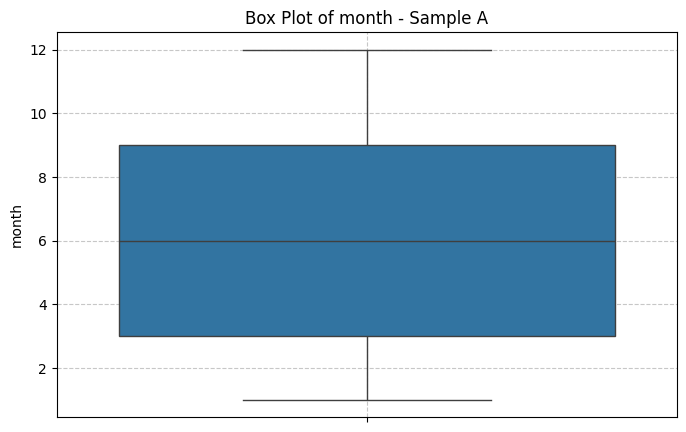

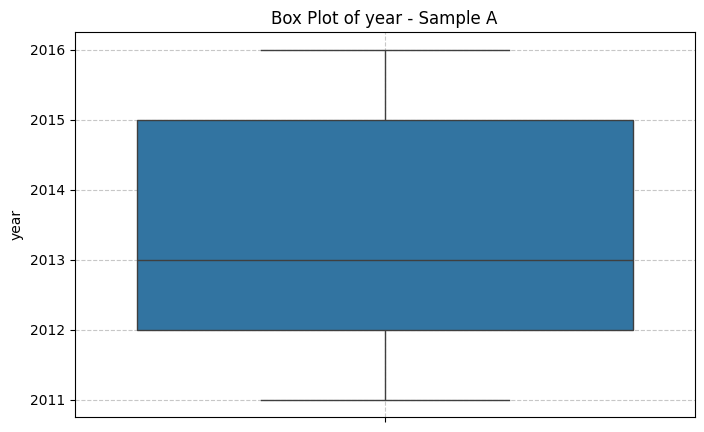

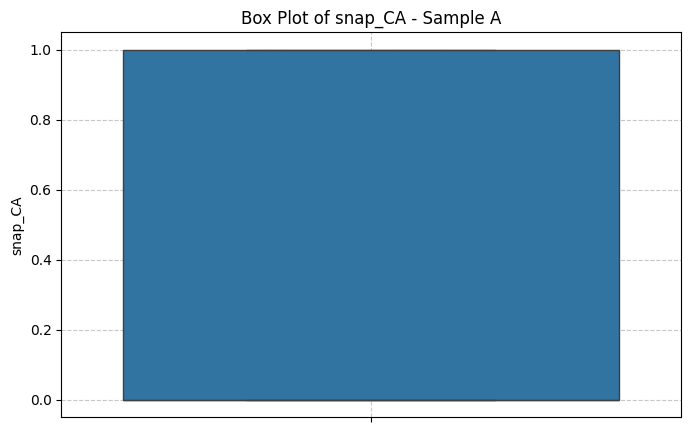

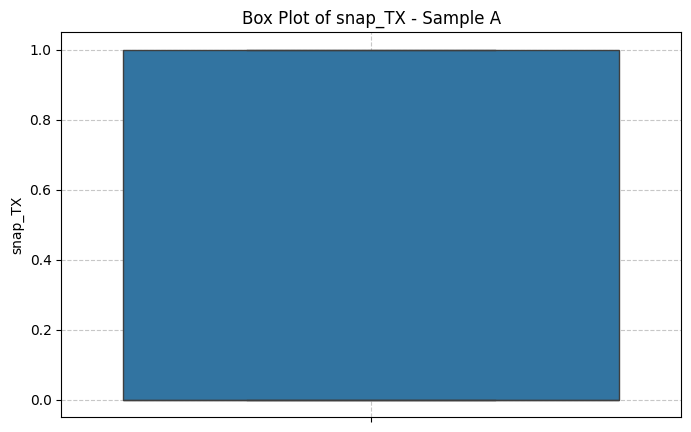

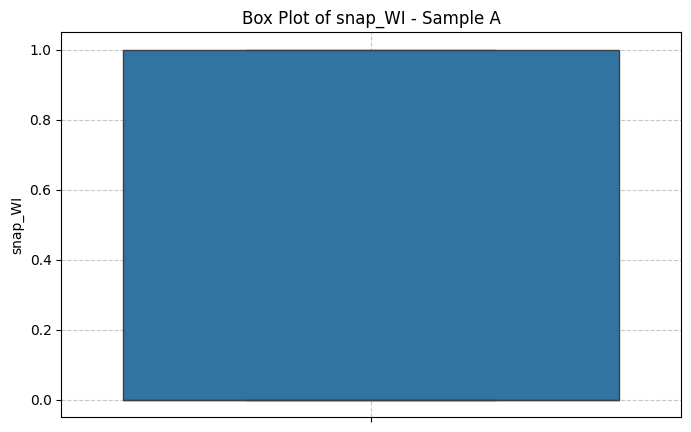

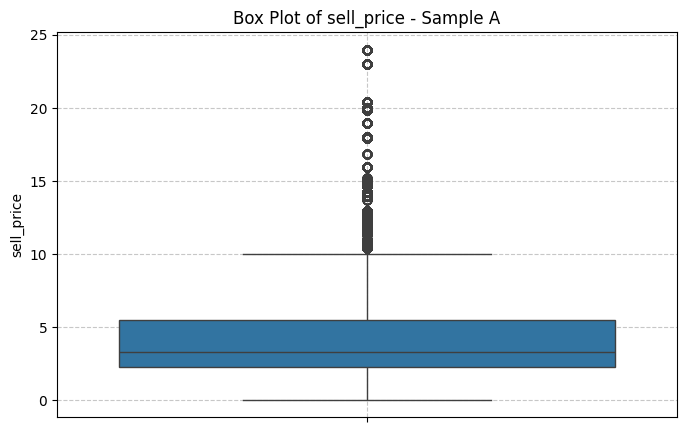

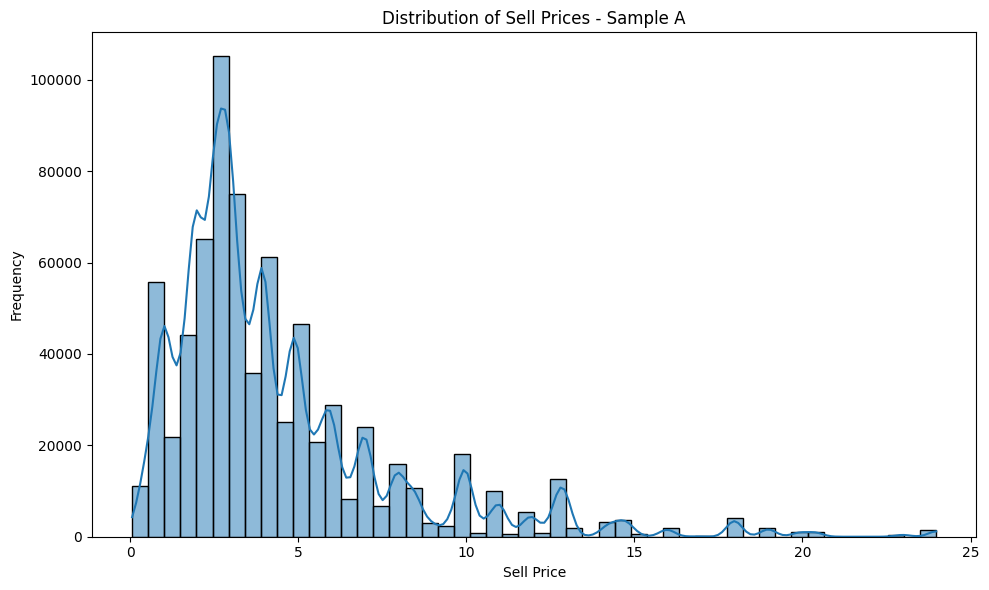

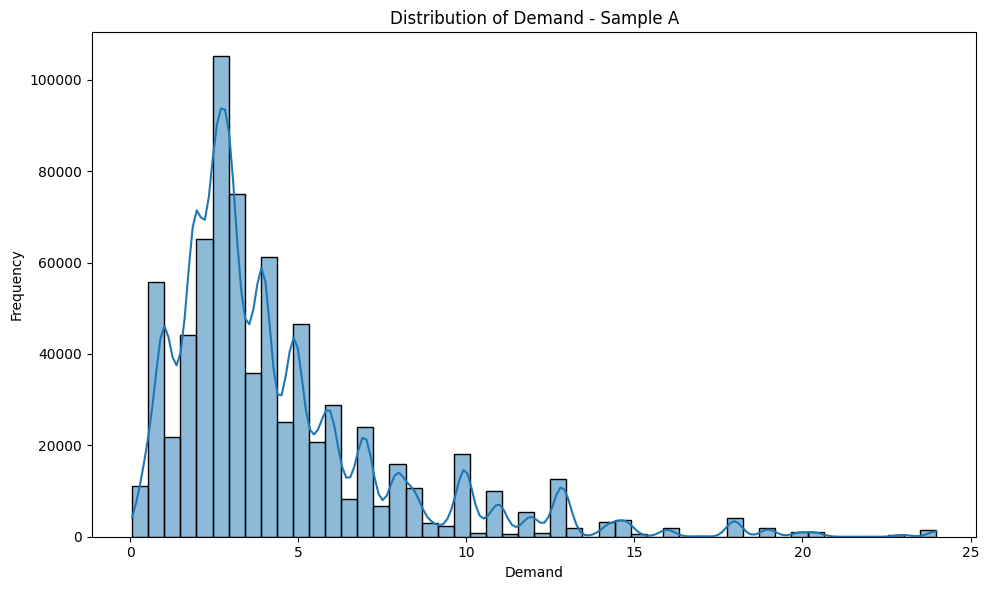


Correlation between Demand and Sell Price in Sample A: -0.12


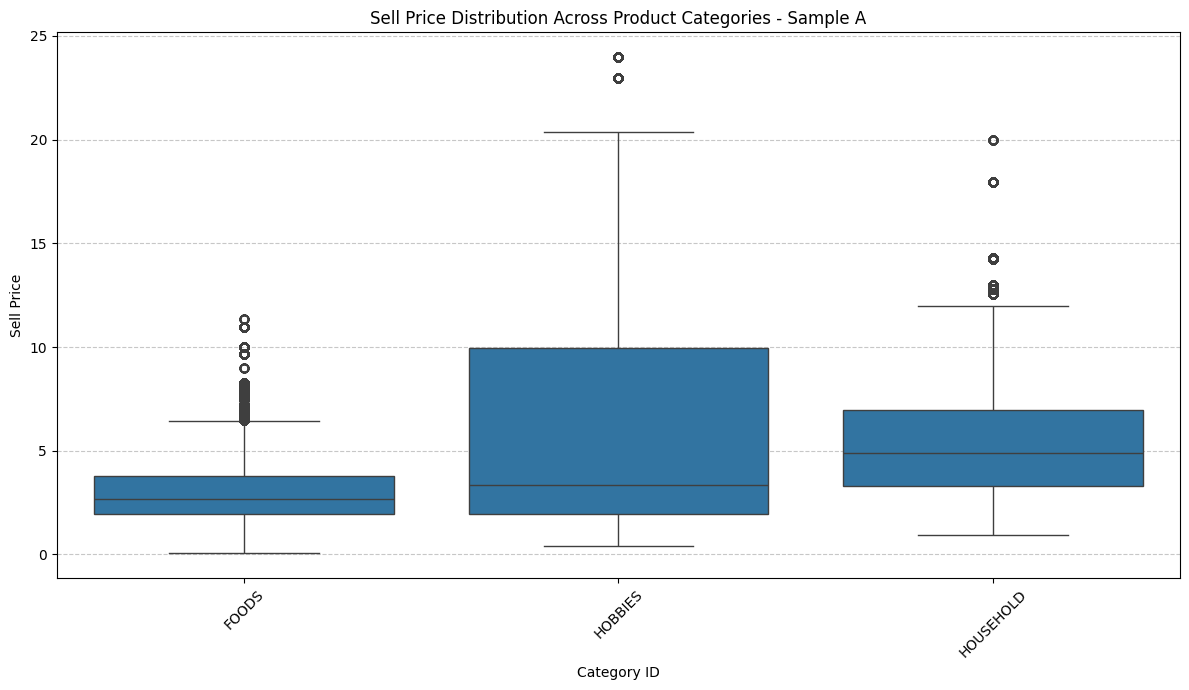

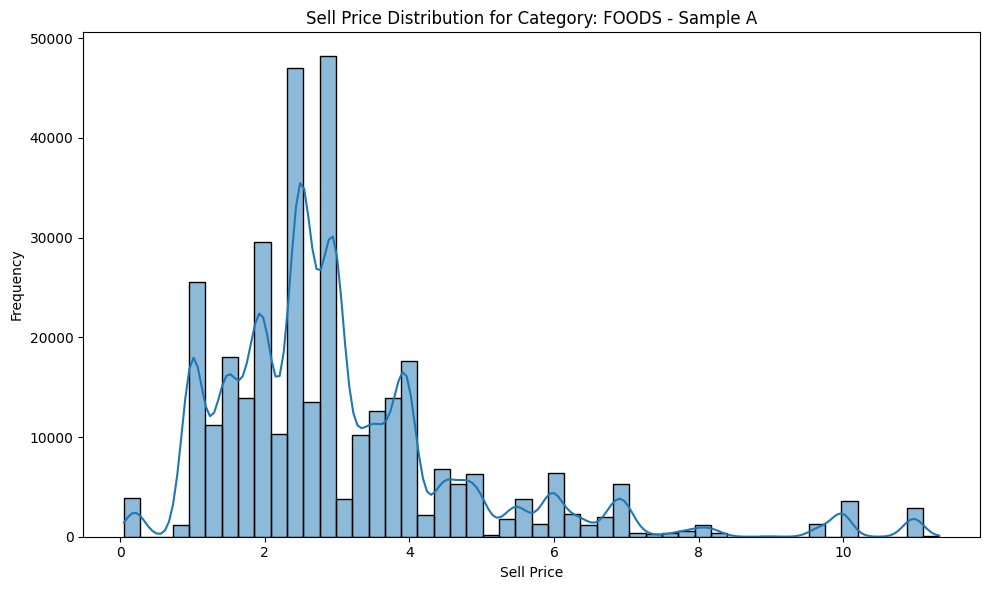

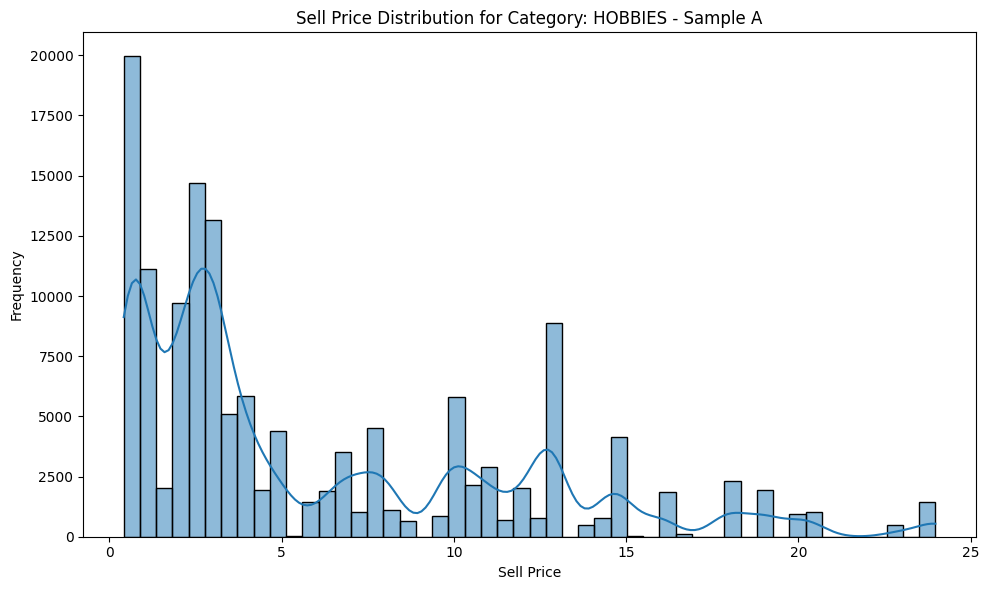

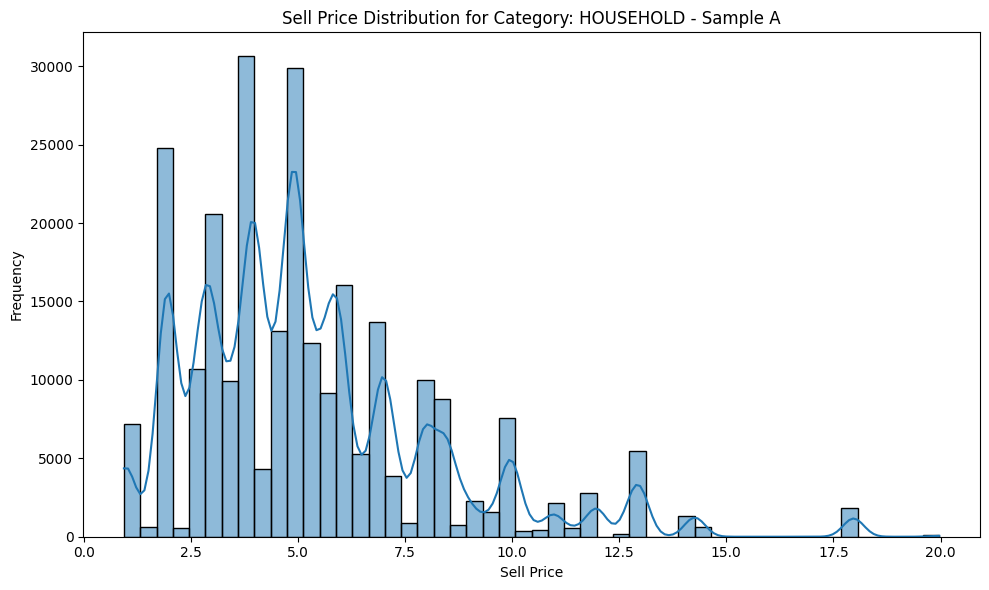

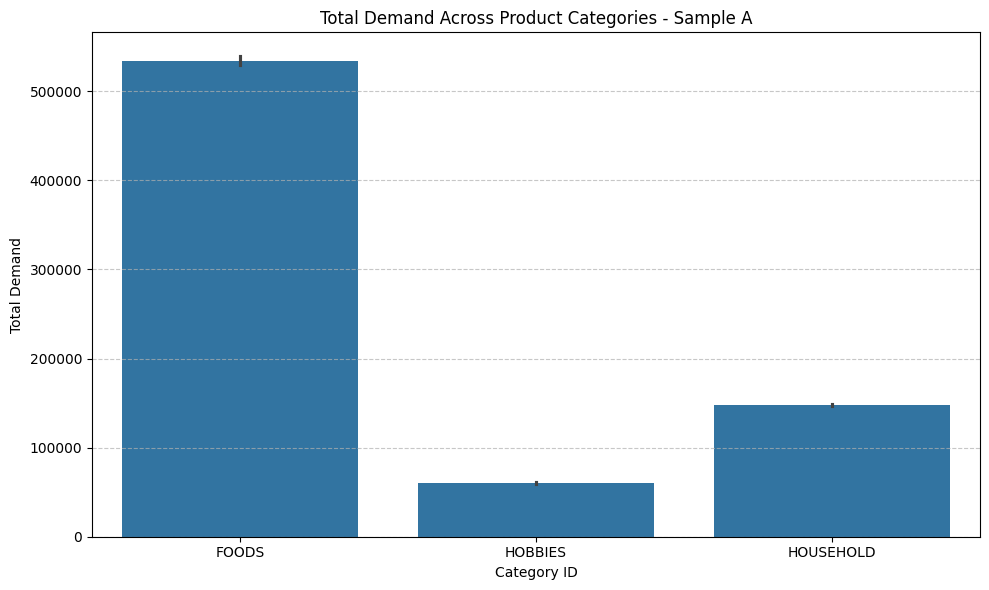

In [ ]:
# ---------------------------------------------------------
# Analyze Sample A, B, C
# ---------------------------------------------------------
analyze_sample(df_merged_sampled_A_cleaned, sample_name="Sample A", show_plots=True)



==================== Sample B ====================
--- Sample B Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            737580 non-null  object 
 1   item_id       737580 non-null  object 
 2   dept_id       737580 non-null  object 
 3   cat_id        737580 non-null  object 
 4   store_id      737580 non-null  object 
 5   state_id      737580 non-null  object 
 6   d             737580 non-null  object 
 7   demand        737580 non-null  int64  
 8   date          737580 non-null  object 
 9   wm_yr_wk      737580 non-null  int64  
 10  weekday       737580 non-null  object 
 11  wday          737580 non-null  int64  
 12  month         737580 non-null  int64  
 13  year          737580 non-null  int64  
 14  event_name_1  737580 non-null  object 
 15  event_type_1  737580 non-null  object 
 16  event_name_2  7375

None


--- Sample B Description ---


,demand,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price
count,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000
mean,1.173287,11343.166924,3.997424,6.334879,2013.249356,0.329727,0.329727,0.329727,4.604898
std,3.536197,152.859735,2.000644,3.439202,1.556975,0.470114,0.470114,0.470114,3.640895
min,0.000000,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,0.200000
25%,0.000000,11218.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000,2.280000
50%,0.000000,11335.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000,3.500000
75%,1.000000,11451.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000,5.940000
max,144.000000,11617.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,30.980000



--- Sample B Null Values ---


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Interquartile Range (IQR) for Numerical Columns in Sample B ---
demand: IQR = 1.00 (Q1=0.00, Q3=1.00)
wm_yr_wk: IQR = 233.00 (Q1=11218.00, Q3=11451.00)
wday: IQR = 4.00 (Q1=2.00, Q3=6.00)
month: IQR = 6.00 (Q1=3.00, Q3=9.00)
year: IQR = 3.00 (Q1=2012.00, Q3=2015.00)
snap_CA: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_TX: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_WI: IQR = 1.00 (Q1=0.00, Q3=1.00)
sell_price: IQR = 3.66 (Q1=2.28, Q3=5.94)


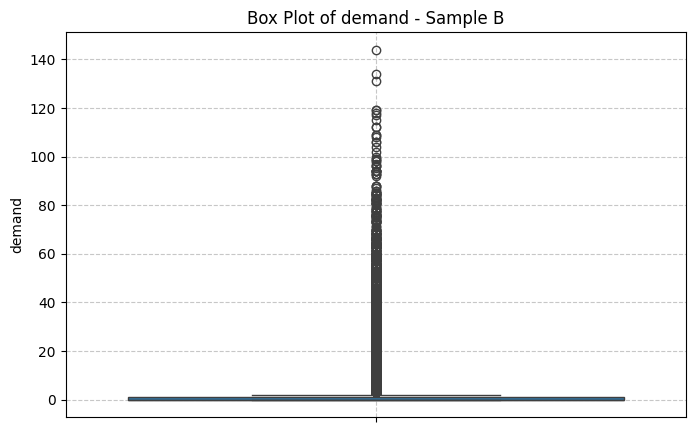

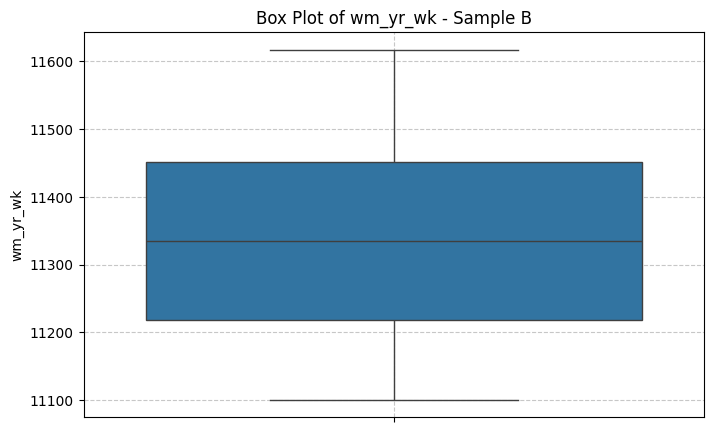

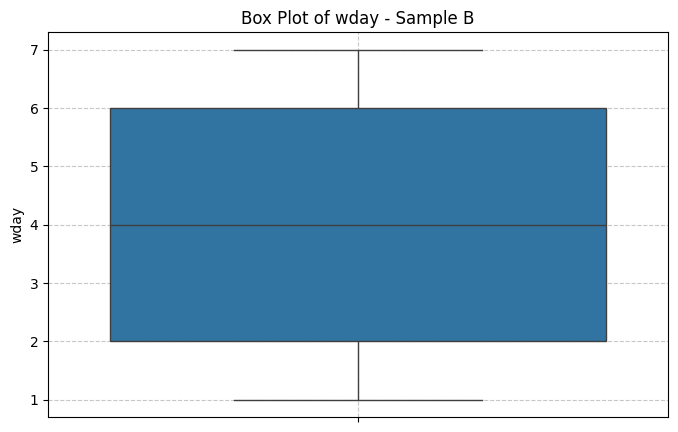

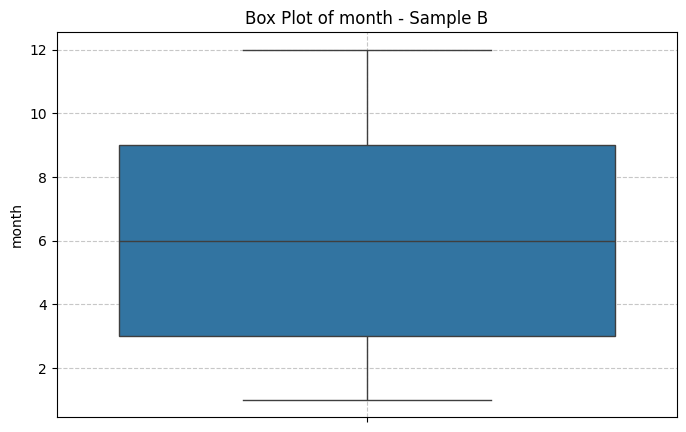

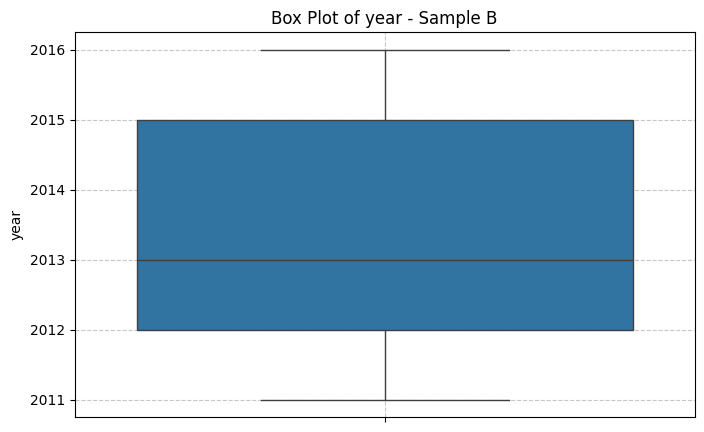

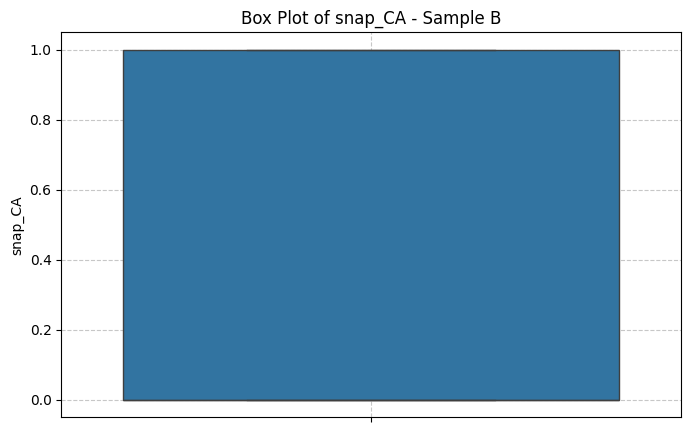

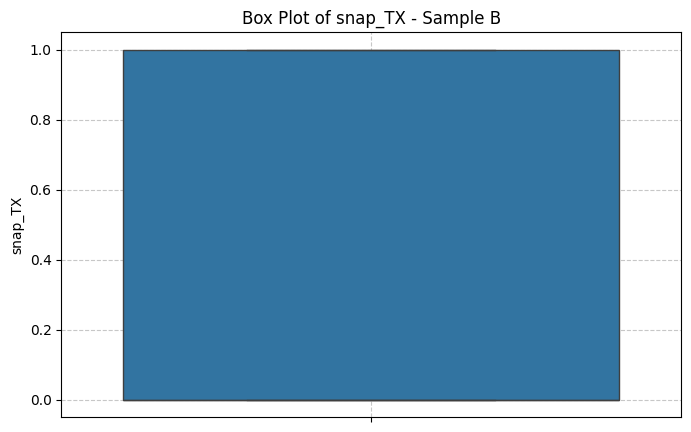

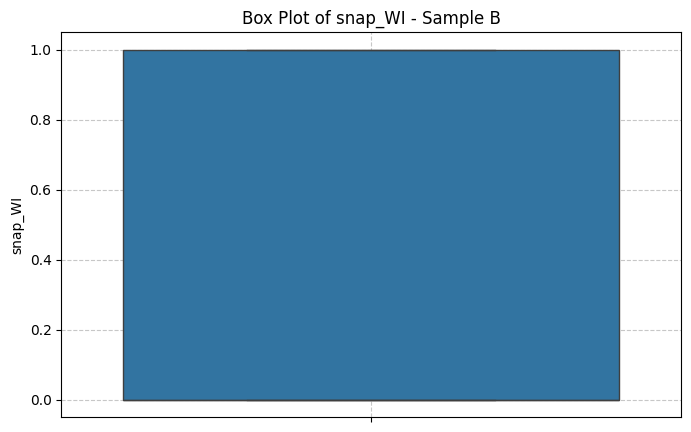

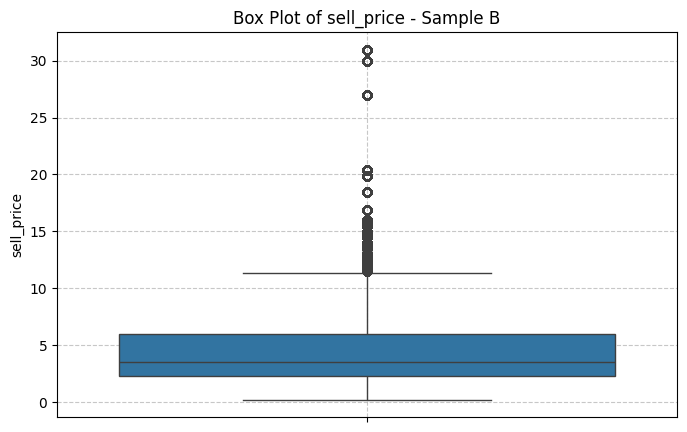

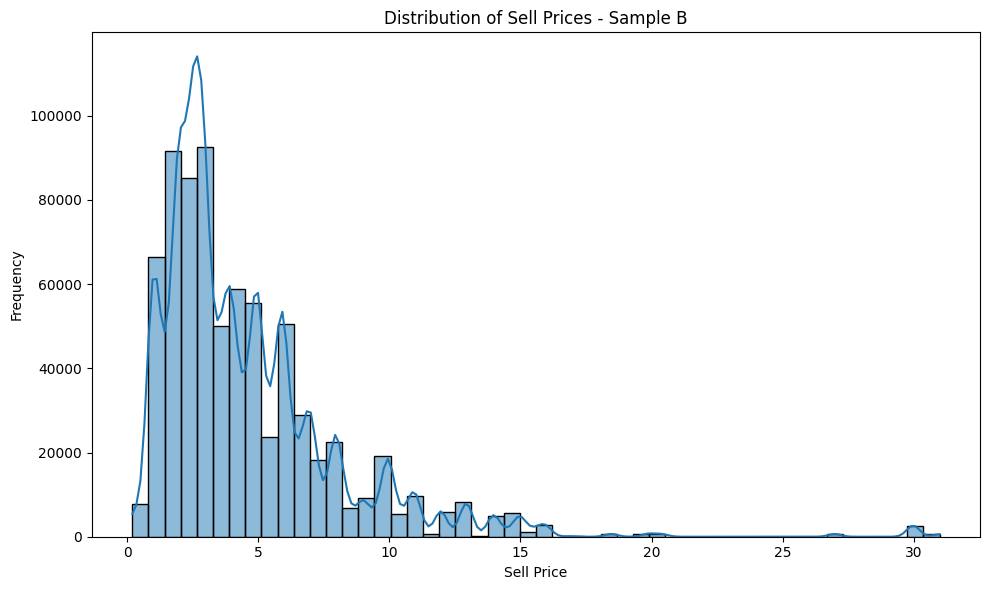

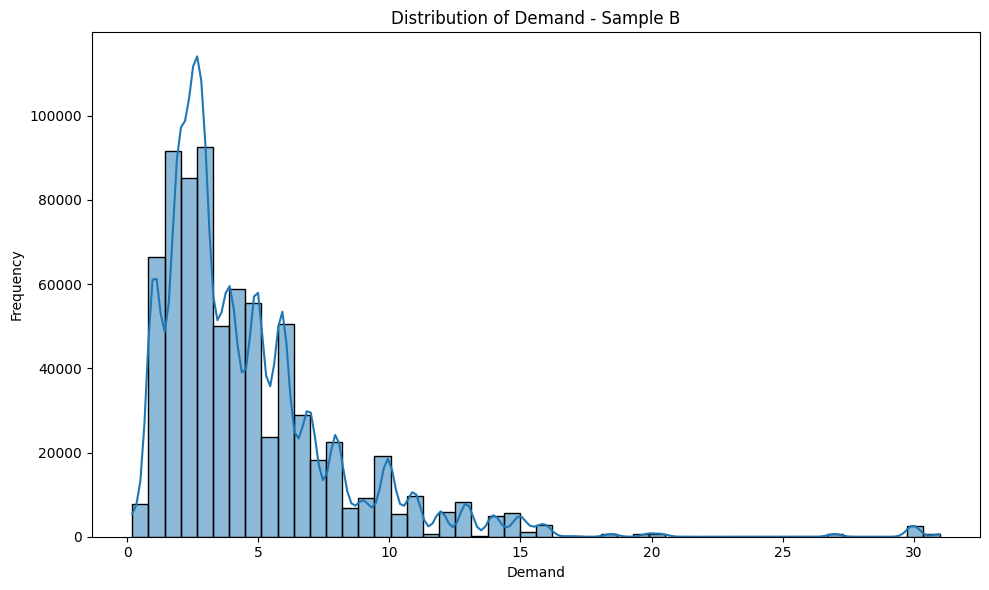


Correlation between Demand and Sell Price in Sample B: -0.14


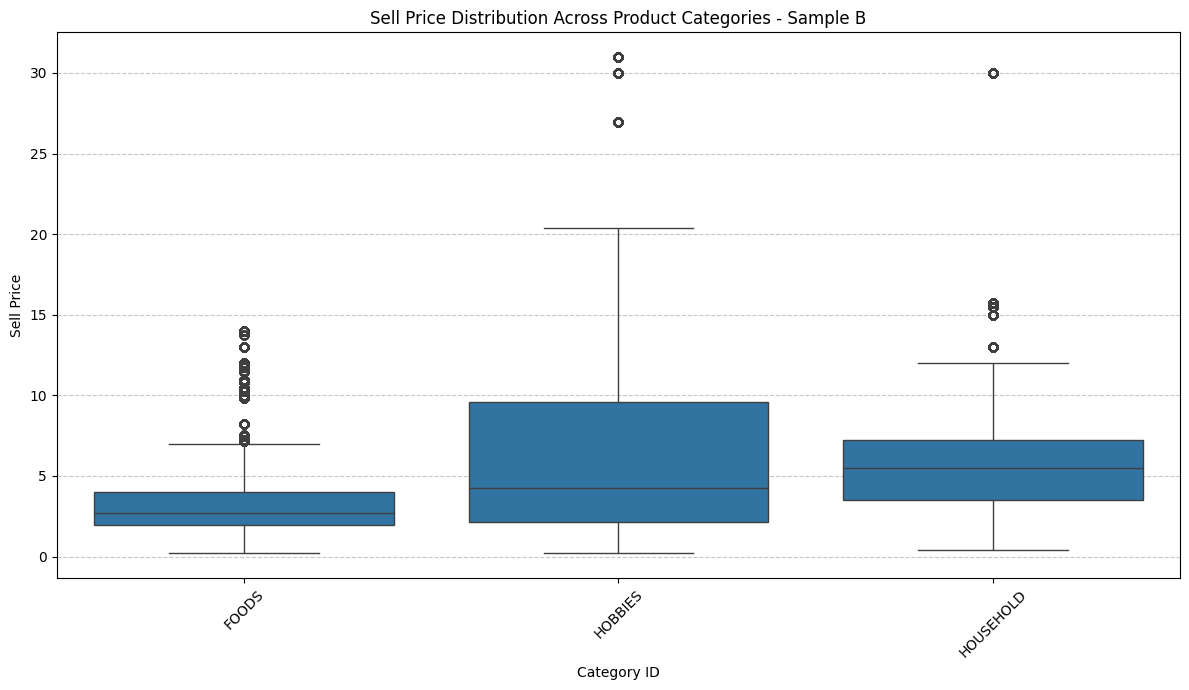

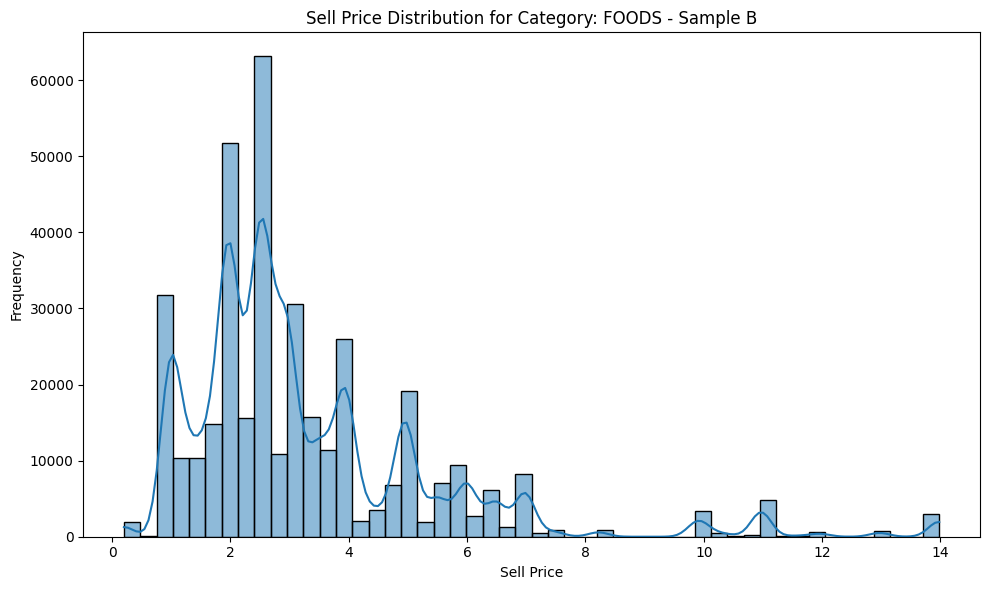

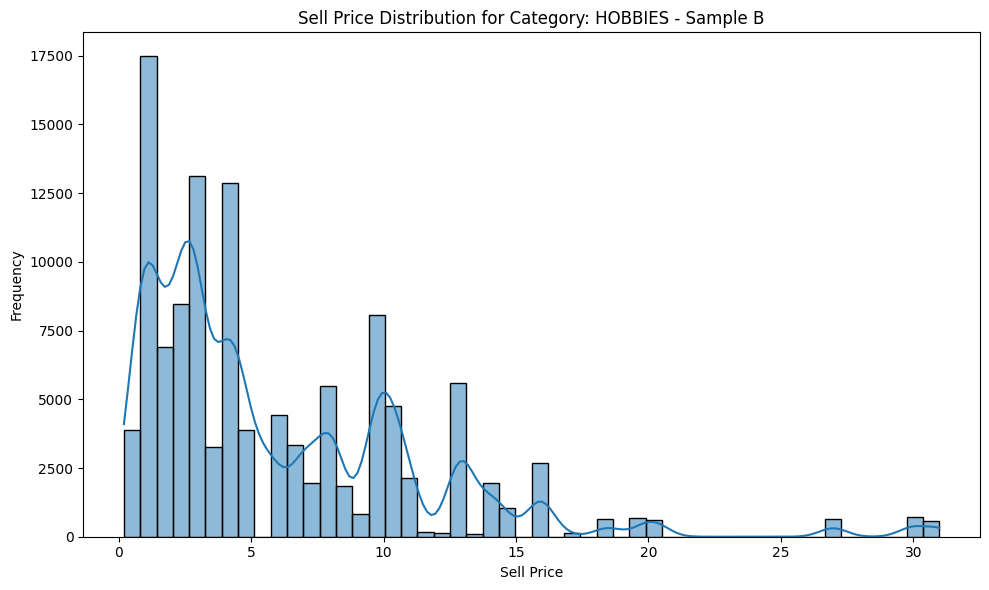

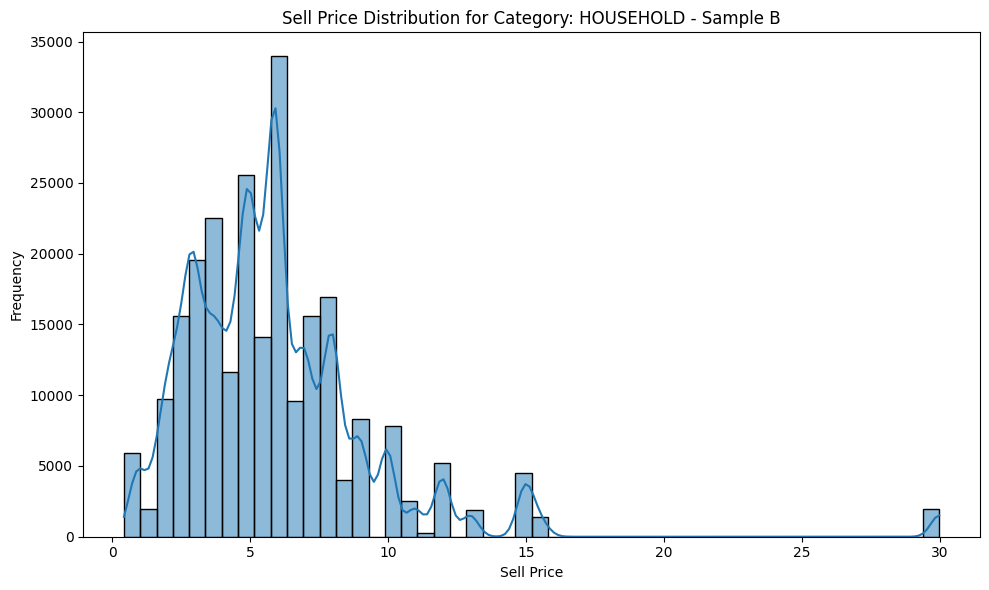

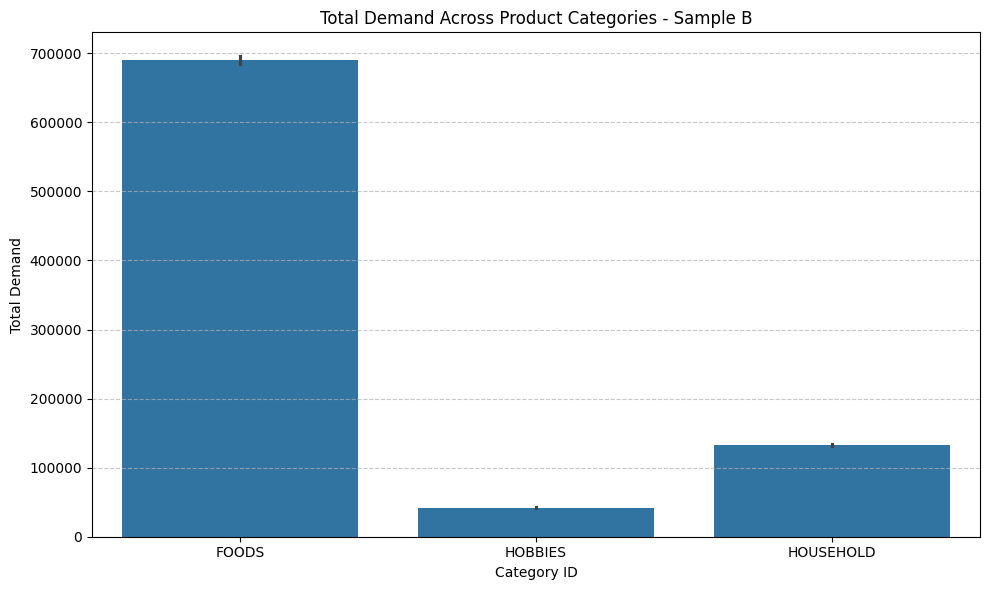

In [ ]:
analyze_sample(df_merged_sampled_B_cleaned, sample_name="Sample B", show_plots=True)


==================== Sample C ====================
--- Sample C Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            737580 non-null  object 
 1   item_id       737580 non-null  object 
 2   dept_id       737580 non-null  object 
 3   cat_id        737580 non-null  object 
 4   store_id      737580 non-null  object 
 5   state_id      737580 non-null  object 
 6   d             737580 non-null  object 
 7   demand        737580 non-null  int64  
 8   date          737580 non-null  object 
 9   wm_yr_wk      737580 non-null  int64  
 10  weekday       737580 non-null  object 
 11  wday          737580 non-null  int64  
 12  month         737580 non-null  int64  
 13  year          737580 non-null  int64  
 14  event_name_1  737580 non-null  object 
 15  event_type_1  737580 non-null  object 
 16  event_name_2  7375

None


--- Sample C Description ---


,demand,wm_yr_wk,wday,month,year,snap_CA,snap_TX,snap_WI,sell_price
count,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000,737580.000000
mean,1.048524,11343.166924,3.997424,6.334879,2013.249356,0.329727,0.329727,0.329727,4.558522
std,2.655785,152.859735,2.000644,3.439202,1.556975,0.470114,0.470114,0.470114,3.479317
min,0.000000,11101.000000,1.000000,1.000000,2011.000000,0.000000,0.000000,0.000000,0.200000
25%,0.000000,11218.000000,2.000000,3.000000,2012.000000,0.000000,0.000000,0.000000,2.280000
50%,0.000000,11335.000000,4.000000,6.000000,2013.000000,0.000000,0.000000,0.000000,3.480000
75%,1.000000,11451.000000,6.000000,9.000000,2015.000000,1.000000,1.000000,1.000000,5.940000
max,282.000000,11617.000000,7.000000,12.000000,2016.000000,1.000000,1.000000,1.000000,61.460000



--- Sample C Null Values ---


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Interquartile Range (IQR) for Numerical Columns in Sample C ---
demand: IQR = 1.00 (Q1=0.00, Q3=1.00)
wm_yr_wk: IQR = 233.00 (Q1=11218.00, Q3=11451.00)
wday: IQR = 4.00 (Q1=2.00, Q3=6.00)
month: IQR = 6.00 (Q1=3.00, Q3=9.00)
year: IQR = 3.00 (Q1=2012.00, Q3=2015.00)
snap_CA: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_TX: IQR = 1.00 (Q1=0.00, Q3=1.00)
snap_WI: IQR = 1.00 (Q1=0.00, Q3=1.00)
sell_price: IQR = 3.66 (Q1=2.28, Q3=5.94)


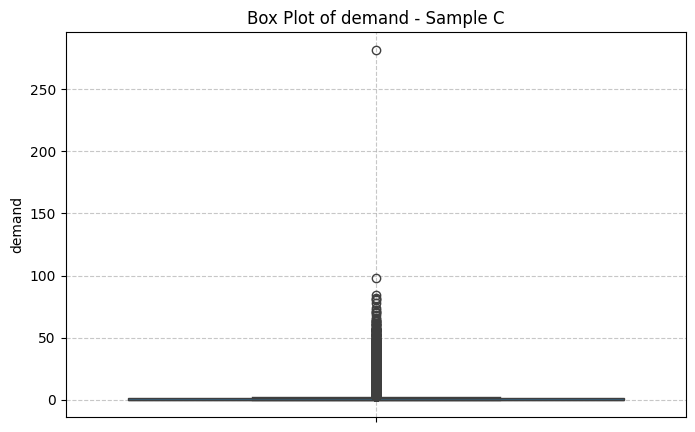

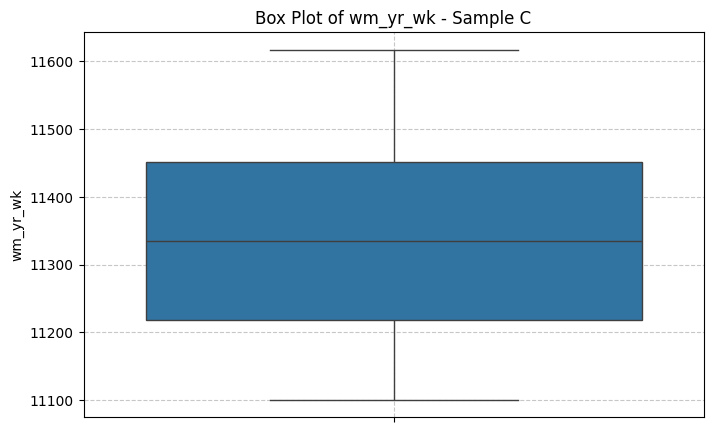

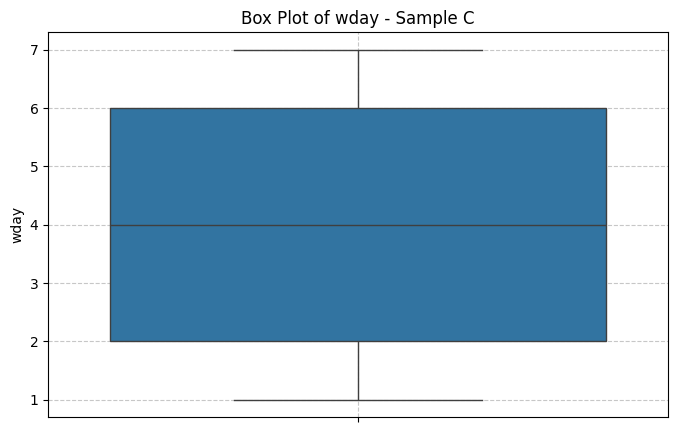

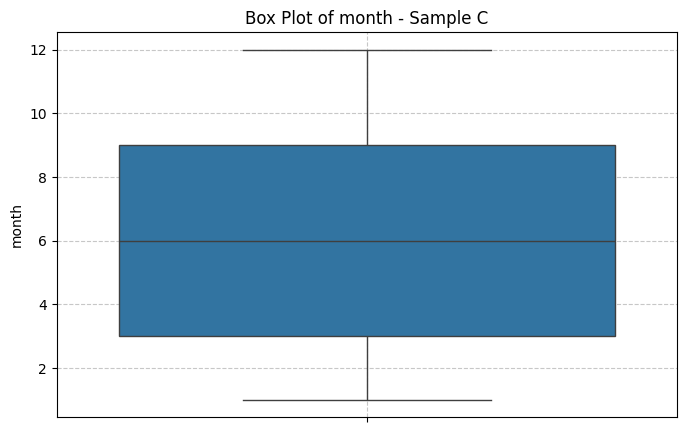

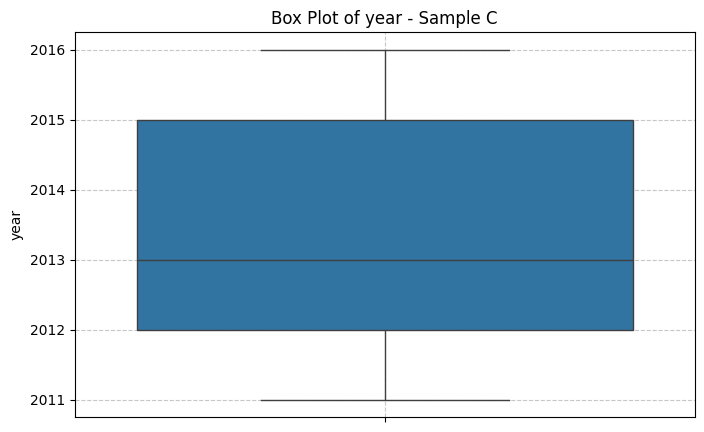

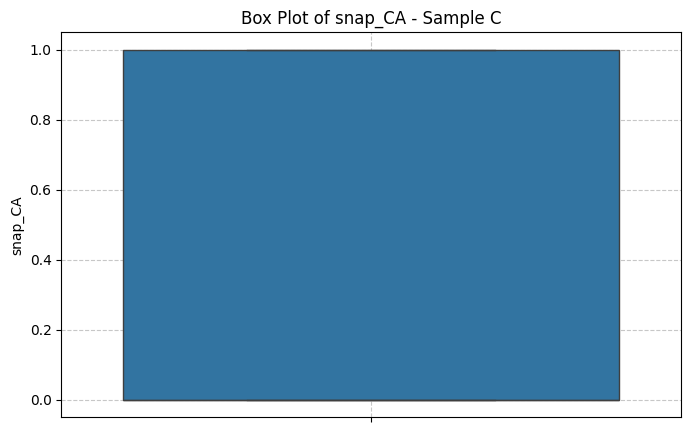

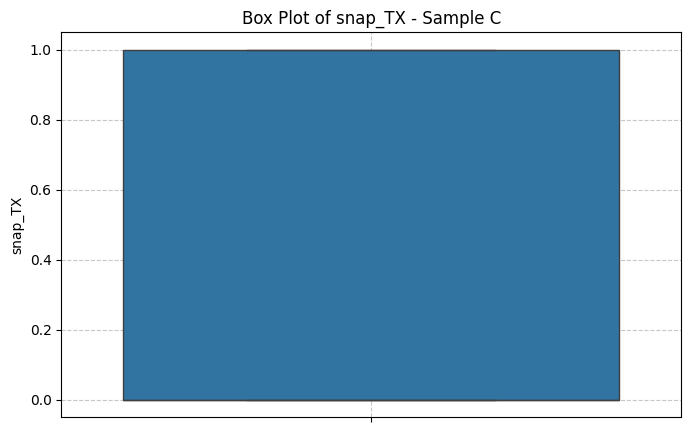

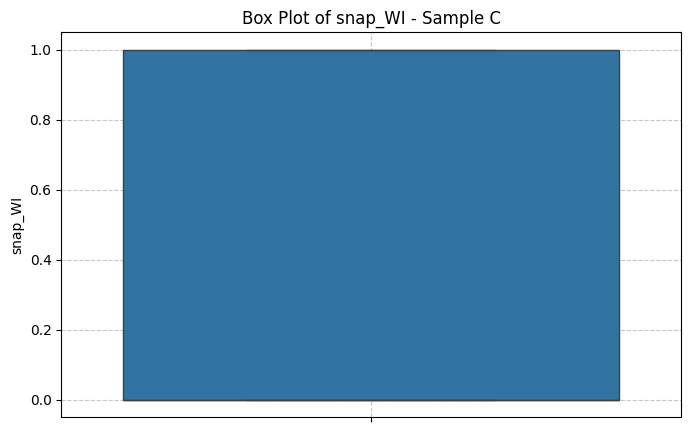

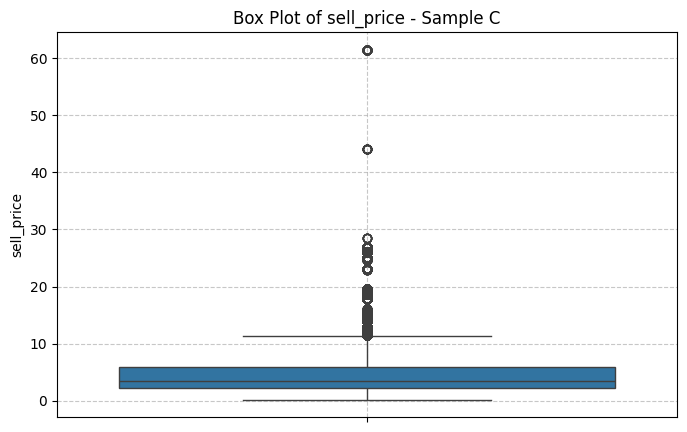

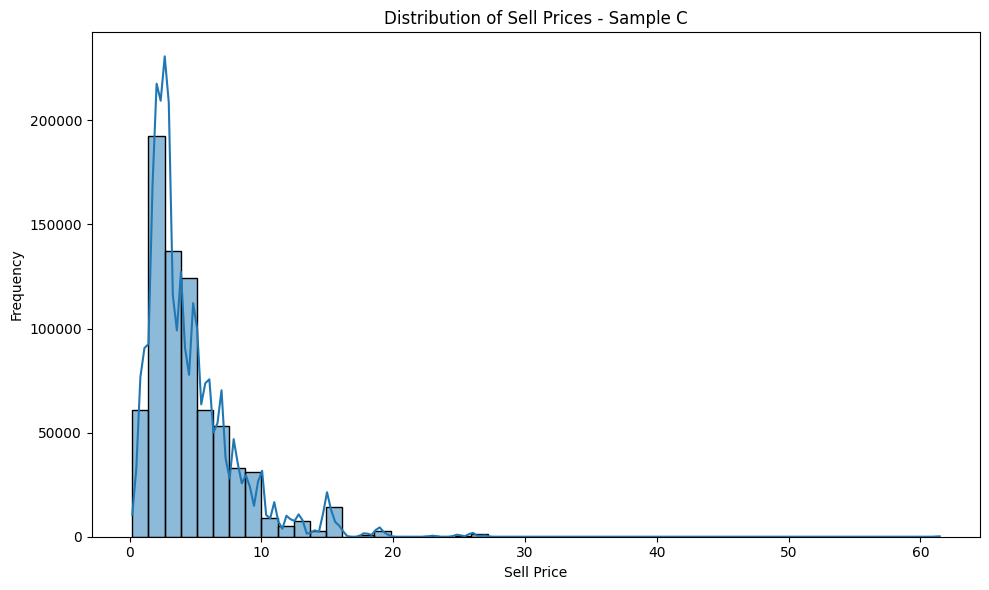

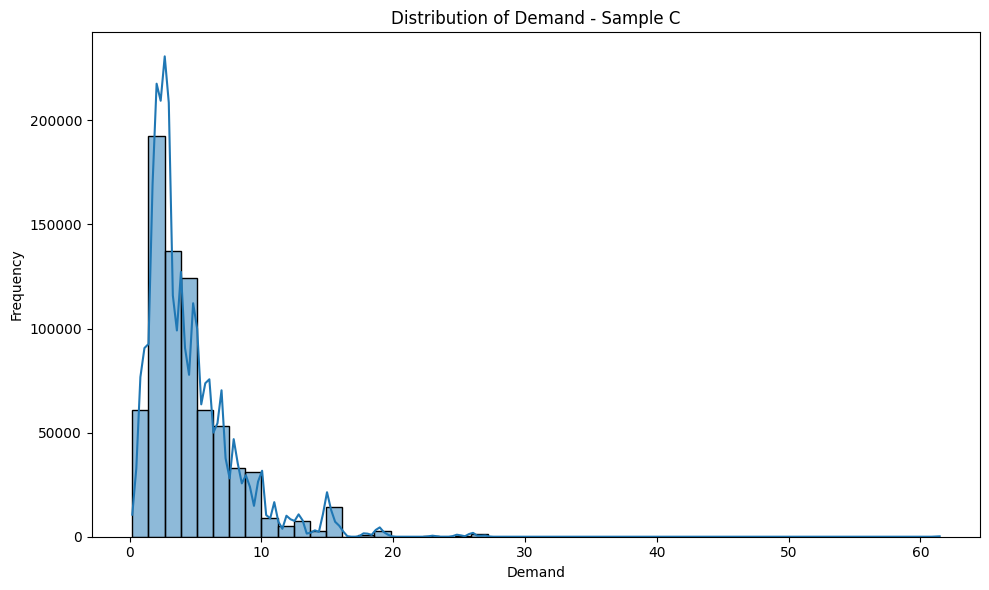


Correlation between Demand and Sell Price in Sample C: -0.13


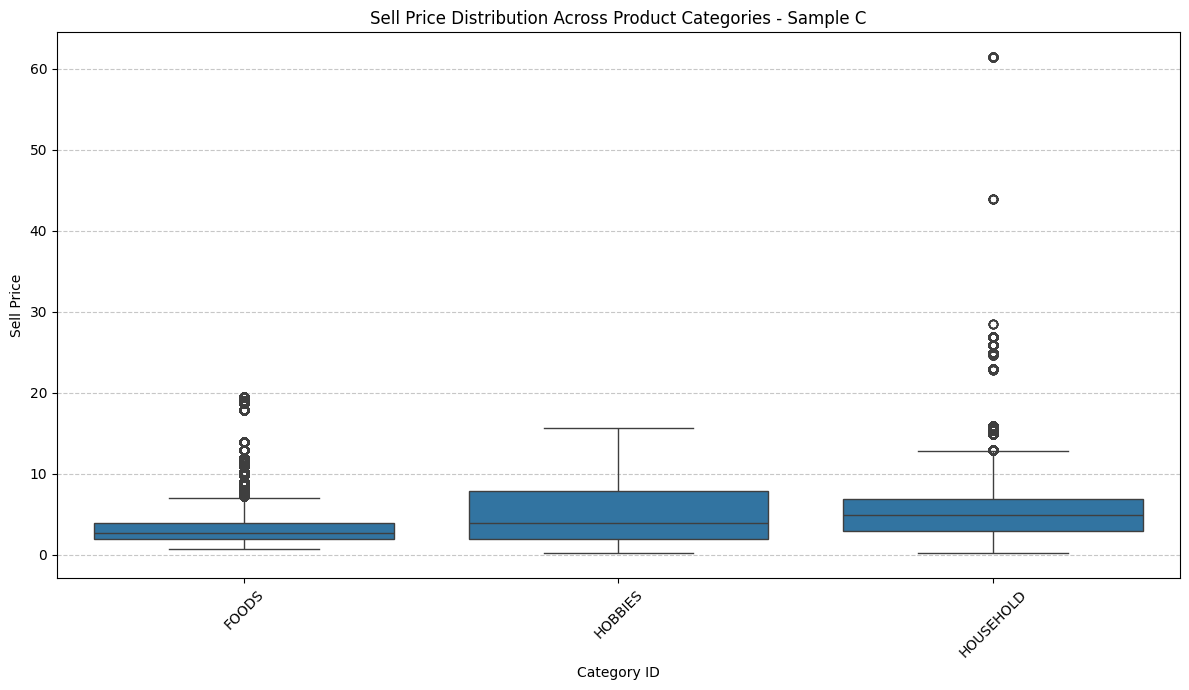

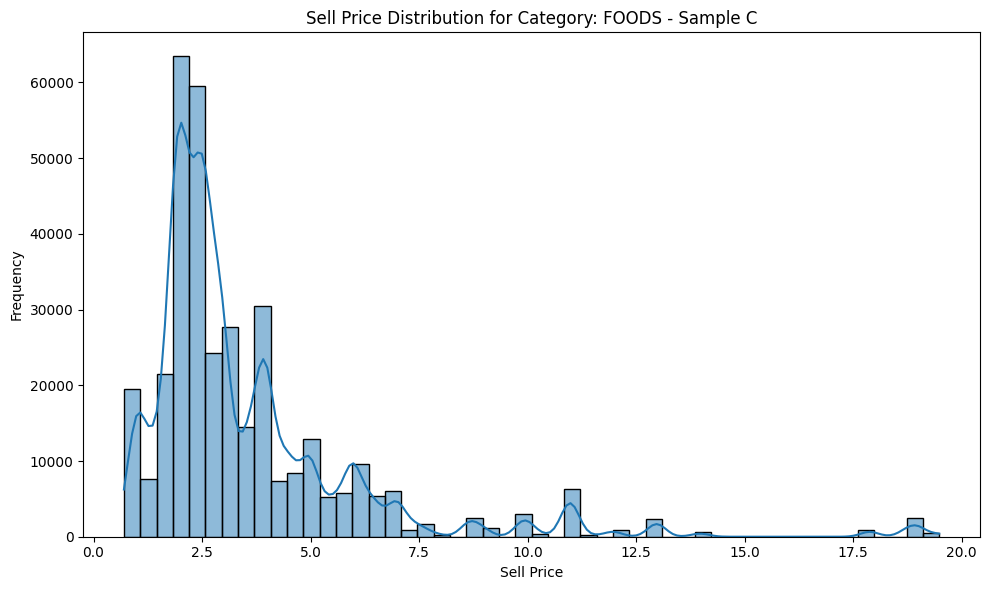

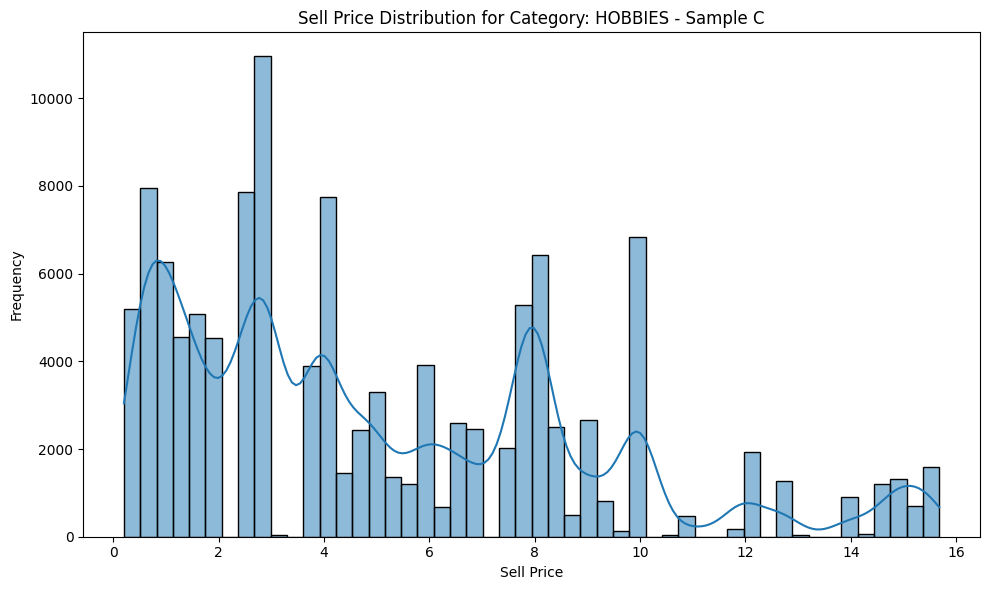

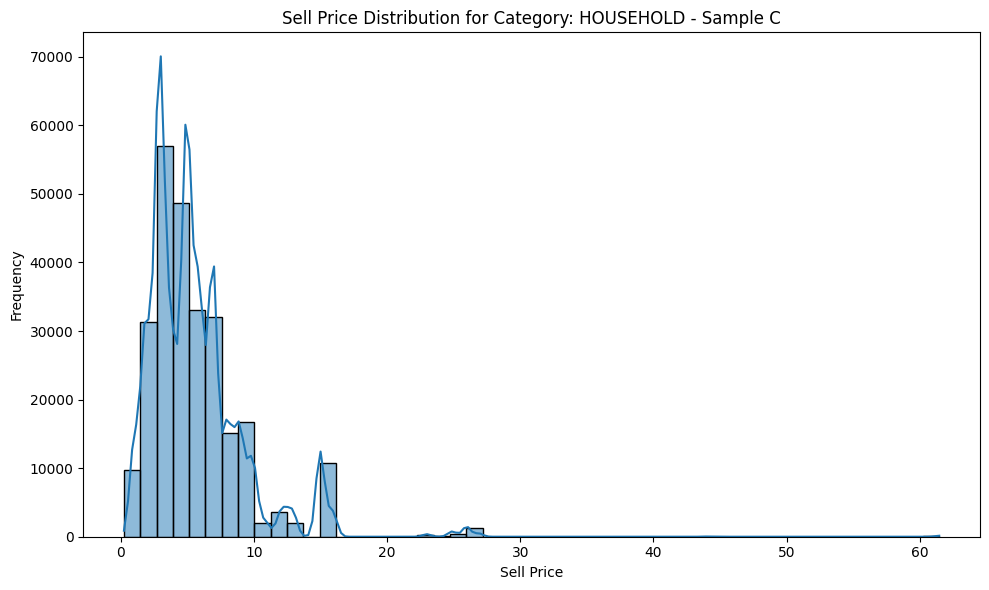

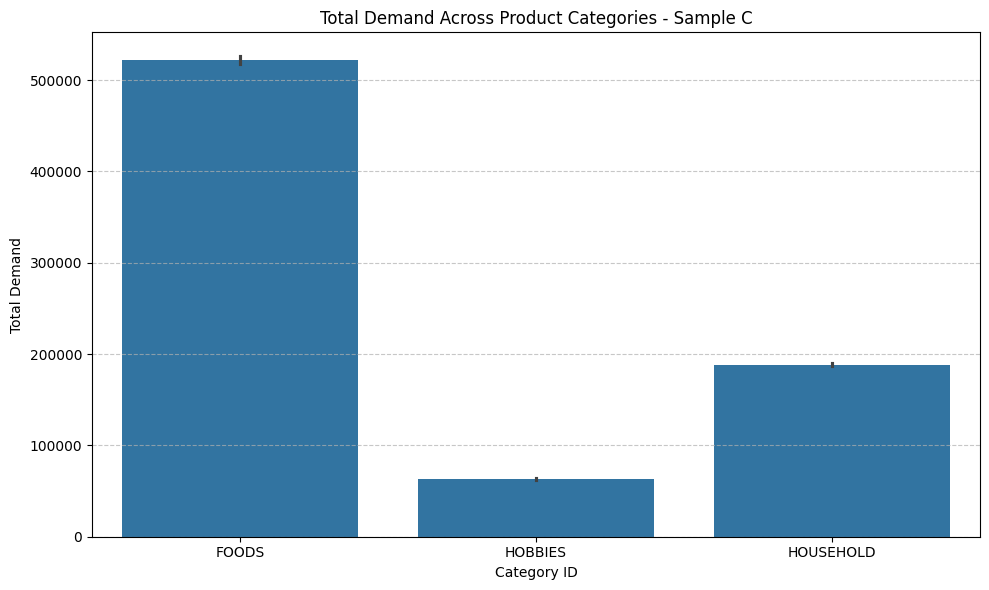

In [ ]:
analyze_sample(df_merged_sampled_C_cleaned, sample_name="Sample C", show_plots=True)

In [ ]:
# Merge macro data and save files
df_final_merged_A = merge_macro_and_save(
    df_sample=df_merged_sampled_A_cleaned,
    macro_df=macro_df,
    sample_name="Sample A",
    save_path='/content/drive/MyDrive/Graduation Project Data/df_final_merged_A_cleaned.csv'
)


==================== Merging Macroeconomic Data for Sample A ====================
Shape of the final merged DataFrame for Sample A: (737580, 31)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,sell_price,month_year,CAUR,CPIAUCSL,CPIUFDSL,FEDFUNDS_diff2,TXUR,UNRATE,UMCSENT_diff,WIUR
0,FOODS_1_012_TX_3_evaluation,FOODS_1_012,FOODS_1,FOODS,TX_3,TX,d_1,0,2011-01-29,11101,...,6.71,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
1,FOODS_1_012_TX_3_evaluation,FOODS_1_012,FOODS_1,FOODS,TX_3,TX,d_2,0,2011-01-30,11101,...,6.71,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
2,FOODS_1_012_TX_3_evaluation,FOODS_1_012,FOODS_1,FOODS,TX_3,TX,d_3,0,2011-01-31,11101,...,6.71,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
3,FOODS_1_012_TX_3_evaluation,FOODS_1_012,FOODS_1,FOODS,TX_3,TX,d_4,0,2011-02-01,11101,...,6.71,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7
4,FOODS_1_012_TX_3_evaluation,FOODS_1_012,FOODS_1,FOODS,TX_3,TX,d_5,0,2011-02-02,11101,...,6.71,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7



Checking null values in df_final_merged for Sample A:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Final merged info for Sample A ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              737580 non-null  object        
 1   item_id         737580 non-null  object        
 2   dept_id         737580 non-null  object        
 3   cat_id          737580 non-null  object        
 4   store_id        737580 non-null  object        
 5   state_id        737580 non-null  object        
 6   d               737580 non-null  object        
 7   demand          737580 non-null  int64         
 8   date            737580 non-null  datetime64[ns]
 9   wm_yr_wk        737580 non-null  int64         
 10  weekday         737580 non-null  object        
 11  wday            737580 non-null  int64         
 12  month           737580 non-null  int64         
 13  year            737580 non-null  int64         
 

None

Sample A saved successfully to: /content/drive/MyDrive/Graduation Project Data/df_final_merged_A_cleaned.csv


In [ ]:
df_final_merged_B = merge_macro_and_save(
    df_sample=df_merged_sampled_B_cleaned,
    macro_df=macro_df,
    sample_name="Sample B",
    save_path='/content/drive/MyDrive/Graduation Project Data/df_final_merged_B_cleaned.csv'
)


==================== Merging Macroeconomic Data for Sample B ====================
Shape of the final merged DataFrame for Sample B: (737580, 31)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,sell_price,month_year,CAUR,CPIAUCSL,CPIUFDSL,FEDFUNDS_diff2,TXUR,UNRATE,UMCSENT_diff,WIUR
0,FOODS_1_008_TX_3_evaluation,FOODS_1_008,FOODS_1,FOODS,TX_3,TX,d_1,0,2011-01-29,11101,...,3.28,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
1,FOODS_1_008_TX_3_evaluation,FOODS_1_008,FOODS_1,FOODS,TX_3,TX,d_2,0,2011-01-30,11101,...,3.28,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
2,FOODS_1_008_TX_3_evaluation,FOODS_1_008,FOODS_1,FOODS,TX_3,TX,d_3,0,2011-01-31,11101,...,3.28,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
3,FOODS_1_008_TX_3_evaluation,FOODS_1_008,FOODS_1,FOODS,TX_3,TX,d_4,0,2011-02-01,11101,...,3.28,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7
4,FOODS_1_008_TX_3_evaluation,FOODS_1_008,FOODS_1,FOODS,TX_3,TX,d_5,0,2011-02-02,11101,...,3.28,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7



Checking null values in df_final_merged for Sample B:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Final merged info for Sample B ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              737580 non-null  object        
 1   item_id         737580 non-null  object        
 2   dept_id         737580 non-null  object        
 3   cat_id          737580 non-null  object        
 4   store_id        737580 non-null  object        
 5   state_id        737580 non-null  object        
 6   d               737580 non-null  object        
 7   demand          737580 non-null  int64         
 8   date            737580 non-null  datetime64[ns]
 9   wm_yr_wk        737580 non-null  int64         
 10  weekday         737580 non-null  object        
 11  wday            737580 non-null  int64         
 12  month           737580 non-null  int64         
 13  year            737580 non-null  int64         
 

None

Sample B saved successfully to: /content/drive/MyDrive/Graduation Project Data/df_final_merged_B_cleaned.csv


In [ ]:
df_final_merged_C = merge_macro_and_save(
    df_sample=df_merged_sampled_C_cleaned,
    macro_df=macro_df,
    sample_name="Sample C",
    save_path='/content/drive/MyDrive/Graduation Project Data/df_final_merged_C_cleaned.csv'
)


==================== Merging Macroeconomic Data for Sample C ====================
Shape of the final merged DataFrame for Sample C: (737580, 31)


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,sell_price,month_year,CAUR,CPIAUCSL,CPIUFDSL,FEDFUNDS_diff2,TXUR,UNRATE,UMCSENT_diff,WIUR
0,FOODS_1_001_WI_1_evaluation,FOODS_1_001,FOODS_1,FOODS,WI_1,WI,d_1,0,2011-01-29,11101,...,2.0,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
1,FOODS_1_001_WI_1_evaluation,FOODS_1_001,FOODS_1,FOODS,WI_1,WI,d_2,2,2011-01-30,11101,...,2.0,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
2,FOODS_1_001_WI_1_evaluation,FOODS_1_001,FOODS_1,FOODS,WI_1,WI,d_3,0,2011-01-31,11101,...,2.0,2011-01,12.1,221.187,222.469,2.775558e-17,8.2,9.1,-0.3,7.8
3,FOODS_1_001_WI_1_evaluation,FOODS_1_001,FOODS_1,FOODS,WI_1,WI,d_4,1,2011-02-01,11101,...,2.0,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7
4,FOODS_1_001_WI_1_evaluation,FOODS_1_001,FOODS_1,FOODS,WI_1,WI,d_5,0,2011-02-02,11101,...,2.0,2011-02,12.0,221.898,223.504,-2.775558e-17,8.2,9.0,3.3,7.7



Checking null values in df_final_merged for Sample C:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



--- Final merged info for Sample C ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 31 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   id              737580 non-null  object        
 1   item_id         737580 non-null  object        
 2   dept_id         737580 non-null  object        
 3   cat_id          737580 non-null  object        
 4   store_id        737580 non-null  object        
 5   state_id        737580 non-null  object        
 6   d               737580 non-null  object        
 7   demand          737580 non-null  int64         
 8   date            737580 non-null  datetime64[ns]
 9   wm_yr_wk        737580 non-null  int64         
 10  weekday         737580 non-null  object        
 11  wday            737580 non-null  int64         
 12  month           737580 non-null  int64         
 13  year            737580 non-null  int64         
 

None

Sample C saved successfully to: /content/drive/MyDrive/Graduation Project Data/df_final_merged_C_cleaned.csv


# **ANOVA Statistical Test**
    ANOVA assumes:

    Independence of observations ❌ (broken after rolling/lag)
    Normality (or approximate)
    Homogeneity of variance

In [ ]:
!pip install scikit-posthocs

In [ ]:
df_A_agg = df_final_merged_A.groupby('date')['demand'].sum().reset_index()
df_B_agg = df_final_merged_B.groupby('date')['demand'].sum().reset_index()
df_C_agg = df_final_merged_C.groupby('date')['demand'].sum().reset_index()
# Extract the aggregated 'demand' column from each aggregated dataframe
demand_A_agg = df_A_agg['demand']
demand_B_agg = df_B_agg['demand']
demand_C_agg = df_C_agg['demand']

## ANOVA Test

In [ ]:


# Perform Kruskal-Wallis H-test on the aggregated demand
statistic_kruskal, p_value_kruskal = kruskal(demand_A_agg, demand_B_agg, demand_C_agg)

print(f"Kruskal-Wallis H-statistic for Aggregated Demand: {statistic_kruskal:.4f}")
print(f"Kruskal-Wallis p-value for Aggregated Demand: {p_value_kruskal:.4f}")

if p_value_kruskal < 0.05:
    print("Conclusion: There is a statistically significant difference in the medians of the aggregated demand data across the three samples (p < 0.05).")
else:
    print("Conclusion: There is no statistically significant difference in the medians of the aggregated demand data across the three samples (p >= 0.05).")

Kruskal-Wallis H-statistic for Aggregated Demand: 431.7891
Kruskal-Wallis p-value for Aggregated Demand: 0.0000
Conclusion: There is a statistically significant difference in the medians of the aggregated demand data across the three samples (p < 0.05).


In [ ]:
import scikit_posthocs as sp

# Combine all aggregated demand data into a single list or array for scikit_posthocs
all_aggregated_demand = [demand_A_agg, demand_B_agg, demand_C_agg]

# Perform Dunn's test
dunn_results = sp.posthoc_dunn(all_aggregated_demand, p_adjust='bonferroni') # Bonferroni correction for multiple comparisons

print("Dunn's Test Results (Bonferroni corrected p-values):")
# For better readability, label the rows/columns if possible. Let's assume indices 0, 1, 2 correspond to A, B, C.
dunn_results.columns = ['Sample_A', 'Sample_B', 'Sample_C']
dunn_results.index = ['Sample_A', 'Sample_B', 'Sample_C']
display(dunn_results)

print("\nInterpretation:")
print("Each cell shows the Bonferroni-corrected p-value for the pairwise comparison of the medians of the aggregated demand samples. A p-value less than 0.05 indicates a statistically significant difference between the two samples.")

Dunn's Test Results (Bonferroni corrected p-values):


,Sample_A,Sample_B,Sample_C
Sample_A,1.000000e+00,1.439332e-89,7.759896e-08
Sample_B,1.439332e-89,1.000000e+00,1.652092e-47
Sample_C,7.759896e-08,1.652092e-47,1.000000e+00



Interpretation:
Each cell shows the Bonferroni-corrected p-value for the pairwise comparison of the medians of the aggregated demand samples. A p-value less than 0.05 indicates a statistically significant difference between the two samples.




# **Levene's Test**

In [ ]:

# Perform Levene's test on the aggregated demand
statistic_agg, p_value_agg = levene(demand_A_agg, demand_B_agg, demand_C_agg)

print(f"Levene's Test Statistic for Aggregated Demand: {statistic_agg:.4f}")
print(f"Levene's Test p-value for Aggregated Demand: {p_value_agg:.4f}")

if p_value_agg < 0.05:
    print("Conclusion: The variances of the aggregated demand data across the three samples are significantly different (p < 0.05).")
else:
    print("Conclusion: There is no significant difference in the variances of the aggregated demand data across the three samples (p >= 0.05).")

Levene's Test Statistic for Aggregated Demand: 12.6482
Levene's Test p-value for Aggregated Demand: 0.0000
Conclusion: The variances of the aggregated demand data across the three samples are significantly different (p < 0.05).


#  **Feature Engneering**

In [ ]:

# =========================================================
# Function 1: Feature engineering for one sample
# =========================================================
def feature_engineering_sample(df_final_merged, sample_name="Sample"):
    """
    Create lag and rolling features for demand and sell_price
    for one final merged dataframe.

    Parameters
    ----------
    df_final_merged : pd.DataFrame
        Input dataframe after macroeconomic merge
    sample_name : str
        Name of the sample

    Returns
    -------
    df_fe : pd.DataFrame
        Dataframe with engineered features
    """

    print(f"\n==================== Feature Engineering: {sample_name} ====================")

    # Make copy to avoid modifying original dataframe directly
    df_fe = df_final_merged.copy()

    # Ensure date is datetime
    df_fe['date'] = pd.to_datetime(df_fe['date'])

    # Sort before lag/rolling operations
    df_fe = df_fe.sort_values(by=['item_id', 'store_id', 'cat_id', 'dept_id', 'date']).reset_index(drop=True)

    # -----------------------------------------------------
    # Demand lag features
    # -----------------------------------------------------
    demand_group = ['item_id', 'store_id', 'cat_id', 'dept_id']

    df_fe['demand_lag_7'] = df_fe.groupby(demand_group)['demand'].transform(lambda x: x.shift(7))
    df_fe['demand_lag_14'] = df_fe.groupby(demand_group)['demand'].transform(lambda x: x.shift(14))
    df_fe['demand_lag_28'] = df_fe.groupby(demand_group)['demand'].transform(lambda x: x.shift(28))

    # -----------------------------------------------------
    # Demand rolling features
    # -----------------------------------------------------
    df_fe['demand_rolling_mean_7'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    df_fe['demand_rolling_std_7'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=7, min_periods=1).std()
    )

    df_fe['demand_rolling_mean_14'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=14, min_periods=1).mean()
    )
    df_fe['demand_rolling_std_14'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=14, min_periods=1).std()
    )

    df_fe['demand_rolling_mean_28'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=28, min_periods=1).mean()
    )
    df_fe['demand_rolling_std_28'] = df_fe.groupby(demand_group)['demand'].transform(
        lambda x: x.rolling(window=28, min_periods=1).std()
    )

    # -----------------------------------------------------
    # Price lag features
    # -----------------------------------------------------
    price_group = ['item_id', 'store_id']

    df_fe['price_lag_1'] = df_fe.groupby(price_group)['sell_price'].transform(lambda x: x.shift(1))
    df_fe['price_lag_7'] = df_fe.groupby(price_group)['sell_price'].transform(lambda x: x.shift(7))

    # -----------------------------------------------------
    # Price rolling features
    # -----------------------------------------------------
    df_fe['price_rolling_mean_7'] = df_fe.groupby(price_group)['sell_price'].transform(
        lambda x: x.rolling(window=7, min_periods=1).mean()
    )
    df_fe['price_rolling_std_7'] = df_fe.groupby(price_group)['sell_price'].transform(
        lambda x: x.rolling(window=7, min_periods=1).std()
    )

    df_fe['price_rolling_mean_28'] = df_fe.groupby(price_group)['sell_price'].transform(
        lambda x: x.rolling(window=28, min_periods=1).mean()
    )
    df_fe['price_rolling_std_28'] = df_fe.groupby(price_group)['sell_price'].transform(
        lambda x: x.rolling(window=28, min_periods=1).std()
    )

    # -----------------------------------------------------
    # Fill engineered nulls using grouped bfill
    # -----------------------------------------------------
    demand_cols_to_bfill = [
        'demand_lag_7', 'demand_lag_14', 'demand_lag_28',
        'demand_rolling_std_7', 'demand_rolling_std_14', 'demand_rolling_std_28'
    ]

    for col in demand_cols_to_bfill:
        df_fe[col] = df_fe.groupby(demand_group)[col].bfill()

    price_cols_to_bfill = [
        'price_lag_1', 'price_lag_7',
        'price_rolling_std_7', 'price_rolling_std_28'
    ]

    for col in price_cols_to_bfill:
        df_fe[col] = df_fe.groupby(price_group)[col].bfill()

    print(f"\nNull values after feature engineering for {sample_name}:")
    display(df_fe.isnull().sum())

    print(f"\nShape after feature engineering for {sample_name}: {df_fe.shape}")

    return df_fe

In [ ]:


# =========================================================
# Function: Plot ACF and PACF for selected combinations
# =========================================================
def plot_acf_pacf_for_sample(
    df_final_merged,
    sample_name="Sample",
    max_plots_to_show=10,
    min_data_points_for_test=30,
    max_lags=30
):
    """
    Plot ACF and PACF for selected features for unique
    item-store-cat-dept combinations.

    Parameters
    ----------
    df_final_merged : pd.DataFrame
        Dataframe after feature engineering
    sample_name : str
        Name of the sample
    max_plots_to_show : int
        Maximum number of feature plot sets to display
    min_data_points_for_test : int
        Minimum required observations for ACF/PACF
    max_lags : int
        Maximum number of lags to display

    Returns
    -------
    None
    """

    print(f"\n==================== ACF & PACF Plots: {sample_name} ====================")

    df_test = df_final_merged.copy()

    unique_combinations = df_test[['item_id', 'store_id', 'cat_id', 'dept_id']].drop_duplicates()
    print(f"Total unique item-store-category-department combinations in {sample_name}: {len(unique_combinations)}")

    features_to_plot = [
        'demand',
        'demand_lag_7',
        'demand_lag_14',
        'demand_lag_28',
        'demand_rolling_mean_7',
        'demand_rolling_std_7',
        'demand_rolling_mean_14',
        'demand_rolling_std_14',
        'demand_rolling_mean_28',
        'demand_rolling_std_28'
    ]

    plot_count = 0

    for _, row in unique_combinations.iterrows():
        item_id = row['item_id']
        store_id = row['store_id']
        cat_id = row['cat_id']
        dept_id = row['dept_id']

        if plot_count >= max_plots_to_show:
            print(f"Displayed {max_plots_to_show} feature plot sets. Increase max_plots_to_show to see more.")
            break

        print(f"\n--- Testing Item: {item_id}, Store: {store_id}, Category: {cat_id}, Department: {dept_id} ---")

        subset = df_test[
            (df_test['item_id'] == item_id) &
            (df_test['store_id'] == store_id) &
            (df_test['cat_id'] == cat_id) &
            (df_test['dept_id'] == dept_id)
        ]

        for feature in features_to_plot:
            if feature not in subset.columns:
                continue

            series = subset[feature].dropna()

            if len(series) >= min_data_points_for_test:
                # PACF requires lag < len(series)/2 in many cases
                safe_lags = min(max_lags, len(series) // 2 - 1)

                if safe_lags < 1:
                    print(f"Not enough data for PACF in {feature} for Item={item_id}, Store={store_id}")
                    continue

                # ACF Plot
                plt.figure(figsize=(12, 5))
                plot_acf(
                    series,
                    lags=min(max_lags, len(series) - 1),
                    title=f'ACF of {feature} for {item_id}, {store_id} - {sample_name}'
                )
                plt.xlabel('Lag')
                plt.ylabel('Autocorrelation')
                plt.grid(True)
                plt.show()

                # PACF Plot
                plt.figure(figsize=(12, 5))
                plot_pacf(
                    series,
                    lags=safe_lags,
                    method='ywm',
                    title=f'PACF of {feature} for {item_id}, {store_id} - {sample_name}'
                )
                plt.xlabel('Lag')
                plt.ylabel('Partial Autocorrelation')
                plt.grid(True)
                plt.show()

                plot_count += 1

                if plot_count >= max_plots_to_show:
                    print(f"Displayed {max_plots_to_show} feature plot sets. Increase max_plots_to_show to see more.")
                    break
            else:
                print(
                    f"Not enough data for {feature} "
                    f"(need >= {min_data_points_for_test}, found {len(series)}) "
                    f"for Item={item_id}, Store={store_id}"
                )

    if plot_count == 0:
        print("No ACF/PACF plots were generated. Check the data or lower min_data_points_for_test.")

In [ ]:
# ---------------------------------------------------------
# Feature engineering for Sample A, B, C
# ---------------------------------------------------------
df_final_merged_A_fe = feature_engineering_sample(df_final_merged_A, sample_name="Sample A")
df_final_merged_B_fe = feature_engineering_sample(df_final_merged_B, sample_name="Sample B")
df_final_merged_C_fe = feature_engineering_sample(df_final_merged_C, sample_name="Sample C")


==================== Feature Engineering: Sample A ====================

Null values after feature engineering for Sample A:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



Shape after feature engineering for Sample A: (737580, 46)

==================== Feature Engineering: Sample B ====================

Null values after feature engineering for Sample B:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



Shape after feature engineering for Sample B: (737580, 46)

==================== Feature Engineering: Sample C ====================

Null values after feature engineering for Sample C:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0



Shape after feature engineering for Sample C: (737580, 46)


## Autocorrelation Plots for Demand and Lag Features Across All Items

    Rolling Statiscs show higher correlation but for some products not all, so, I'm going to use them all until we reach clear evidence that one ststics is better than other another methdology used I choose to use :
    - VAR Model Economic interpretation model
    - SHAP XAI Methdology


==================== ACF & PACF Plots: Sample A ====================
Total unique item-store-category-department combinations in Sample A: 380

--- Testing Item: FOODS_1_012, Store: TX_3, Category: FOODS, Department: FOODS_1 ---


<Figure size 1200x500 with 0 Axes>

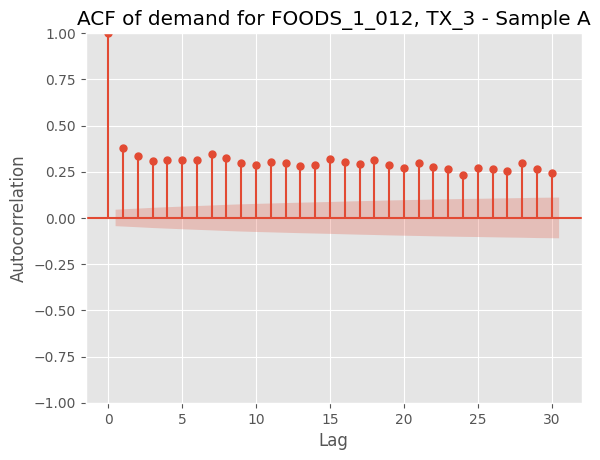

<Figure size 1200x500 with 0 Axes>

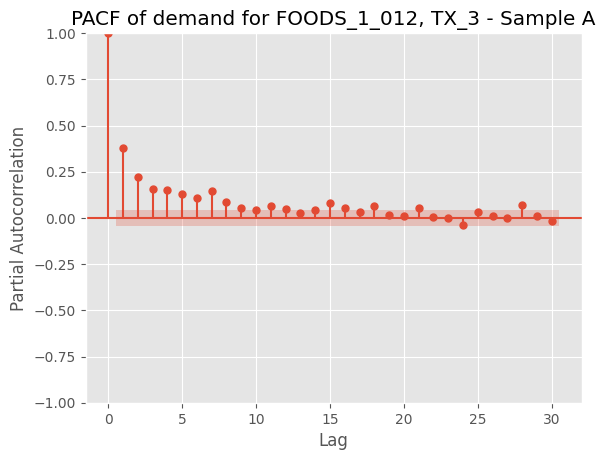

<Figure size 1200x500 with 0 Axes>

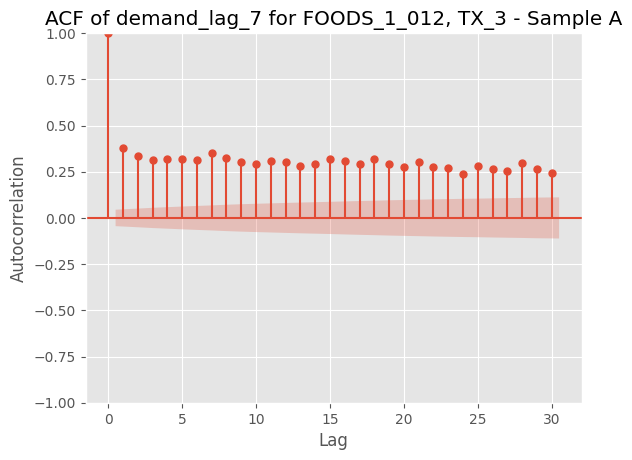

<Figure size 1200x500 with 0 Axes>

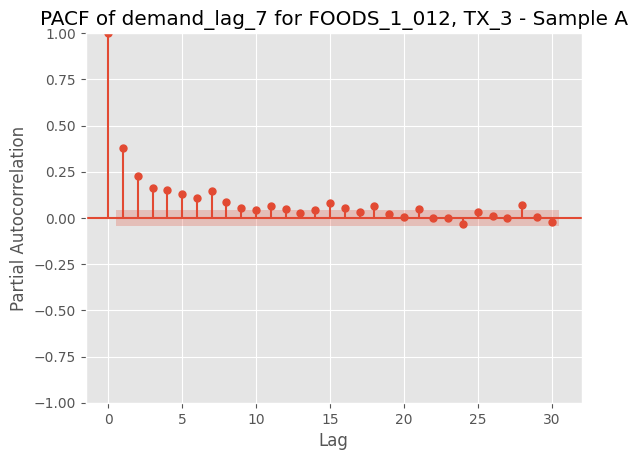

<Figure size 1200x500 with 0 Axes>

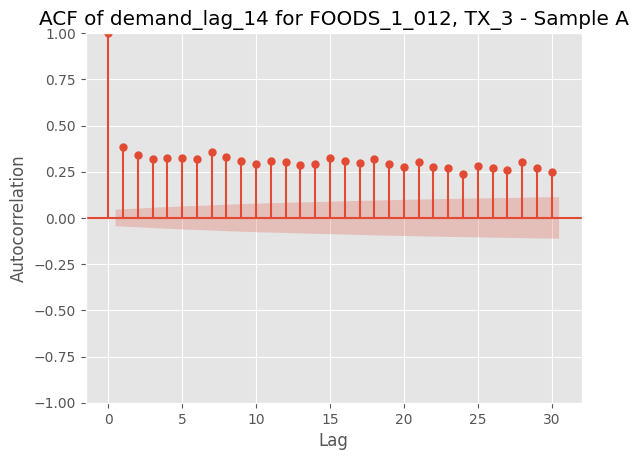

<Figure size 1200x500 with 0 Axes>

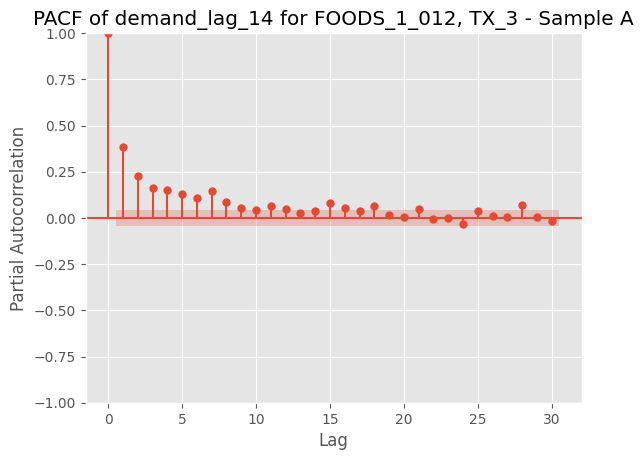

<Figure size 1200x500 with 0 Axes>

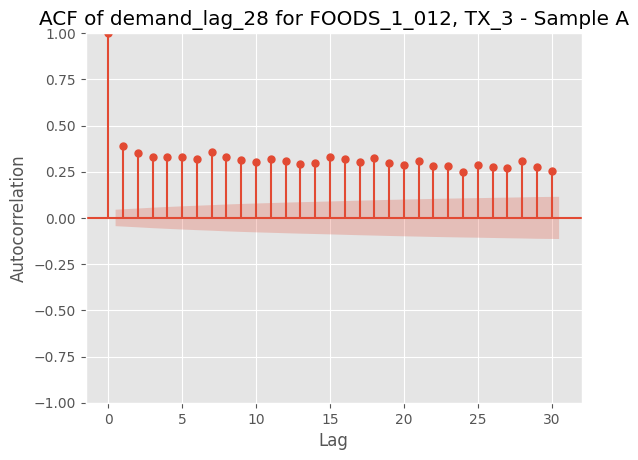

<Figure size 1200x500 with 0 Axes>

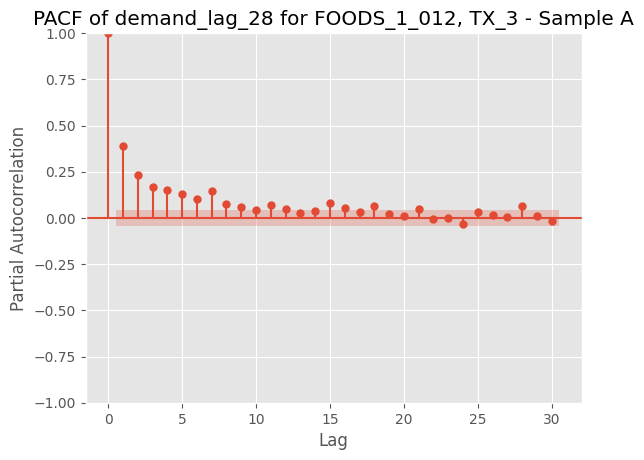

<Figure size 1200x500 with 0 Axes>

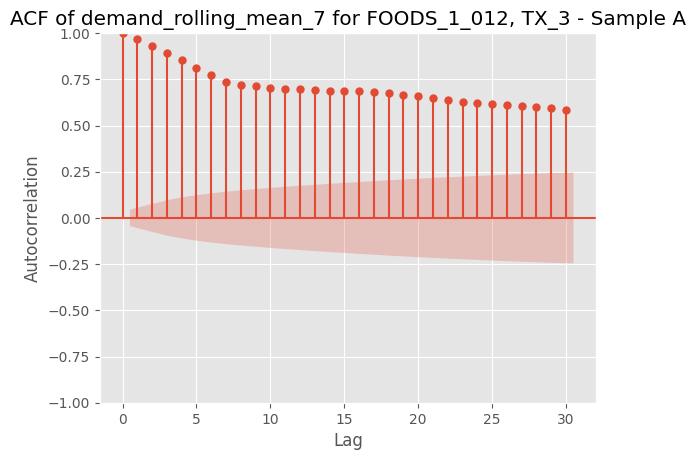

<Figure size 1200x500 with 0 Axes>

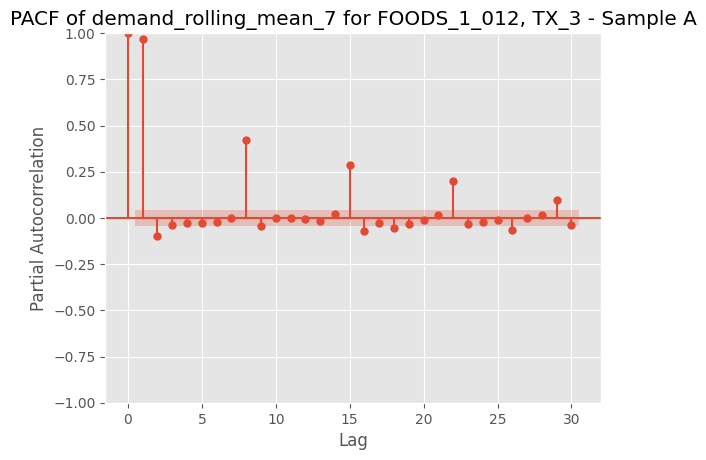

Displayed 5 feature plot sets. Increase max_plots_to_show to see more.
Displayed 5 feature plot sets. Increase max_plots_to_show to see more.

==================== ACF & PACF Plots: Sample B ====================
Total unique item-store-category-department combinations in Sample B: 380

--- Testing Item: FOODS_1_008, Store: TX_3, Category: FOODS, Department: FOODS_1 ---


<Figure size 1200x500 with 0 Axes>

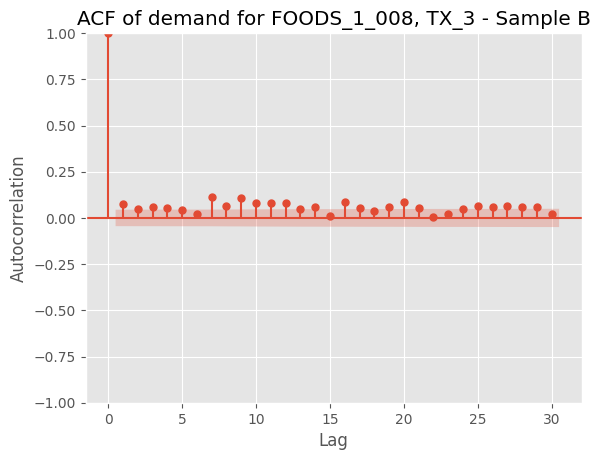

<Figure size 1200x500 with 0 Axes>

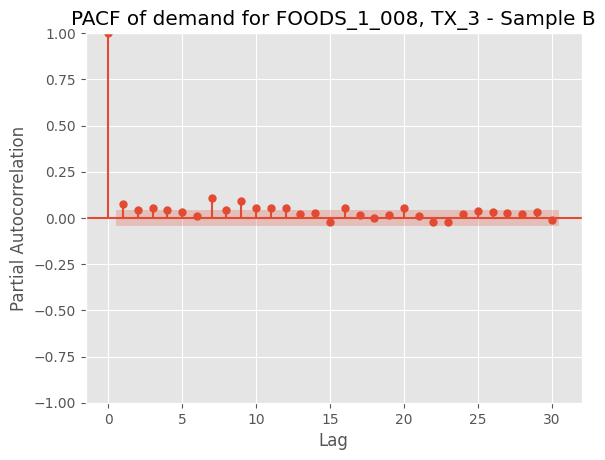

<Figure size 1200x500 with 0 Axes>

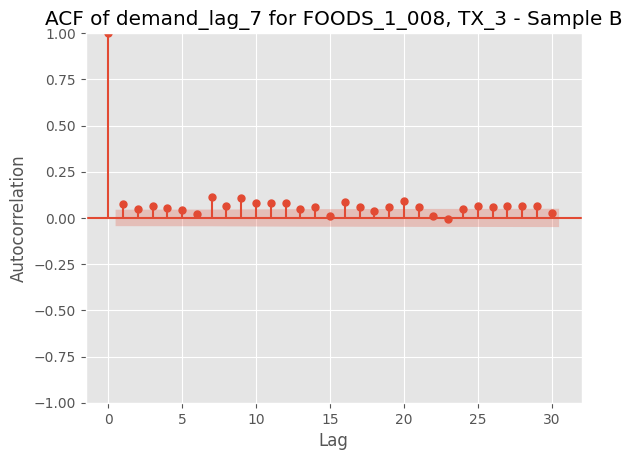

<Figure size 1200x500 with 0 Axes>

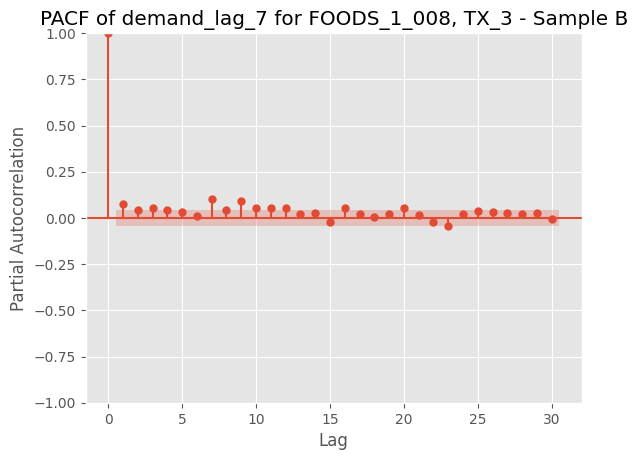

<Figure size 1200x500 with 0 Axes>

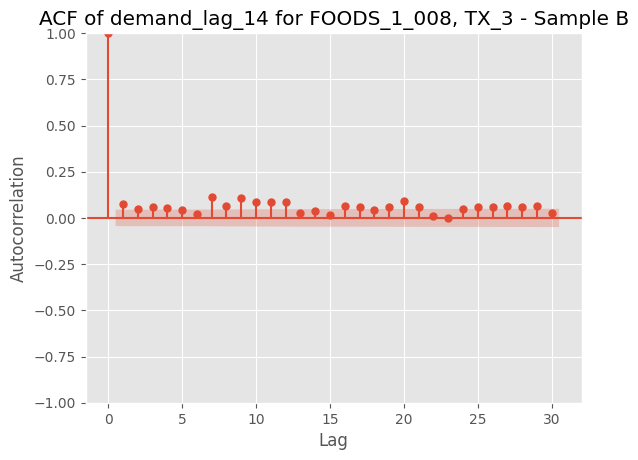

<Figure size 1200x500 with 0 Axes>

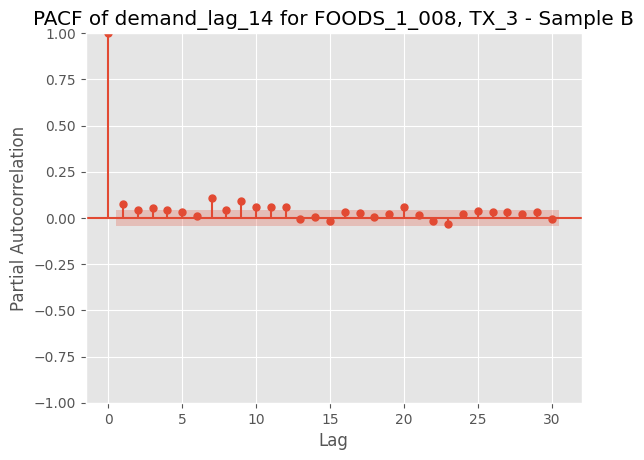

<Figure size 1200x500 with 0 Axes>

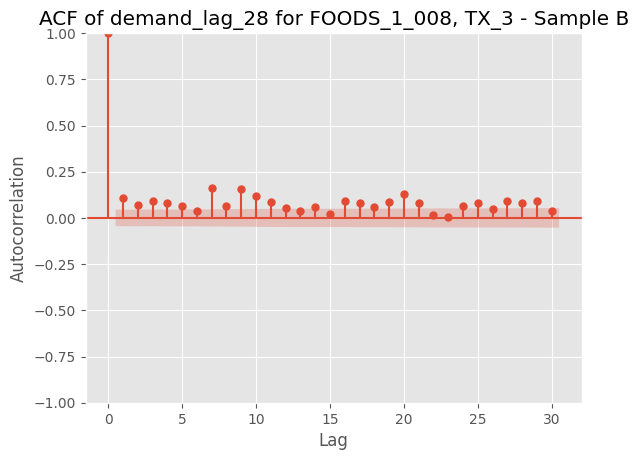

<Figure size 1200x500 with 0 Axes>

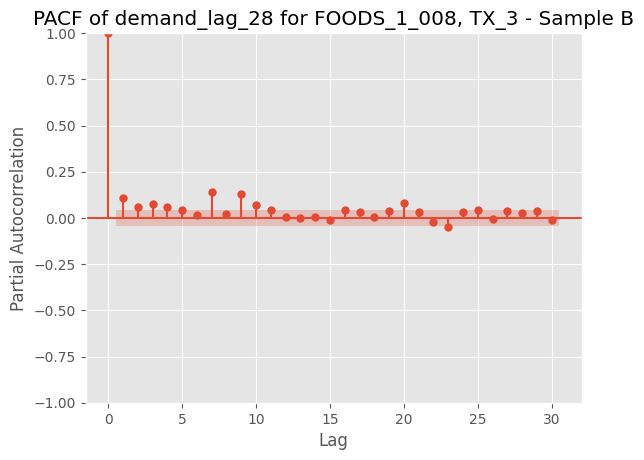

<Figure size 1200x500 with 0 Axes>

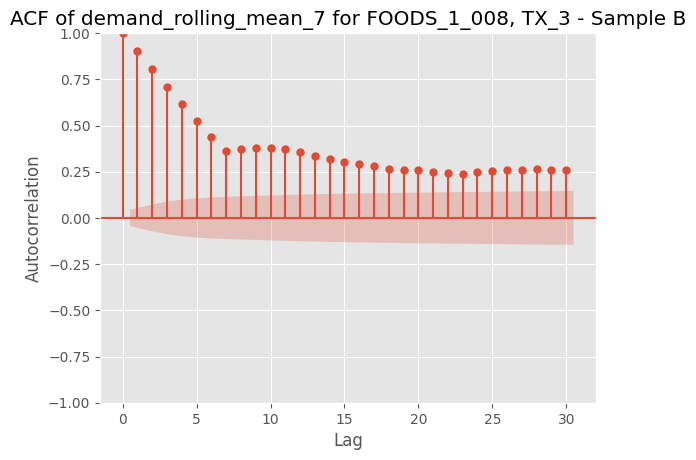

<Figure size 1200x500 with 0 Axes>

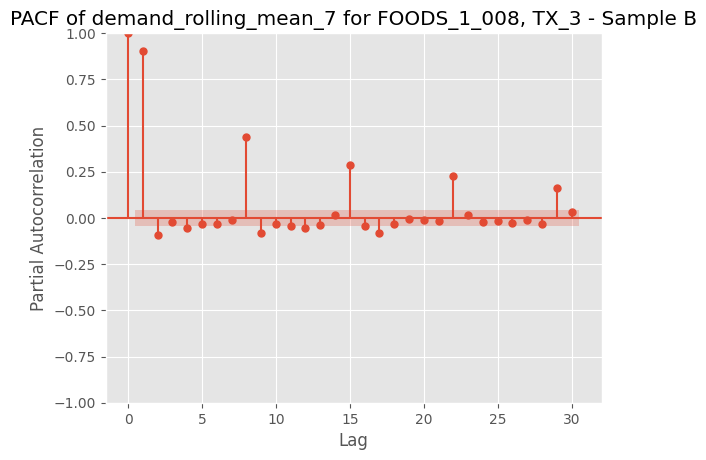

Displayed 5 feature plot sets. Increase max_plots_to_show to see more.
Displayed 5 feature plot sets. Increase max_plots_to_show to see more.

==================== ACF & PACF Plots: Sample C ====================
Total unique item-store-category-department combinations in Sample C: 380

--- Testing Item: FOODS_1_001, Store: WI_1, Category: FOODS, Department: FOODS_1 ---


<Figure size 1200x500 with 0 Axes>

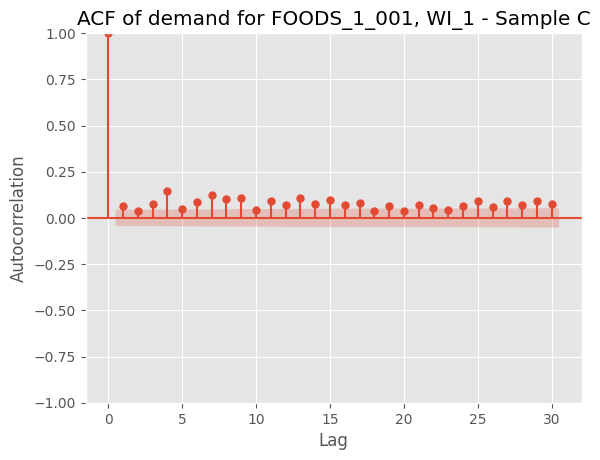

<Figure size 1200x500 with 0 Axes>

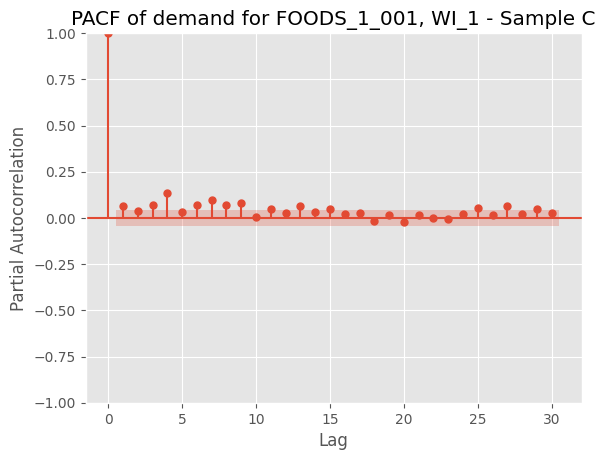

<Figure size 1200x500 with 0 Axes>

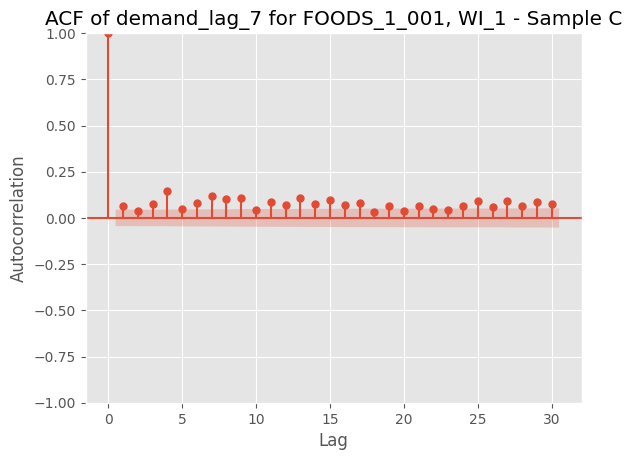

<Figure size 1200x500 with 0 Axes>

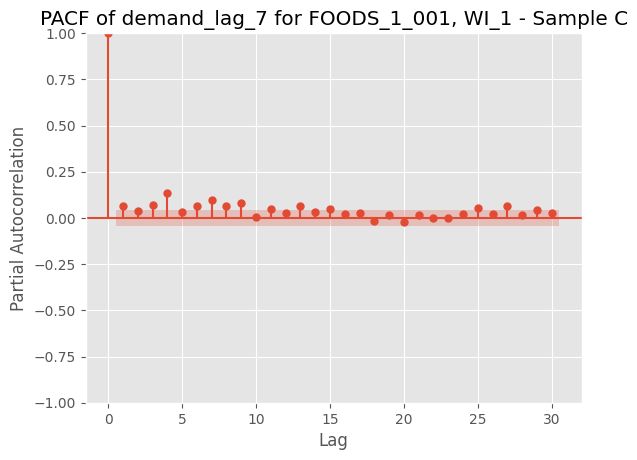

<Figure size 1200x500 with 0 Axes>

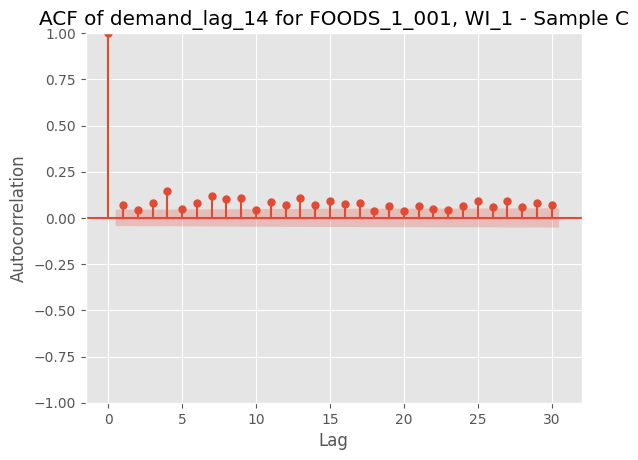

<Figure size 1200x500 with 0 Axes>

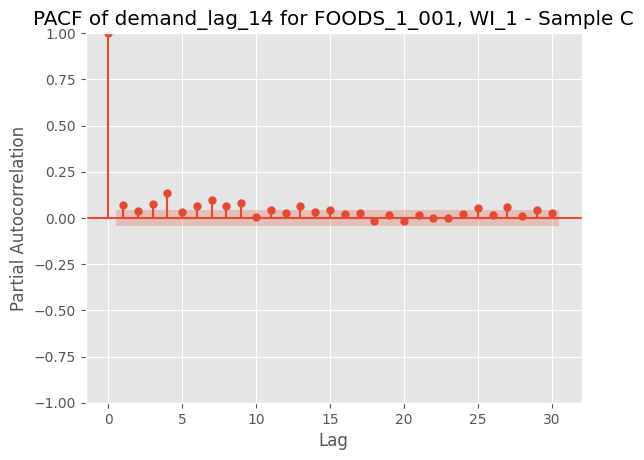

<Figure size 1200x500 with 0 Axes>

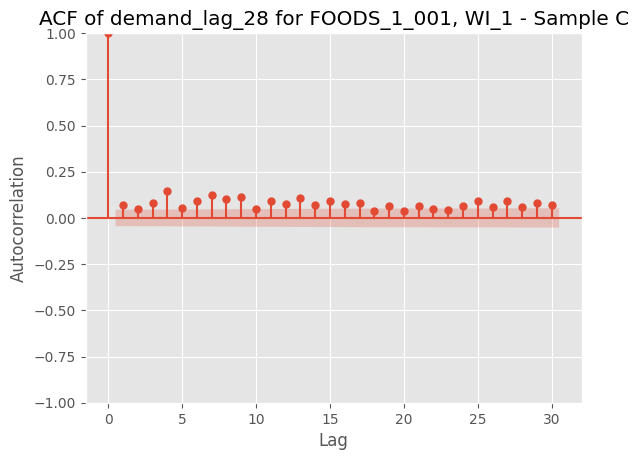

<Figure size 1200x500 with 0 Axes>

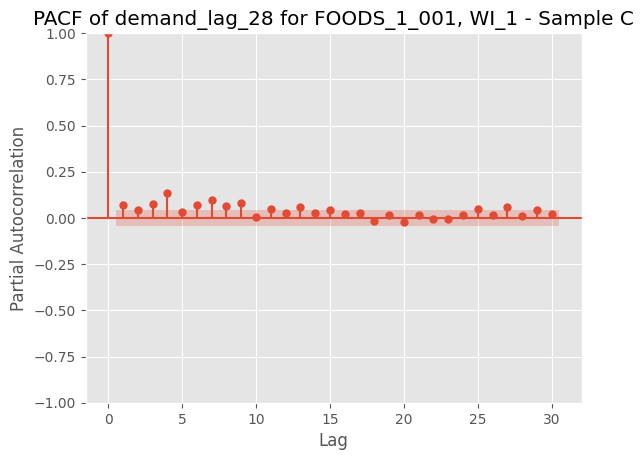

<Figure size 1200x500 with 0 Axes>

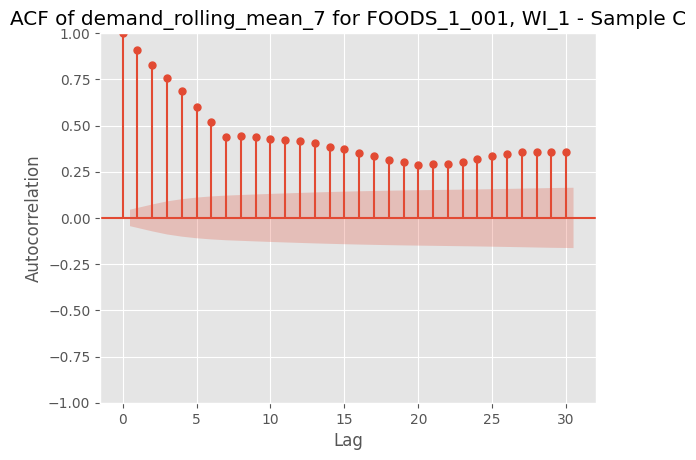

<Figure size 1200x500 with 0 Axes>

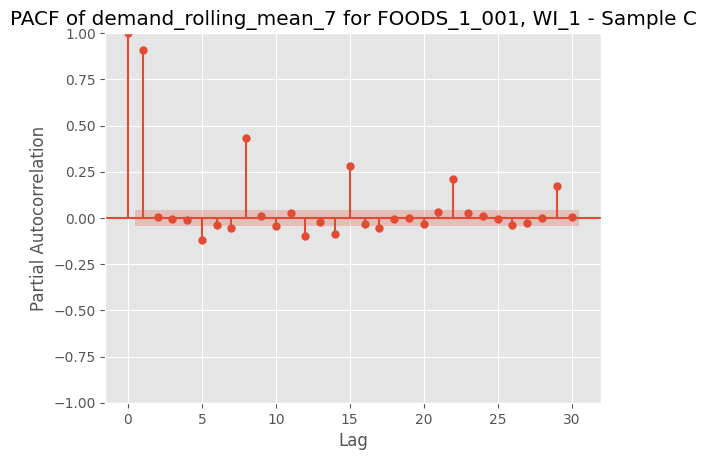

Displayed 5 feature plot sets. Increase max_plots_to_show to see more.
Displayed 5 feature plot sets. Increase max_plots_to_show to see more.


In [ ]:
plot_acf_pacf_for_sample(
    df_final_merged_A_fe,
    sample_name="Sample A",
    max_plots_to_show=5,
    min_data_points_for_test=30,
    max_lags=30
)

plot_acf_pacf_for_sample(
    df_final_merged_B_fe,
    sample_name="Sample B",
    max_plots_to_show=5,
    min_data_points_for_test=30,
    max_lags=30
)

plot_acf_pacf_for_sample(
    df_final_merged_C_fe,
    sample_name="Sample C",
    max_plots_to_show=5,
    min_data_points_for_test=30,
    max_lags=30
)

# **Price Fetures**

In [ ]:
# =========================================================
# Price feature engineering function
# =========================================================
def add_price_features(
    df,
    sample_name="Sample",
    save_path=None,
    show_plot=True
):
    """
    Add price-related features:
    1. Min-Max normalized sell_price
    2. price_change_flag
    3. price_change_direction
    """

    print(f"\n==================== Price Features: {sample_name} ====================")

    # Make copy to avoid modifying original dataframe directly
    df_price = df.copy()

    # Ensure correct ordering before diff()
    df_price['date'] = pd.to_datetime(df_price['date'])
    df_price = df_price.sort_values(
        by=['store_id', 'item_id', 'date']
    ).reset_index(drop=True)

    # -----------------------------------------------------
    # 1. Min-Max normalization for sell_price
    # -----------------------------------------------------
    scaler = MinMaxScaler()

    df_price['sell_price_normalized'] = scaler.fit_transform(
        df_price[['sell_price']]
    )

    print("\nHead of normalized price column:")
    display(df_price[['sell_price', 'sell_price_normalized']].head())

    if show_plot:
        plt.figure(figsize=(10, 6))
        sns.histplot(df_price['sell_price_normalized'], bins=50, kde=True)
        plt.title(f'Distribution of Min-Max Normalized Sell Prices - {sample_name}')
        plt.xlabel('Normalized Sell Price')
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.show()

    # -----------------------------------------------------
    # 2. Price change value
    # -----------------------------------------------------
    price_diff = df_price.groupby(['store_id', 'item_id'])['sell_price'].diff()

    # -----------------------------------------------------
    # 3. Price change flag
    # 1 = price changed, 0 = no change
    # First row per item-store becomes 0
    # -----------------------------------------------------
    df_price['price_change_flag'] = price_diff.ne(0).astype(int)

    # Fix first row of each item-store group
    first_rows = df_price.groupby(['store_id', 'item_id']).head(1).index
    df_price.loc[first_rows, 'price_change_flag'] = 0

    # -----------------------------------------------------
    # 4. Price change direction
    #  1 = price increased
    # -1 = price decreased
    #  0 = no change
    # -----------------------------------------------------
    df_price['price_change_direction'] = np.where(
        price_diff > 0, 1,
        np.where(price_diff < 0, -1, 0)
    )

    print("\nChecking null values in new price features:")
    display(df_price[
        ['sell_price_normalized', 'price_change_flag', 'price_change_direction']
    ].isnull().sum())

    print(f"\nInfo after adding price features for {sample_name}:")
    display(df_price.info())

    print(f"\nHead after price feature engineering for {sample_name}:")
    display(df_price.head())

    print(f"\nChecking total null values in {sample_name}:")
    display(df_price.isnull().sum())

    # -----------------------------------------------------
    # Save file if path provided
    # -----------------------------------------------------
    if save_path is not None:
        df_price.to_csv(save_path, index=False)
        print(f"{sample_name} saved successfully to: {save_path}")

    return df_price


==================== Price Features: Sample A ====================

Head of normalized price column:


,sell_price,sell_price_normalized
0,2.68,0.109904
1,2.68,0.109904
2,2.68,0.109904
3,2.68,0.109904
4,2.68,0.109904


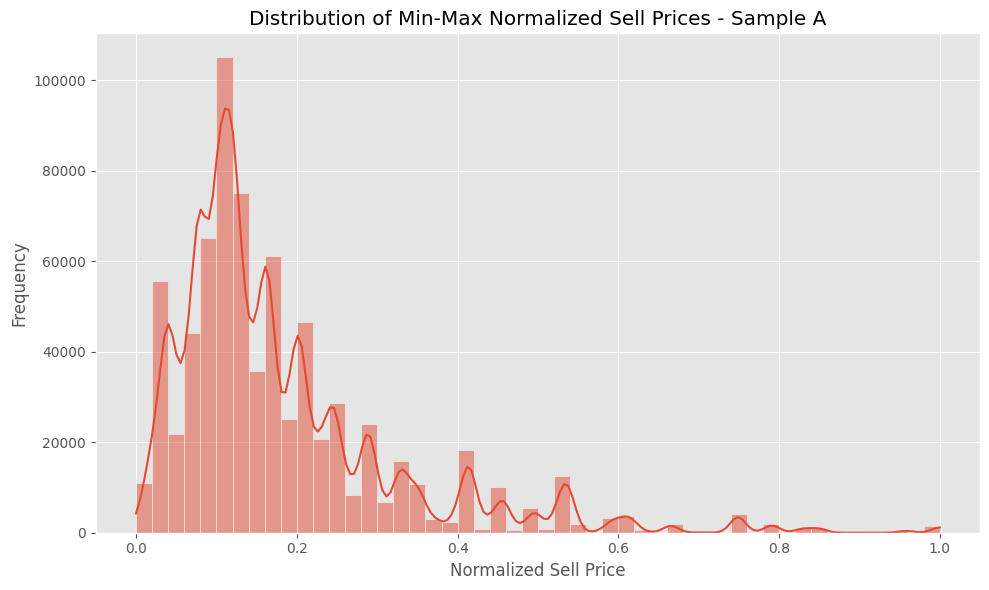


Checking null values in new price features:


,0
sell_price_normalized,0
price_change_flag,0
price_change_direction,0



Info after adding price features for Sample A:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      737580 non-null  object        
 1   item_id                 737580 non-null  object        
 2   dept_id                 737580 non-null  object        
 3   cat_id                  737580 non-null  object        
 4   store_id                737580 non-null  object        
 5   state_id                737580 non-null  object        
 6   d                       737580 non-null  object        
 7   demand                  737580 non-null  int64         
 8   date                    737580 non-null  datetime64[ns]
 9   wm_yr_wk                737580 non-null  int64         
 10  weekday                 737580 non-null  object        
 11  wday                    737580 non-null  in

None


Head after price feature engineering for Sample A:


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,demand_rolling_std_28,price_lag_1,price_lag_7,price_rolling_mean_7,price_rolling_std_7,price_rolling_mean_28,price_rolling_std_28,sell_price_normalized,price_change_flag,price_change_direction
0,FOODS_1_156_CA_1_evaluation,FOODS_1_156,FOODS_1,FOODS,CA_1,CA,d_1,0,2011-01-29,11101,...,0.0,2.68,2.68,2.68,0.0,2.68,0.0,0.109904,0,0
1,FOODS_1_156_CA_1_evaluation,FOODS_1_156,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,0.0,2.68,2.68,2.68,0.0,2.68,0.0,0.109904,0,0
2,FOODS_1_156_CA_1_evaluation,FOODS_1_156,FOODS_1,FOODS,CA_1,CA,d_3,0,2011-01-31,11101,...,0.0,2.68,2.68,2.68,0.0,2.68,0.0,0.109904,0,0
3,FOODS_1_156_CA_1_evaluation,FOODS_1_156,FOODS_1,FOODS,CA_1,CA,d_4,0,2011-02-01,11101,...,0.0,2.68,2.68,2.68,0.0,2.68,0.0,0.109904,0,0
4,FOODS_1_156_CA_1_evaluation,FOODS_1_156,FOODS_1,FOODS,CA_1,CA,d_5,0,2011-02-02,11101,...,0.0,2.68,2.68,2.68,0.0,2.68,0.0,0.109904,0,0



Checking total null values in Sample A:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


Sample A saved successfully to: /content/drive/MyDrive/Graduation Project Data/processed_data_A.csv


In [ ]:
Processed_Sample_A= add_price_features(
    df=df_final_merged_A_fe,
    sample_name="Sample A",
    save_path='/content/drive/MyDrive/Graduation Project Data/processed_data_A.csv',
    show_plot=True
)



==================== Price Features: Sample B ====================

Head of normalized price column:


,sell_price,sell_price_normalized
0,0.97,0.025016
1,0.97,0.025016
2,0.97,0.025016
3,0.97,0.025016
4,0.97,0.025016


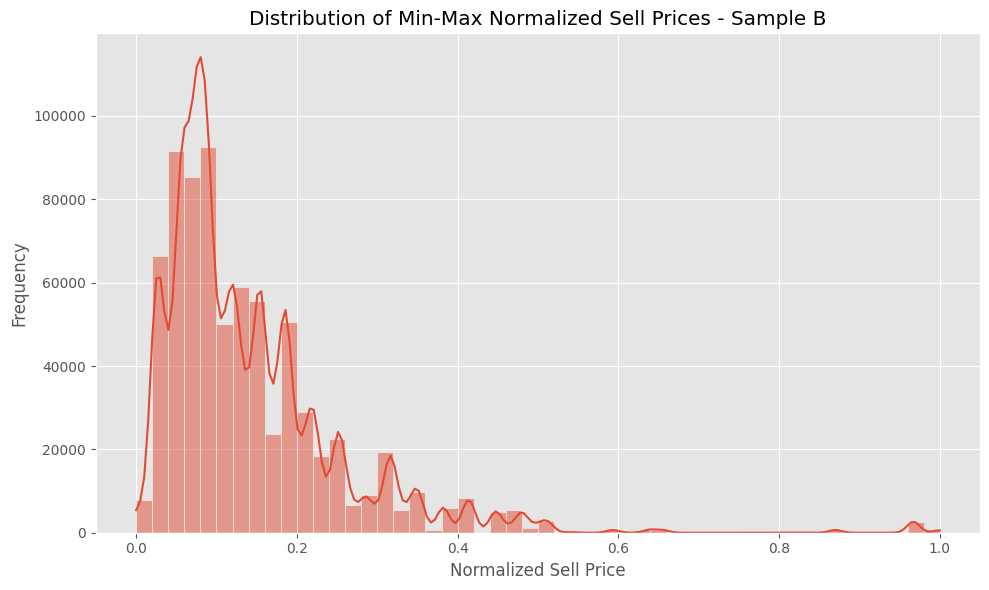


Checking null values in new price features:


,0
sell_price_normalized,0
price_change_flag,0
price_change_direction,0



Info after adding price features for Sample B:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      737580 non-null  object        
 1   item_id                 737580 non-null  object        
 2   dept_id                 737580 non-null  object        
 3   cat_id                  737580 non-null  object        
 4   store_id                737580 non-null  object        
 5   state_id                737580 non-null  object        
 6   d                       737580 non-null  object        
 7   demand                  737580 non-null  int64         
 8   date                    737580 non-null  datetime64[ns]
 9   wm_yr_wk                737580 non-null  int64         
 10  weekday                 737580 non-null  object        
 11  wday                    737580 non-null  in

None


Head after price feature engineering for Sample B:


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,demand_rolling_std_28,price_lag_1,price_lag_7,price_rolling_mean_7,price_rolling_std_7,price_rolling_mean_28,price_rolling_std_28,sell_price_normalized,price_change_flag,price_change_direction
0,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,d_1,15,2011-01-29,11101,...,4.242641,0.97,0.97,0.97,0.0,0.97,0.0,0.025016,0,0
1,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,d_2,9,2011-01-30,11101,...,4.242641,0.97,0.97,0.97,0.0,0.97,0.0,0.025016,0,0
2,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,d_3,6,2011-01-31,11101,...,4.582576,0.97,0.97,0.97,0.0,0.97,0.0,0.025016,0,0
3,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,d_4,0,2011-02-01,11101,...,6.244998,0.97,0.97,0.97,0.0,0.97,0.0,0.025016,0,0
4,FOODS_1_019_CA_1_evaluation,FOODS_1_019,FOODS_1,FOODS,CA_1,CA,d_5,3,2011-02-02,11101,...,5.770615,0.97,0.97,0.97,0.0,0.97,0.0,0.025016,0,0



Checking total null values in Sample B:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


Sample B saved successfully to: /content/drive/MyDrive/Graduation Project Data/processed_data_B.csv


In [ ]:
Processed_Sample_B= add_price_features(
    df=df_final_merged_B_fe,
    sample_name="Sample B",
    save_path='/content/drive/MyDrive/Graduation Project Data/processed_data_B.csv',
    show_plot=True
)



==================== Price Features: Sample C ====================

Head of normalized price column:


,sell_price,sell_price_normalized
0,3.18,0.048645
1,3.18,0.048645
2,3.18,0.048645
3,3.18,0.048645
4,3.18,0.048645


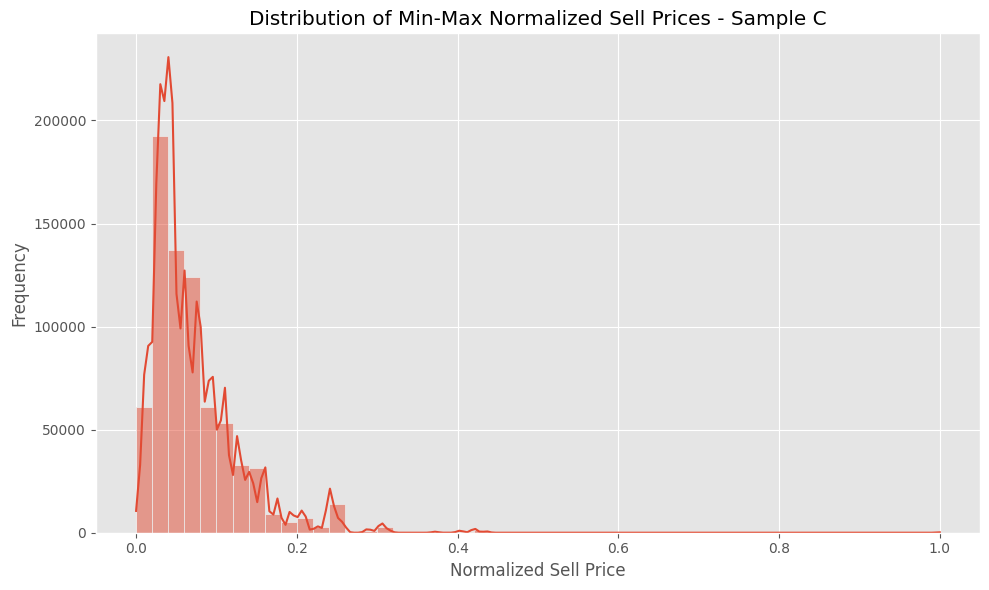


Checking null values in new price features:


,0
sell_price_normalized,0
price_change_flag,0
price_change_direction,0



Info after adding price features for Sample C:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 737580 entries, 0 to 737579
Data columns (total 49 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   id                      737580 non-null  object        
 1   item_id                 737580 non-null  object        
 2   dept_id                 737580 non-null  object        
 3   cat_id                  737580 non-null  object        
 4   store_id                737580 non-null  object        
 5   state_id                737580 non-null  object        
 6   d                       737580 non-null  object        
 7   demand                  737580 non-null  int64         
 8   date                    737580 non-null  datetime64[ns]
 9   wm_yr_wk                737580 non-null  int64         
 10  weekday                 737580 non-null  object        
 11  wday                    737580 non-null  in

None


Head after price feature engineering for Sample C:


,id,item_id,dept_id,cat_id,store_id,state_id,d,demand,date,wm_yr_wk,...,demand_rolling_std_28,price_lag_1,price_lag_7,price_rolling_mean_7,price_rolling_std_7,price_rolling_mean_28,price_rolling_std_28,sell_price_normalized,price_change_flag,price_change_direction
0,FOODS_1_062_CA_1_evaluation,FOODS_1_062,FOODS_1,FOODS,CA_1,CA,d_1,4,2011-01-29,11101,...,2.828427,3.18,3.18,3.18,0.0,3.18,0.0,0.048645,0,0
1,FOODS_1_062_CA_1_evaluation,FOODS_1_062,FOODS_1,FOODS,CA_1,CA,d_2,0,2011-01-30,11101,...,2.828427,3.18,3.18,3.18,0.0,3.18,0.0,0.048645,0,0
2,FOODS_1_062_CA_1_evaluation,FOODS_1_062,FOODS_1,FOODS,CA_1,CA,d_3,1,2011-01-31,11101,...,2.081666,3.18,3.18,3.18,0.0,3.18,0.0,0.048645,0,0
3,FOODS_1_062_CA_1_evaluation,FOODS_1_062,FOODS_1,FOODS,CA_1,CA,d_4,0,2011-02-01,11101,...,1.892969,3.18,3.18,3.18,0.0,3.18,0.0,0.048645,0,0
4,FOODS_1_062_CA_1_evaluation,FOODS_1_062,FOODS_1,FOODS,CA_1,CA,d_5,1,2011-02-02,11101,...,1.643168,3.18,3.18,3.18,0.0,3.18,0.0,0.048645,0,0



Checking total null values in Sample C:


,0
id,0
item_id,0
dept_id,0
cat_id,0
store_id,0
state_id,0
d,0
demand,0
date,0
wm_yr_wk,0


Sample C saved successfully to: /content/drive/MyDrive/Graduation Project Data/processed_data_C.csv


In [ ]:
Processed_Sample_C= add_price_features(
    df=df_final_merged_C_fe,
    sample_name="Sample C",
    save_path='/content/drive/MyDrive/Graduation Project Data/processed_data_C.csv',
    show_plot=True
)

# **Demand Modeling and XAI**

contains chosen models, building and preprocessing related to each model. The Follwing models will be implemented in seprated notebook:
- CatBOOST
- LSTM
- TCN

XAI methdologies Used are:
- SHAP
- PDP
- LIME

XAI Evaluation:
will be focused on  Genarlization, Fithfulness and Roubtness